In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys
import os
import glob
import pandas as pd
import astropy.units as u
from datetime import date
from random import choices, seed
from math import factorial, erf
from astroquery.simbad import Simbad
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm, uniform, truncnorm
from scipy.special import erfinv, comb
from scipy.special import comb
import h5py
from sklearn.neighbors import KernelDensity
from scipy import stats
from matplotlib.ticker import AutoMinorLocator
from astropy.io import ascii
from IPython.display import clear_output
import time
from scipy.signal import find_peaks
from scipy.special import comb
import arviz as az
import string
import matplotlib.patches as patches


In [2]:
def make_cmap(colors, position, bit=False):
    '''
    make_cmap takes a list of tuples which contain RGB values. The RGB
    values may either be in 8-bit [0 to 255] (in which bit must be set to
    True when called) or arithmetic [0 to 1] (default). make_cmap returns
    a cmap with equally spaced colors.
    Arrange your tuples so that the first color is the lowest value for the
    colorbar and the last is the highest.
    position contains values from 0 to 1 to dictate the location of each color.
    '''
    bit_rgb = np.linspace(0,1,256)
    # if position == None:
    #     position = np.linspace(0,1,len(colors))
    # else:
    if len(position) != len(colors):
        sys.exit("position length must be the same as colors")
    elif position[0] != 0 or position[-1] != 1:
        sys.exit("position must start with 0 and end with 1")
    if bit:
        for i in range(len(colors)):
            colors[i] = (bit_rgb[colors[i][0]],
                         bit_rgb[colors[i][1]],
                         bit_rgb[colors[i][2]])
    cdict = {'red':[], 'green':[], 'blue':[]}
    for pos, color in zip(position, colors):
        cdict['red'].append((pos, color[0], color[0]))
        cdict['green'].append((pos, color[1], color[1]))
        cdict['blue'].append((pos, color[2], color[2]))

    cmap = mpl.colors.LinearSegmentedColormap('my_colormap',cdict,256)
    return cmap
def choose_cmap(custom_cmap, reverse_cmap=False):

    custom_cmaps = {'my diverging red blue': [(204/255, 230/255, 255/255),
                                              (0/255, 102/255, 204/255),
                                              (51/255, 0/255, 102/255),
                                              (255/255, 0/255, 102/255),
                                              (255/255, 230/255, 243/255)],
                    'my blue yellow red': [(0 / 255, 74 / 255, 171 / 255),
                                        (255 / 255, 209 / 255, 26 / 255),
                                        (178 / 255, 0 / 255, 3 / 255)],
                    'McLaren 2022': [(0/255, 38/255, 77/255),
                                    (211/255, 0/255, 87/255),
                                    (255/255, 153/255, 0/255),
                                    (191/255, 217/255, 217/255)],
                    'vibrant candy': [(0/255, 26/255, 77/255),
                                    (204/255, 0/255, 102/255),
                                    (255/255, 204/255, 0/255),
                                    (153/255, 255/255, 153/255)],
                    'ice queen': [(37/255, 0/255, 51/255),
                                  (0/255, 155/255, 153/255),
                                  (214/255, 255/255, 214/255)],
                    'ice queen2': [(0/255, 0/255, 0/255),
                                   (0/255, 134/255, 179/255),
                                   (255/255, 255/255, 200/255)],
                    'amazon queen': [(0/255, 0/255, 0/255),
                                     (25/255, 103/255, 103/255),
                                     (119/255, 179/255, 105/255),
                                     (255/255, 234/255, 0/255),
                                     (255/255, 255/255, 255/255)],
                    'amazon queen2': [(0/255, 34/255, 51/255),
                                      (25/255, 103/255, 103/255),
                                    #   (119/255, 179/255, 105/255),
                                    #   (63/255, 211/255, 146/255),
                                      (255/255, 234/255, 0/255)],
                    'colorado sunrise': [(0/255, 17/255, 51/255),
                                         (234/255, 74/255, 104/255),
                                         (255/255, 224/255, 102/255)],
                    'muted rbg': [(102/255, 0/255, 51/255),
                                  (0/255, 85/255, 128/255),
                                  (140/255, 153/255, 0/255)],
                    'perceptual rbg': [(102/255, 0/255, 51/255),
                                       (60/255, 40/255, 90/255),
                                       (0/255, 102/255, 153/255),
                                       (134/255, 179/255, 0/255),
                                       (255/255, 200/255, 50/255),
                                       (255/255, 255/255, 160/255)],
                    'mclaren livery': [(0/255, 119/255, 179/255),
                                       (204/255, 0/255, 102/255),
                                    #    (255/255, 128/255, 0/255),
                                       (255/255, 153/255, 0/255),
                                       (207/255, 226/255, 226/255)],
                    'volcanic sunrise': [(0/255, 51/255, 77/255),
                                  (153/255, 0/255, 77/255),
                                  (255/255, 80/255, 80/255),
                                  (255/255, 255/255, 153/255)],
                    'cyber grape': [(51/255, 0/255, 51/255),
                                    (128/255, 0/255, 128/255),
                                    (153/255, 102/255, 255/255),
                                    (204/255, 255/255, 255/255)],
                    'cyber grape2': [(51/255, 0/255, 51/255),
                                     (128/255, 0/255, 128/255),
                                     (255/255, 153/255, 204/255),
                                     (204/255, 255/255, 255/255)],
                    'black limeaid': [(0/255, 0/255, 77/255),
                                      (102/255, 153/255, 153/255),
                                      (204/255, 255/255, 51/255)],
                    'raspberry punch1': [(51/255, 0/255, 102/255),
                                        (51/255, 204/255, 224/255),
                                        (248/255, 255/255, 230/255)],
                    'raspberry punch2': [(70/255, 0/255, 0/255),
                                        (89/255, 0/255, 179/255),
                                        (51/255, 204/255, 224/255),
                                        (255/255, 255/255, 200/255)],
                    'raspberry punch': [(51/255, 0/255, 102/255),
                                        # (89/255, 0/255, 179/255),
                                        (51/255, 204/255, 224/255),
                                        (255/255, 255/255, 200/255)],
                    }

    chosen_cmap = custom_cmaps[custom_cmap]
    pos_diff = 1./(len(chosen_cmap)-1)
    positions = np.arange(0, 1+pos_diff, pos_diff)
    if reverse_cmap == True:
        chosen_cmap = chosen_cmap[::-1]
    mycolormap = make_cmap(chosen_cmap, position=positions)

    return mycolormap
def combine_hex_values(hex_dict):
    d_items = sorted(hex_dict.items())
    tot_weight = sum(hex_dict.values())
    red = int(sum([int(w[:2], 16)*v for w, v in d_items])/tot_weight)
    green = int(sum([int(w[2:4], 16)*v for w, v in d_items])/tot_weight)
    blue = int(sum([int(w[4:6], 16)*v for w, v in d_items])/tot_weight)
    zpad = lambda u: u if len(u)==2 else '0' + u
    return '#' + zpad(hex(red)[2:]) + zpad(hex(green)[2:]) + zpad(hex(blue)[2:])


plt.style.use('/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle')
# plt.rcParams.keys()

Duplicate key in file '/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle', line 40 ('figure.dpi: 150')
Bad value in file '/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle', line 19 ('mathtext.fallback: dejavusans'): Key mathtext.fallback: dejavusans is not a valid fallback font name. Valid fallback font names are cm,stix,stixsans. Passing 'None' will turn fallback off.


In [3]:
def unique(list_of_values):
    unique_values = []
    for _, value in enumerate(list_of_values):
        if value in unique_values:
            pass
        else:
            unique_values.append(value)
    return unique_values

def savitzky_golay(y, window_size, order, deriv=0, rate=1):
    r"""Smooth (and optionally differentiate) data with a Savitzky-Golay filter.
    The Savitzky-Golay filter removes high frequency noise from data.
    It has the advantage of preserving the original shape and
    features of the signal better than other types of filtering
    approaches, such as moving averages techniques.
    Parameters
    ----------
    y : array_like, shape (N,)
        the values of the time history of the signal.
    window_size : int
        the length of the window. Must be an odd integer number.
    order : int
        the order of the polynomial used in the filtering.
        Must be less then `window_size` - 1.
    deriv: int
        the order of the derivative to compute (default = 0 means only smoothing)
    Returns
    -------
    ys : ndarray, shape (N)
        the smoothed signal (or it's n-th derivative).
    Notes
    -----
    The Savitzky-Golay is a type of low-pass filter, particularly
    suited for smoothing noisy data. The main idea behind this
    approach is to make for each point a least-square fit with a
    polynomial of high order over a odd-sized window centered at
    the point.
    Examples
    --------
    t = np.linspace(-4, 4, 500)
    y = np.exp( -t**2 ) + np.random.normal(0, 0.05, t.shape)
    ysg = savitzky_golay(y, window_size=31, order=4)
    import matplotlib.pyplot as plt
    plt.plot(t, y, label='Noisy signal')
    plt.plot(t, np.exp(-t**2), 'k', lw=1.5, label='Original signal')
    plt.plot(t, ysg, 'r', label='Filtered signal')
    plt.legend()
    plt.show()
    References
    ----------
    .. [1] A. Savitzky, M. J. E. Golay, Smoothing and Differentiation of
       Data by Simplified Least Squares Procedures. Analytical
       Chemistry, 1964, 36 (8), pp 1627-1639.
    .. [2] Numerical Recipes 3rd Edition: The Art of Scientific Computing
       W.H. Press, S.A. Teukolsky, W.T. Vetterling, B.P. Flannery
       Cambridge University Press ISBN-13: 9780521880688
    """
    
    try:
        window_size = np.abs(int(window_size))
        order = np.abs(int(order))
    except:
        raise ValueError("window_size and order have to be of type int")
    if window_size % 2 != 1 or window_size < 1:
        raise TypeError("window_size size must be a positive odd number")
    if window_size < order + 2:
        raise TypeError("window_size is too small for the polynomials order")
    order_range = range(order+1)
    half_window = (window_size -1) // 2
    # precompute coefficients
    b = np.mat([[k**i for i in order_range] for k in range(-half_window, half_window+1)])
    m = np.linalg.pinv(b).A[deriv] * rate**deriv * factorial(deriv)
    # pad the signal at the extremes with
    # values taken from the signal itself
    firstvals = y[0] - np.abs( y[1:half_window+1][::-1] - y[0] )
    lastvals = y[-1] + np.abs(y[-half_window-1:-1][::-1] - y[-1])
    y = np.concatenate((firstvals, y, lastvals))
    return np.convolve( m[::-1], y, mode='valid')

def factorial(number):
    fact = 1
    for i in range(1, number+1):
        fact = fact * i
    return fact

def weighted_mean(meas, meas_err):
    try:
        weight = 1./(np.array(meas_err)**2)
    except:
        print('Error calculating weighted mean!')
        print(meas, ',', meas_err)
    else:
        w_mean = sum(weight * np.array(meas)) / sum(weight)
        w_mean_err = 1./np.sqrt(sum(weight))

    return w_mean, w_mean_err

def i_unc(x, PDF):
    CDF = []
    for x_i in range(len(x)):
        CDF.append(np.trapz(PDF[0:x_i], x[0:x_i]))

    # plt.plot(x, CDF)

    where_peak = np.where(PDF == max(PDF))[0][0]
    sig1_perc = 1 - 0.6826
    sig2_perc = 1 - 0.9544
    sig1_sub = abs(np.array(CDF) - sig1_perc)
    sig2_sub = abs(np.array(CDF) - sig2_perc)

    where_sig1 = np.where(sig1_sub == min(sig1_sub))[0]
    where_sig2 = np.where(sig2_sub == min(sig2_sub))[0]
    sig1 = x[where_peak] - x[where_sig1]
    sig2 = x[where_peak] - x[where_sig2]

    if len(sig1) > 1:
        sig1 = float('nan')
        sig2 = float('nan')
    else:
        sig1 = sig1[0]
        sig2 = sig2[0]

    return sig1, sig2

def highest_density_interval(x, pdf_y, sigma, type='mode'):
    # 1sigma makes sigma = 0.6826

    # x_interp = np.arange(0, 90+0.01, 0.001)
    x_interp = np.linspace(0, 90.0, 10000)
    pdf_y = np.interp(x=x_interp, xp=x, fp=pdf_y)
    x = x_interp

    cdf_y = np.cumsum(pdf_y)
    cdf_y = cdf_y / cdf_y[-1]  # Normalize the cdf so that it sums to 1.

    # sub_cdf = abs(cdf_y - 0.5)
    # where_med = np.where(sub_cdf == min(sub_cdf))[0]
    # median = np.mean(x[where_med])

    dx = np.mean(np.diff(x))              # approximate bin width
    mean = np.sum(x * pdf_y * dx)         # numerical mean
    median = np.interp(0.5, cdf_y, x)     # median via CDF interpolation

    delta_xlist = []
    xlower = []
    xupper = []

    sigma_lower = 0
    delta = 1e-6

    for _ in range(0,round((1 - sigma)/delta)):
        x1 = np.interp(sigma_lower,cdf_y,x)
        xu = np.interp(sigma,cdf_y,x)
        delta_xlist.append(xu-x1)
        xlower.append(x1)
        xupper.append(xu)
        sigma += delta
        sigma_lower += delta

    index = delta_xlist.index(min(delta_xlist))
    mode = np.mean(x[pdf_y == max(pdf_y)]).round(1)
    mode = x[pdf_y == max(pdf_y)]
    if len(mode) > 1:
        mode = np.mean(mode)
    else:
        mode = mode[0]
    # print('The lower x value (for minimum credible interval) is ', xlower[index])
    # print('The upper x value (for minimum credible interval) is ', xupper[index])

    if type == 'mean':
        report_val = median
    if type == 'median':
        report_val = median
    if type == 'mode':
        report_val = mode

    lower = report_val - xlower[index]
    upper = xupper[index] - report_val

    return_allstats = [mean, median, mode]

    return report_val, lower, upper, x, pdf_y, return_allstats

def SpType_num_to_str(sptype_num, sptype_num_err):

    sptype_base_num = int(np.floor(sptype_num))

    if sptype_base_num == 3:
        sptype_str_letter = 'G'
    if sptype_base_num == 4:
        sptype_str_letter = 'K'
    if sptype_base_num == 5:
        sptype_str_letter = 'M'

    sptype_cat_num = np.round((sptype_num - sptype_base_num) * 10, 1)
    sptype_cat_str = str(sptype_cat_num)

    sptype_str = sptype_str_letter + sptype_cat_str

    sptype_num_err = np.round(sptype_num_err * 10, 1)
    if sptype_num_err == 0.0:
        sptype_num_err = 0.01
    sptype_str_err = str(sptype_num_err)

    return sptype_str, sptype_str_err

def determine_sptype(let_val, num_val):

    possible_letters = {'B': 0,
                        'A': 1,
                        'F': 2,
                        'G': 3,
                        'K': 4,
                        'M':5,
                        }

    temp_val = []
    if '-' in let_val:
        let_val_split = str(let_val).replace(' ', '').split('-')
        num_val_split = str(num_val).replace(' ', '').split('-')
        val1 = possible_letters[let_val_split[0]] + 0.1*float(num_val_split[0])
        val2 = possible_letters[let_val_split[1]] + 0.1*float(num_val_split[1])
        temp_val = [val1, val2]
    else:
        temp_val.append(possible_letters[let_val] + 0.1*float(num_val))
    
    if len(temp_val) > 1:
        adopted_val = np.mean(temp_val)
        adopted_val_err = np.std(temp_val, ddof=1)
    if len(temp_val) == 1:
        adopted_val = temp_val[0]
        adopted_val_err = 0.1

    
    return adopted_val, adopted_val_err

def clean_dataframe(df, dataset):
    keep_columns = ['Target', 'RA', 'DEC',
                    'SpType', 'SpType Letter', 'SpType Number', 'SpType Decimal', 'SpType Decimal Unc',
                    'Teff (K)', 'Teff Unc',
                    'Mstar (Msun)', 'Mstar Unc',
                    'Rstar (Rsun)', 'Rstar Unc',
                    'Prot (d)', 'Prot Unc',
                    'vsini (km/s)', 'vsini Unc',
                    'i disk (deg)', 'i disk Unc',
                    ]
    dict_clean = {}
    for _, key in enumerate(keep_columns):
        dict_clean[key] = []
    for _, col in enumerate(df.columns):
        if col == 'Target':
            targets = df['Target'].values
            for _, targ in enumerate(targets):
                dict_clean['Target'].append(targ)
        elif col == 'RA':
            RAs = df['RA'].values
            for _, RA in enumerate(RAs):
                dict_clean['RA'].append(RA)
        elif col == 'DEC':
            Decs = df['DEC'].values
            for _, Dec in enumerate(Decs):
                if Dec[0] == '-':
                    Dec = Dec.replace('-', '$-$')
                elif Dec[0] != '-':
                    Dec = '+' + Dec
                dict_clean['DEC'].append(Dec)
        elif col in ['i disk Unc', 'SpType Letter', 'SpType Number', 'SpType Decimal', 'SpType Decimal Unc', 'vsini Unc']:
            if dataset != 'PD':
                continue
            else:
                if col == 'i disk Unc' or col == 'vsini Unc':
                    continue
        elif col == 'SpType':
            dict_clean['SpType'] = df['SpType'].values
            dict_clean['SpType Letter'] = df['SpType Letter'].values
            for indx in range(len(df['SpType Letter'].values)):
                dict_clean['SpType Number'].append(df['SpType Number'].values[indx])
                updated_val, _ = determine_sptype(df['SpType Letter'].values[indx], df['SpType Number'].values[indx])
                dict_clean['SpType Decimal'].append(updated_val)
                dict_clean['SpType Decimal Unc'].append(0.001)
        elif col == 'i disk (deg)':
            idisk_strings = df['i disk (deg)'].values
            idisk_err_strings = df['i disk Unc'].values
            for indx2 in range(len(idisk_strings)):
                idisk_str = idisk_strings[indx2]
                idisk_err_str = idisk_err_strings[indx2]
                if type(idisk_str) == str:
                    if '[' in idisk_str:
                        val1 = float(idisk_str.replace('[', '').replace(']', '').split(',')[0])
                        val2 = float(idisk_str.replace('[', '').replace(']', '').split(',')[1])
                        val = np.mean([val1, val2])
                        val_err = abs(val - val1)
                        val = idisk_str
                        val_err = 0
                    else:
                        val = float(idisk_str)
                        val_err = float(idisk_err_str)
                else:
                    val = idisk_str
                    val_err = idisk_err_str
                dict_clean['i disk (deg)'].append(val)
                dict_clean['i disk Unc'].append(val_err)
        elif col == 'vsini (km/s)':
            vsini_strings = df['vsini (km/s)'].values
            vsini_err_strings = df['vsini Unc'].values
            for indx3 in range(len(vsini_strings)):
                vsini_str = vsini_strings[indx3]
                vsini_err_str = vsini_err_strings[indx3]
                if type(vsini_str) == str:
                    if '<' in vsini_str:
                        val = float(vsini_str.replace('<', ''))
                        val_err = 'ulimit'
                    else:
                        val = float(vsini_str)
                        val_err = float(vsini_err_str)
                else:
                    val = float(vsini_str)
                    val_err = float(vsini_err_str)
                dict_clean['vsini (km/s)'].append(val)
                dict_clean['vsini Unc'].append(val_err)
        elif col == 'Prot Unc':
            absolute_shear = 0.07  # rad / day
            err_tracker = []
            for indx in range(len(df['Prot Unc'].values)):
                err_val = df['Prot Unc'].values[indx]
                if dataset == 'DD':
                    mean_val = df['Prot (d)'].values[indx]
                    err_shear = 0.5*(mean_val - ((absolute_shear/(2*np.pi)) + (1./mean_val))**-1)
                    Prot_err = np.sqrt(err_val**2 + err_shear**2)
                    dict_clean['Prot Unc'].append(Prot_err)
                    # print(err_val, Prot_err)
                    err_tracker.append(Prot_err/err_val)
                    if indx == len(df['Prot Unc'].values)-1:
                        print(err_tracker)
                        print(np.mean(err_tracker))
                else:
                    dict_clean['Prot Unc'].append(err_val)
        elif col in keep_columns:
            vals = df[col].values
            for _, val_str in enumerate(vals):
                val = float(val_str)
                dict_clean[col].append(val)
        else:
            continue

    # if dataset == 'DD':
    #     for _, key in enumerate(dict_clean.keys()):
    #         print(key, len(dict_clean[key]))
    
    df_clean = pd.DataFrame(dict_clean)
    
    return df_clean

def bb_binomial_ppd(x, k, n, normapprox=False):
    # Convert inputs to float for consistency
    n = float(n)
    k = float(k)
    
    if not normapprox:
        # Exact binomial computation using comb from scipy.special
        nchoosek = comb(int(n), int(k), exact=True)
        ppd = nchoosek * (x**k) * ((1.0 - x)**(n - k)) * (n + 1.0)
    else:
        # Normal approximation
        # mean = n*x, variance = n*x*(1-x), std = sqrt(variance)
        mean = n * x
        var = n * x * (1.0 - x)
        sd = np.sqrt(var)
        
        # Normal PDF at k with mean and std
        ppd = (1.0 / (sd * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((k - mean)**2 / var))
    
    return ppd




In [4]:
def highest_density_interval(x, pdf_y, sigma, type='mode'):
    # 1sigma makes sigma = 0.6826

    # x_interp = np.arange(0, 90+0.01, 0.001)
    x_interp = np.linspace(0, 90.0, 10000)
    pdf_y = np.interp(x=x_interp, xp=x, fp=pdf_y)
    x = x_interp

    cdf_y = np.cumsum(pdf_y)
    cdf_y = cdf_y / cdf_y[-1]  # Normalize the cdf so that it sums to 1.

    # sub_cdf = abs(cdf_y - 0.5)
    # where_med = np.where(sub_cdf == min(sub_cdf))[0]
    # median = np.mean(x[where_med])

    dx = np.mean(np.diff(x))              # approximate bin width
    mean = np.sum(x * pdf_y * dx)         # numerical mean
    median = np.interp(0.5, cdf_y, x)     # median via CDF interpolation

    delta_xlist = []
    xlower = []
    xupper = []

    sigma_lower = 0
    delta = 1e-6

    for _ in range(0,round((1 - sigma)/delta)):
        x1 = np.interp(sigma_lower,cdf_y,x)
        xu = np.interp(sigma,cdf_y,x)
        delta_xlist.append(xu-x1)
        xlower.append(x1)
        xupper.append(xu)
        sigma += delta
        sigma_lower += delta

    index = delta_xlist.index(min(delta_xlist))
    mode = np.mean(x[pdf_y == max(pdf_y)]).round(1)
    mode = x[pdf_y == max(pdf_y)]
    if len(mode) > 1:
        mode = np.mean(mode)
    else:
        mode = mode[0]
    # print('The lower x value (for minimum credible interval) is ', xlower[index])
    # print('The upper x value (for minimum credible interval) is ', xupper[index])

    if type == 'mean':
        report_val = median
    if type == 'median':
        report_val = median
    if type == 'mode':
        report_val = mode

    lower = report_val - xlower[index]
    upper = xupper[index] - report_val

    return_allstats = [mean, median, mode]

    return report_val, lower, upper, x, pdf_y, return_allstats


In [5]:
main_directory = '/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/'
data_directory = main_directory+'Tables/Sample_Weighted_Mean/'
tables_directory = main_directory+'Tables/'
test_figures_directory = main_directory + 'Test_Figures/'
probability_distributions_dir = main_directory + 'Tables/Probability_Distributions/'



In [86]:
read_local = False

if read_local != True:
    today = date.today()
    date_str = today.strftime("%Y-%b-%d")

    PD_properties_sheet_url = "https://docs.google.com/spreadsheets/d/1Xjpm2m3hxQACorlvKcwqjBnBKssgK8MCFyijPfVseFg/edit#gid=0"
    DD_properties_sheet_url = "https://docs.google.com/spreadsheets/d/1Lz2p6EdhytAR2_HvcPY543MrRbRoB7d7Hj5yp1E8XsM/edit#gid=0"
    WJ_properties_sheet_url = "https://docs.google.com/spreadsheets/d/1B8ep95z7EaXZ6x-fRjntDTN3i8LQUmNRGMBrc5G6bV4/edit#gid=0"
    HJ_properties_sheet_url = "https://docs.google.com/spreadsheets/d/1k5oKAUum9d-s5JaD3HDRDlMZqn_pPGvRyFvB4kw8WE0/edit#gid=0"

    DD_NEA_sheet_url = "https://docs.google.com/spreadsheets/d/1udcwcYq_V1K8klSsJhh5LU7DcI-HKDcx1XvD9GM1sCQ/edit#gid=1605229114&fvid=90870798"
    WJ_NEA_sheet_url = "https://docs.google.com/spreadsheets/d/1udcwcYq_V1K8klSsJhh5LU7DcI-HKDcx1XvD9GM1sCQ/edit#gid=208039490&fvid=453681374"
    HJ_NEA_sheet_url = "https://docs.google.com/spreadsheets/d/1udcwcYq_V1K8klSsJhh5LU7DcI-HKDcx1XvD9GM1sCQ/edit#gid=169409426"


    url_PD_properties = PD_properties_sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')
    url_DD_properties = DD_properties_sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')
    url_WJ_properties = WJ_properties_sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')
    url_HJ_properties = HJ_properties_sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')

    url_DD_NEA = DD_NEA_sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')
    url_WJ_NEA = WJ_NEA_sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')
    url_HJ_NEA = HJ_NEA_sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')

    df_PD_goog = pd.read_csv(url_PD_properties)
    df_DD_goog = pd.read_csv(url_DD_properties)
    df_HJ_goog = pd.read_csv(url_HJ_properties)
    df_WJ_goog = pd.read_csv(url_WJ_properties)

    df_DD_NEA = pd.read_csv(url_DD_NEA)
    df_HJ_NEA = pd.read_csv(url_HJ_NEA)
    df_WJ_NEA = pd.read_csv(url_WJ_NEA)

else:
    date_str = '2023-Dec-9'
    raw_df = pd.read_excel(main_directory + 'Primordial_Disks_9-Dec-2023.xlsx')

In [87]:
# Set main variables

compute_new_posteriors = False

if compute_new_posteriors == False:
    # date_str = '2024-Dec-04'
    date_str = '2025-Oct-24'

skip_PD = False
skip_DD = False
skip_WJ = False
skip_HJ = False

sampling_resolution = 'high'
# resolution_text = sampling_resolution + 'Res'

report_stat = 'mode'

do_save_probability_distributions = True
do_save_plots = True

plot_lightfigure = False
plot_transparent = False


hist_linecolor = '#2f0431'  # Histogram
zeroline_color = '#404040'  # veq - vsini
point_color = '#003366'   # veq - vsini
edge_color = '#005580'  # par vs. Delta i 
point_color_no_z = '#0086b3'  # par vs. Delta i 
kde_color = '#6fdcdc'

pd_color = '#00cccc'  
pd_linecolor = pd_color  
dd_color = '#336b4f'  # '#859d00'  
dd_linecolor = dd_color  
WJ_color = '#ffb800'  
WJ_linecolor = WJ_color  
HJ_color = '#9000a3'  
HJ_linecolor = HJ_color  

plt.style.use('/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle')

if plot_transparent == True:
    transparent_text = 'transparent'
else:
    transparent_text = 'opaque'

if plot_lightfigure == True:
    light_or_dark_dext = 'light'
else:
    light_or_dark_dext = 'dark'

print('\nUsing date_str = ' + date_str + '\n')

do_modified = False
# selection_function = 'Nominal'  # 'Nominal'  # 'Modified3'
# date_str_modified = '2025-Mar-29'

save_csv_filepath_PD = data_directory + 'adopted_PD_' + date_str + '.csv'
save_csv_filepath_DD = data_directory + 'adopted_DD_' + date_str + '.csv'
save_csv_filepath_WJ = data_directory + 'adopted_WJ_' + date_str + '.csv'
save_csv_filepath_HJ = data_directory + 'adopted_HJ_' + date_str + '.csv'


Duplicate key in file '/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle', line 40 ('figure.dpi: 150')
Bad value in file '/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle', line 19 ('mathtext.fallback: dejavusans'): Key mathtext.fallback: dejavusans is not a valid fallback font name. Valid fallback font names are cm,stix,stixsans. Passing 'None' will turn fallback off.



Using date_str = 2025-Oct-24



### Compute or Read In Obliquities

In [103]:
def exclude_systems(PD_dataframe, DD_dataframe, WJ_dataframe, HJ_dataframe, PD_exclude_list, DD_exclude_list, WJ_exclude_list, HJ_exclude_list):

    if len(PD_exclude_list) > 0:
        for object_i in PD_exclude_list:
            PD_dataframe = PD_dataframe[PD_dataframe['Target'] != object_i]
    if len(DD_exclude_list) > 0:
        for object_i in DD_exclude_list:
            DD_dataframe = DD_dataframe[DD_dataframe['Target'] != object_i]
    if len(WJ_exclude_list) > 0:
        for object_i in WJ_exclude_list:
            WJ_dataframe = WJ_dataframe[WJ_dataframe['Target'] != object_i]
    if len(HJ_exclude_list) > 0:
        for object_i in HJ_exclude_list:
            HJ_dataframe = HJ_dataframe[HJ_dataframe['Target'] != object_i]

    return PD_dataframe, DD_dataframe, WJ_dataframe, HJ_dataframe

def read_datafiles(PD_path=save_csv_filepath_PD, DD_path=save_csv_filepath_DD, WJ_path=save_csv_filepath_WJ, HJ_path=save_csv_filepath_HJ,
                   skip_PD=False, skip_DD=False, skip_WJ=False, skip_HJ=False, ignore_PD=[], ignore_DD=[], ignore_WJ=[], ignore_HJ=[]):
    
    print('OPENING FILES...')

    if skip_PD!= True:
        print(PD_path)
        df_PD_read = pd.read_csv(PD_path)
        # df_PD['vsini Unc'].replace('ulimit', 0.0000, inplace=True)
        df_PD_read['vsini Unc'] = df_PD_read['vsini Unc'].replace('ulimit', 0.0000)
        df_PD_read['vsini Unc'] = df_PD_read['vsini Unc'].astype(float)
        df_PD_read = df_PD_read.sort_values('Target')
        df_PD_read.loc[df_PD_read['i star (deg)'] > 90., 'i star (deg)'] = 90.
        df_PD_read.loc[df_PD_read['i star +Unc'] < 0, 'i star +Unc'] = 0

    # DD PROPERTIES 
    if skip_DD != True:
        print(DD_path)
        df_DD_read = pd.read_csv(DD_path)
        # df_DD['vsini Unc'].replace('ulimit', 0.0000, inplace=True)
        df_DD_read['vsini Unc'] = df_DD_read['vsini Unc'].replace('ulimit', 0.0000)
        df_DD_read['vsini Unc'] = df_DD_read['vsini Unc'].astype(float)
        df_DD_read = df_DD_read.sort_values('Target')
        df_DD_read.loc[df_DD_read['i star (deg)'] > 90., 'i star (deg)'] = 90.
        df_DD_read.loc[df_DD_read['i star +Unc'] < 0, 'i star +Unc'] = 0

    # WJ PROPERTIES 
    if skip_WJ != True:
        print(WJ_path)
        df_WJ_read = pd.read_csv(WJ_path)
        # df_WJ['vsini Unc'].replace('ulimit', 0.0000, inplace=True)
        df_WJ_read['vsini Unc'] = df_WJ_read['vsini Unc'].replace('ulimit', 0.0000)
        df_WJ_read['vsini Unc'] = df_WJ_read['vsini Unc'].astype(float)
        df_WJ_read = df_WJ_read.sort_values('Target')
        df_WJ_read.loc[df_WJ_read['i star (deg)'] > 90., 'i star (deg)'] = 90.
        df_WJ_read.loc[df_WJ_read['i star +Unc'] < 0, 'i star +Unc'] = 0

    # HJ PROPERTIES
    if skip_HJ != True:
        print(HJ_path)
        df_HJ_read = pd.read_csv(HJ_path)
        # df_HJ['vsini Unc'].replace('ulimit', 0.0000, inplace=True)
        df_HJ_read['vsini Unc'] = df_HJ_read['vsini Unc'].replace('ulimit', 0.0000)
        df_HJ_read['vsini Unc'] = df_HJ_read['vsini Unc'].astype(float)
        df_HJ_read = df_HJ_read.sort_values('Target')
        df_HJ_read.loc[df_HJ_read['i star (deg)'] > 90., 'i star (deg)'] = 90.
        df_HJ_read.loc[df_HJ_read['i star +Unc'] < 0, 'i star +Unc'] = 0

    exclude_PD = ignore_PD
    exclude_DD = ignore_DD
    exclude_WJ = ignore_WJ # , 'Kepler-28', 'K2-77'] # 'Neither Kepler-28 b nor c is a warm Jupiter. Same with K2-77.
    exclude_HJ = ignore_HJ

    df_PD_out, df_DD_out, df_WJ_out, df_HJ_out = exclude_systems(df_PD_read, df_DD_read, df_WJ_read, df_HJ_read,
                                                 exclude_PD, exclude_DD, exclude_WJ, exclude_HJ)

    return df_PD_out, df_DD_out, df_WJ_out, df_HJ_out

df_PD, df_DD, df_WJ, df_HJ = read_datafiles(ignore_DD=['HD 129590', 'CP-72 2713', 'GJ 581', 'HD 166', 'tau Ceti', 'HD 38529', 'GSC 07396-00759', 'HD 377'],
                                            ignore_WJ=['Kepler-486', 'Kepler-63'],
                                            ignore_HJ=['TOI-4201', 'HD 118203', 'WASP-106', 'WASP-85A']
                                            )



OPENING FILES...
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_PD_2025-Oct-24.csv
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_DD_2025-Oct-24.csv
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_WJ_2025-Oct-24.csv
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_HJ_2025-Oct-24.csv


In [89]:
only_multis_PD = False
only_singles_PD = False

only_multis_DD = False
only_singles_DD = False

only_multis_WJ = False
only_singles_WJ = False

only_multis_HJ = False
only_singles_HJ = False


In [90]:
print(len(df_PD))
print(len(df_DD))
print(len(df_WJ))
print(len(df_HJ))

49
23
20
20


In [91]:
# IDENTIFY MULTIS AND NON-MULTIS IN EACH SAMPLE

df_DD_NEA_with_planets = df_DD_NEA[df_DD_NEA['Nplanets'] > 0]
df_WJ_NEA_with_planets = df_WJ_NEA[df_WJ_NEA['Nplanets'] > 0]
df_HJ_NEA_with_planets = df_HJ_NEA[df_HJ_NEA['Nplanets'] > 0]

df_DD_NEA_multis = df_DD_NEA[df_DD_NEA['Nplanets'] > 1]
df_WJ_NEA_multis = df_WJ_NEA[df_WJ_NEA['Nplanets'] > 1]
df_HJ_NEA_multis = df_HJ_NEA[df_HJ_NEA['Nplanets'] > 1]

df_DD_NEA_singles = df_DD_NEA[df_DD_NEA['Nplanets'] == 1]
df_WJ_NEA_singles = df_WJ_NEA[df_WJ_NEA['Nplanets'] == 1]
df_HJ_NEA_singles = df_HJ_NEA[df_HJ_NEA['Nplanets'] == 1]

df_DD_NEA_no_planets = df_DD_NEA[df_DD_NEA['Nplanets'] == 1]
df_WJ_NEA_no_planets = df_WJ_NEA[df_WJ_NEA['Nplanets'] == 1]
df_HJ_NEA_no_planets = df_HJ_NEA[df_HJ_NEA['Nplanets'] == 1]


PD_with_planets = ['PDS 70']
DD_with_planets = unique(df_DD_NEA_with_planets['Star Name'].values)
WJ_with_planets = unique(df_WJ_NEA_with_planets['Star Name'].values)
HJ_with_planets = unique(df_HJ_NEA_with_planets['Star Name'].values)

PD_multis = ['PDS 70']
DD_multis = unique(df_DD_NEA_multis['Star Name'].values)
WJ_multis = unique(df_WJ_NEA_multis['Star Name'].values)
HJ_multis = unique(df_HJ_NEA_multis['Star Name'].values)

PD_singles = []
DD_singles = unique(df_DD_NEA_singles['Star Name'].values)
WJ_singles = unique(df_WJ_NEA_singles['Star Name'].values)
HJ_singles = unique(df_HJ_NEA_singles['Star Name'].values)

PD_no_planets = df_PD['Target'].values[df_PD['Target'].values != 'PDS 70']
DD_no_planets = unique(df_DD_NEA_no_planets['Star Name'].values)
WJ_no_planets = unique(df_WJ_NEA_no_planets['Star Name'].values)
HJ_no_planets = unique(df_HJ_NEA_no_planets['Star Name'].values)

### Monte Carlo Distributions

In [92]:

def MC_distributions(df, which_list, iternum, save_dx, max_targets, targets_completed_so_far, max_iternum, n_parameter_draws,
                     test_object, sample_type, save_csv=True, do_test_object_only=False, do_limit_target_list=False, append_nominal=True):

    if do_limit_target_list == True:
        target_list = df['Target'].values[0:4]
    else:
        target_list = []
        for targ_name in df['Target'].values:
            if type(targ_name) == str:
                target_list.append(targ_name)

    n_draws = int(5e4) # 5e6 
    disk_dx = 0.05 # 0.1
    star_dx = 0.05

    idiskx = np.arange(0, 90+disk_dx, disk_dx)
    istarx = np.arange(0, 90+star_dx, star_dx)
    isavex = np.arange(0, 90+save_dx, save_dx)

    smooth_over_deg = 0.5 # 0.5
    smooth_on = True

    iternum_str = 'ITERNUM ' + str(iternum)
    print_every = 1

    individual_target_times_sec = []

    # start_total_time = time.time()

    if do_test_object_only == True:
        target_list = [test_object]

    for _, target in enumerate(target_list):

        start_target_time = time.time()

        Deltai_dict = {}

        len_which_list_str = len(which_list)
        len_target_str = len(target)
        len_iternum_str = len(iternum_str)

        if len_which_list_str % 2 == 0 and len_target_str % 2 == 0 and len_iternum_str % 2 == 0:
            print_len = 60
        else:
            print_len = 61
        

        which_list_flare_len = int((print_len - len_which_list_str - 2)/2)
        which_list_flair_1 = '~' * which_list_flare_len + ' '
        which_list_flair_2 = ' ' + '~' * which_list_flare_len
        which_list_print = which_list_flair_1 + which_list + which_list_flair_2

        target_flare_len = int((print_len - len_target_str - 2)/2)
        target_flair_1 = ' ' * target_flare_len + ' '
        target_flair_2 = ' ' + ' ' * target_flare_len
        target_print = target_flair_1 + target + target_flair_2

        iter_target_flare_len = int((print_len - len_target_str - 2)/2)
        iter_target_flair_1 = '~' * iter_target_flare_len + ' '
        iter_target_flair_2 = ' ' + '~' * iter_target_flare_len
        iter_target_print = iter_target_flair_1 + target + iter_target_flair_2

        iternum_flare_len = int((print_len - len_iternum_str - 2)/2)
        iternum_flair_1 = ' ' * iternum_flare_len + ' '
        iternum_flair_2 = ' ' + ' ' * iternum_flare_len
        iternum_print = iternum_flair_1 + iternum_str + iternum_flair_2


        if do_test_object_only == False:
            print(which_list_print)
            print(target_print)
        else:
            if iternum == 0:
                print(iter_target_print)
            if iternum == 0 or np.mod(iternum + 1, print_every) == 0:
                print(iternum_print)

        # print(df['Target'])
        targ_df = df[df['Target'] == target]

        nominal_vsini = targ_df['vsini (km/s)'].values[0]
        sigma_vsini = targ_df['vsini Unc'].values[0]

        nominal_Prot = (targ_df['Prot (d)'].values[0] * u.d).to(u.s).value
        sigma_Prot = (targ_df['Prot Unc'].values[0] * u.d).to(u.s).value
        
        nominal_Rstar = (targ_df['Rstar (Rsun)'].values[0] * u.Rsun).to(u.km).value
        sigma_Rstar = (targ_df['Rstar Unc'].values[0] * u.Rsun).to(u.km).value

        nominal_idisk = targ_df['i disk (deg)'].values[0]
        sigma_idisk = targ_df['i disk Unc'].values[0]
        uniflag = False
        if type(nominal_idisk) == str:
            if '[' in nominal_idisk:
                uniflag = True
                nominal_idisk = nominal_idisk.replace('[', '')
                nominal_idisk = nominal_idisk.replace(']', '')
                nominal_idisk_min = float(nominal_idisk.split(',')[0])
                nominal_idisk_max = float(nominal_idisk.split(',')[1])
                nominal_idisk_width = nominal_idisk_max-nominal_idisk_min
                nominal_idisk_dist = uniform.pdf(x=idiskx, loc=nominal_idisk_min, scale=nominal_idisk_width)
            else:
                nominal_idisk = float(nominal_idisk)
                sigma_idisk = float(sigma_idisk)
                nominal_idisk_dist = norm.pdf(x=idiskx, loc=nominal_idisk, scale=sigma_idisk)
        else:
            nominal_idisk_dist = norm.pdf(x=idiskx, loc=nominal_idisk, scale=sigma_idisk)


        # distributions_dict[target] = {}

        istar_distributions_draw = []
        idisk_distributions_draw = []
        Deltai_distributions_draw = []
        istar_distributions_save = []
        idisk_distributions_save = []
        Deltai_distributions_save = []

        # ------------------------------------------------------------------------------------- #
        # ---------------------- COMPUTE i STAR PROBABILITY DISTRIBUTION ---------------------- #
        # ------------------------------------------------------------------------------------- #

        vsini_list = []
        draw = 0
        while draw < n_parameter_draws:
            if sigma_vsini != 0:
                vsini_draw = np.random.normal(nominal_vsini, sigma_vsini, 1)[0]
            if sigma_vsini == 0:
                vsini_draw = np.random.uniform(0, nominal_vsini, 1)[0]
            infinity_flag = 0
            while vsini_draw <= 0:
                if sigma_vsini != 0:
                    vsini_draw = np.random.normal(nominal_vsini, sigma_vsini, 1)[0]
                if sigma_vsini == 0:
                    vsini_draw = np.random.uniform(0, nominal_vsini, 1)[0]
                infinity_flag += 1
                if infinity_flag > 100:
                    print('infinity vsini draws. cut it off.', end="\r")
            if infinity_flag < 100:
                vsini_list.append(vsini_draw)
                draw += 1

        if append_nominal == True:
            vsini_list.append(nominal_vsini)

        Prot_list = []
        draw = 0
        while draw < n_parameter_draws:
            Prot_draw = np.random.normal(nominal_Prot, sigma_Prot, 1)[0]
            infinity_flag = 0
            while Prot_draw <= 0:
                Prot_draw = np.random.normal(nominal_Prot, sigma_Prot, 1)[0]
                infinity_flag += 1
                if infinity_flag > 100:
                    print('infinity Prot draws. cut it off.', end="\r")
            if infinity_flag < 100:
                Prot_list.append(Prot_draw)
                draw += 1

        if append_nominal == True:
            Prot_list.append(nominal_Prot)

        Rstar_list = []
        draw = 0
        while draw < n_parameter_draws:
            Rstar_draw = np.random.normal(nominal_Rstar, sigma_Rstar, 1)[0]
            infinity_flag = 0
            while Rstar_draw <= 0:
                Rstar_draw = np.random.normal(nominal_Rstar, sigma_Rstar, 1)[0]
                infinity_flag += 1
                if infinity_flag > 100:
                    print('infinity Rstar draws. cut it off.', end="\r")
            if infinity_flag < 100:
                Rstar_list.append(Rstar_draw)
                draw += 1

        if append_nominal == True:
            Rstar_list.append(nominal_Rstar)

        for draw_i in range(len(Prot_list)):
            vsini = vsini_list[draw_i]
            Prot = Prot_list[draw_i]
            Rstar = Rstar_list[draw_i]


            veq = (2 * np.pi * Rstar)/(Prot)
            sigma_veq = veq * np.sqrt((sigma_Rstar/Rstar)**2 + (sigma_Prot/Prot)**2)

            sini = np.sin(np.radians(istarx))

            if sigma_vsini != 0:
                part1 = vsini - veq * sini
                part2 = 2 * (sigma_vsini**2 + sigma_veq**2 * sini**2)
                i_star_dist = sini * (np.exp(-(part1**2)/part2))/np.sqrt(part2)
            else:
                i_star_dist_list = []
                for sini_element in range(len(sini)):
                    part1 = vsini - veq * sini[sini_element]
                    part2 = np.sqrt(2) * sigma_veq * sini[sini_element]
                    part3 = np.sqrt(2) * np.pi * Rstar
                    part4 = sigma_veq * Prot
                    istar_element = sini[sini_element] * (erf(part1/part2) + erf(part3/part4))
                    i_star_dist_list.append(istar_element)
                i_star_dist = np.array(i_star_dist_list)

            nan_elements = np.where(np.isnan(i_star_dist) == True)[0]

            if len(nan_elements) > 0:
                print('REPLACED NAN ELEMENTS IN ISTAR DIST')
                print(nan_elements)
                i_star_dist[nan_elements] = 0
            
            i_star_dist = i_star_dist / (sum(i_star_dist) * np.diff(istarx)[0])

            i_star_dist_save = np.interp(isavex, istarx, i_star_dist)
            i_star_dist_save = i_star_dist_save / (sum(i_star_dist_save * np.diff(isavex)[0]))


            istar_distributions_draw.append(i_star_dist)
            istar_distributions_save.append(i_star_dist_save)

        # distributions_dict[target]['istar'] = istar_distributions



        # ------------------------------------------------------------------------------------- #
        # ---------------------- COMPUTE i DISK PROBABILITY DISTRIBUTION ---------------------- #
        # ------------------------------------------------------------------------------------- #

        idisk_list = []
        # draw = 0
        # while draw < n_parameter_draws:
        for draw in range(n_parameter_draws):
            # idisk_draw = np.random.normal(nominal_idisk, sigma_idisk, 1)[0]
            idisk_draw = choices(idiskx, nominal_idisk_dist, k=1)[0]
            infinity_flag = 0
            if uniflag == False:
                idisk_draw_upper_lim = 90.0
            if uniflag == True:
                idisk_draw_upper_lim = 89.9

            if idisk_draw < 0:
                idisk_draw *= -1.
            if idisk_draw > 90:
                idisk_draw = 90 - (idisk_draw - 90)
            
            # while (idisk_draw < 0) or (idisk_draw > idisk_draw_upper_lim):
            #     # idisk_draw = np.random.normal(nominal_idisk, sigma_idisk, 1)[0]
            #     idisk_draw = choices(idiskx, nominal_idisk_dist, k=1)[0]
            #     infinity_flag += 1
            #     if infinity_flag > 100:
            #         print('infinity idisk draws. cut it off.', end="\r")
            # if infinity_flag < 100:
            #     idisk_list.append(idisk_draw)
            #     draw += 1

            idisk_list.append(idisk_draw)
            # draw += 1

        if append_nominal == True:
            if type(nominal_idisk) == str:
                if ',' in nominal_idisk:
                    idisk_list.append(nominal_idisk_min)
            else:
                idisk_list.append(nominal_idisk)

        for draw in range(len(idisk_list)):
            idisk = float(idisk_list[draw])
            if uniflag == False:
                i_disk_dist = norm.pdf(x=idiskx, loc=idisk, scale=sigma_idisk)
            if uniflag == True:
                i_disk_dist = uniform.pdf(x=idiskx, loc=idisk, scale=nominal_idisk_width)

            i_disk_dist_save = np.interp(isavex, idiskx, i_disk_dist)
            i_disk_dist_save = i_disk_dist_save / (sum(i_disk_dist_save * np.diff(isavex)[0]))

            idisk_distributions_save.append(i_disk_dist_save)
            idisk_distributions_draw.append(i_disk_dist)

            # plt.plot(istars, i_disk_dist)
            # plt.show()

        # distributions_dict[target]['idisk'] = idisk_distributions





        # ------------------------------------------------------------------------------------- #
        # ------------------ COMPUTE DELTAi PROBABILITY DISTRIBUTION ------------------ #
        # ------------------------------------------------------------------------------------- #

        for draw in range(len(Prot_list)):
            try:
                i_star_rand = choices(istarx, istar_distributions_draw[draw], k=n_draws)
            except:
                print(istar_distributions_draw[draw])
            i_disk_rand = choices(idiskx, idisk_distributions_draw[draw], k=n_draws)
            
            # ----------------------------------------#
            # --------------- DELTA i --------------- #
            # ----------------------------------------#
            Deltai_rand = abs(np.array(i_disk_rand) - i_star_rand)

            # i_bins = np.arange(0, 90 + bin_dx, bin_dx)
            i_bins = np.concatenate((isavex, np.array([isavex[-1] + np.diff(isavex)[0]])))
            bin_vals_Deltai, _ = np.histogram(Deltai_rand, bins=i_bins, density=True)

            Deltai_dist = np.interp(isavex, i_bins[:-1], bin_vals_Deltai)

            smooth_over_deltai = smooth_over_deg/np.diff(isavex)[0]
            smooth_vals_Deltai = gaussian_filter1d(bin_vals_Deltai, smooth_over_deltai)

            if smooth_on == True:
                Deltai_dist = smooth_vals_Deltai / (sum(smooth_vals_Deltai) * np.diff(isavex)[0])
            else:
                Deltai_dist = bin_vals_Deltai / (sum(bin_vals_Deltai) * np.diff(isavex)[0])
                

            Deltai_distributions_save.append(Deltai_dist)

            Deltai_dict[str(draw)] = Deltai_dist

    



        



        if save_csv == True:
            Deltai_df = pd.DataFrame(Deltai_dict)

            target = target.replace(' ', '')
            if '/' in target:
                target = target.replace('/', '-')
            if '(' in target:
                target = target.split('(')[0]

            Deltai_file_list = glob.glob(tables_directory + 'MonteCarlo_' + sample_type + '/' + target + '_MC_*.csv')

            if len(Deltai_file_list) > 0:
                numerics = []
                for file_i in Deltai_file_list:
                    file_name = file_i.split('/')[-1]

                    interesting_char1 = file_name[-5]
                    interesting_char2 = file_name[-6]

                    if (interesting_char1.isnumeric() == True) and (interesting_char2.isnumeric() == False):
                        numerics.append(int(interesting_char1))
                    if (interesting_char1.isnumeric() == True) and (interesting_char2.isnumeric() == True):
                        numerics.append(int(interesting_char2 + interesting_char1))

                if len(numerics) > 0:
                    numerics = sorted(numerics)
                    max_numeric = max(numerics)
                    next_numeric = str(int(max_numeric + 1))
                    csv_save_filepath = tables_directory + 'MonteCarlo_' + sample_type + '/' + target + '_MC_' + next_numeric + '.csv'
                if len(numerics) == 0:
                    csv_save_filepath = tables_directory + 'MonteCarlo_' + sample_type + '/' + target + '_MC_1.csv'
            else:
                csv_save_filepath = tables_directory + 'MonteCarlo_' + sample_type + '/' + target + '_MC_1.csv'
            
            Deltai_df.to_csv(csv_save_filepath, index=False)





        targets_completed_so_far += 1
        total_remaining_targets = max_targets - targets_completed_so_far


        end_target_time = time.time()

        elapsed_target_time_sec = end_target_time - start_target_time
        individual_target_times_sec.append(elapsed_target_time_sec)
        average_individual_target_times_sec = np.mean(individual_target_times_sec)
        average_individual_target_times_min = average_individual_target_times_sec / 60

        if do_test_object_only == False:
            estimated_time_remaining_sec = average_individual_target_times_sec * total_remaining_targets
        else:
            estimated_time_remaining_sec = average_individual_target_times_sec * (max_iternum - (iternum + 1))
        estimated_time_remaining_min = estimated_time_remaining_sec / 60
        estimated_time_remaining_hrs = estimated_time_remaining_min / 60


        if average_individual_target_times_sec < 60:
            average_print = np.copy(average_individual_target_times_sec)
            average_unit = 'sec'
        else:
            average_print = np.copy(average_individual_target_times_min)
            average_unit = 'min'

        if estimated_time_remaining_sec < 60:
            remaining_print = np.copy(estimated_time_remaining_sec)
            remaining_unit = 'sec'
        if (estimated_time_remaining_min < 60) and (estimated_time_remaining_min >=1):
            remaining_print = np.copy(estimated_time_remaining_min)
            remaining_unit = 'min'
        if estimated_time_remaining_min >= 60:
            remaining_print = np.copy(estimated_time_remaining_hrs)
            remaining_unit = 'hrs'

        clear_output(wait=True)
        # print('targets_completed_so_far: ', targets_completed_so_far)
        # print('total_remaining_targets: ', total_remaining_targets)
        # print(' ')
        average_time_elapsed_str = 'Average Time Per Target: {:.2f}'.format(average_print) + ' ' + average_unit + '    ||||    Estimated Time Remaining: {:.2f}'.format(remaining_print) + ' ' + remaining_unit + '.'

        if do_test_object_only == True:
            if iternum == 0 or np.mod(iternum + 1, print_every) == 0:
                print(average_time_elapsed_str)
        else:
            print(average_time_elapsed_str)

    # end_total_time = time.time()



    # if do_test_object_only == True:
    #     test_iter = iternum
    # else:
    #     test_iter = 1

    # elapsed_total_time_sec = (end_total_time - start_total_time) * test_iter
    # elapsed_total_time_min = elapsed_total_time_sec / 60
    # elapsed_total_time_hrs = elapsed_total_time_min / 60

    # if (elapsed_total_time_min < 60):
    #     if (elapsed_total_time_sec > 60):
    #         total_elapsed_str = 'Total Elapsed Time: {:.2f} min'.format(elapsed_total_time_min)
    #     else:
    #         total_elapsed_str = 'Total Elapsed Time: {:.2f} sec'.format(elapsed_total_time_sec)
    # else:
    #     total_elapsed_str = 'Total Elapsed Time: {:.2f} hrs'.format(elapsed_total_time_hrs)

    # if do_test_object_only == False:
    #     if iternum + 1 == max_iternum:
    #         print('\n' + total_elapsed_str + '\n')
    # else:
    #     print('\n' + total_elapsed_str + '\n')


In [13]:
do_kde_montecarlo_test = True
same_bandwidth = True
band_width_same = 12.4

sample_type_list = ['PD', 'DD', 'WJ', 'HJ']
# sample_type_list = ['WJ', 'HJ'] 
# sample_type_list = ['DD']
# sample_type_list = ['PD']
# sample_type_list = ['WJ']
# sample_type_list = ['HJ']


In [14]:

do_new_MC = False
do_test_object_only = False
test_targ = 'HD 53143' #  'HD 207129', 'HD 53143'
dx_save = 0.5

# if do_new_MC == False:
#     do_test_object_only = False

append_nominal = True

if do_new_MC == True:
    num_iterations = 100

    n_par_draws = 100

    # print('Drawing ' + str(n_par_draws) + ' samples per target.\n')

    np.random.seed(44244)
    seed(44244)

    if do_test_object_only == False:
        targets_per_iter = 0
        if 'PD' in sample_type_list:
            targets_per_iter += len(df_PD)
        if 'DD' in sample_type_list:
            targets_per_iter += len(df_DD)
        if 'WJ' in sample_type_list:
            targets_per_iter += len(df_WJ)
        if 'HJ' in sample_type_list:
            targets_per_iter += len(df_HJ)
    else:
        targets_per_iter = 1

    
    targets_per_iter = len(df_PD) + len(df_DD) + len(df_WJ) + len(df_HJ)
    total_number_of_targets = targets_per_iter * num_iterations

    if do_kde_montecarlo_test == True:

        for iter_num in range(num_iterations):

            for sample_type in sample_type_list:

                if sample_type == 'PD':
                    df_MC = df_PD
                    targets_completed = targets_per_iter * iter_num
                if sample_type == 'DD':
                    df_MC = df_DD
                    targets_completed = targets_per_iter * iter_num
                    if 'PD' in sample_type_list:
                        targets_completed += len(df_PD)
                if sample_type == 'WJ':
                    df_MC = df_WJ
                    targets_completed = targets_per_iter * iter_num
                    if 'PD' in sample_type_list:
                        targets_completed += len(df_PD)
                    if 'DD' in sample_type_list:
                        targets_completed += len(df_DD)
                if sample_type == 'HJ':
                    df_MC = df_HJ
                    targets_completed = targets_per_iter * iter_num
                    if 'PD' in sample_type_list:
                        targets_completed += len(df_PD)
                    if 'DD' in sample_type_list:
                        targets_completed += len(df_DD)
                    if 'WJ' in sample_type_list:
                        targets_completed += len(df_WJ)

                MC_distributions(df=df_MC, which_list=sample_type, iternum=iter_num, save_dx=dx_save,
                                 max_targets=total_number_of_targets,
                                 max_iternum=num_iterations, targets_completed_so_far=targets_completed,
                                 n_parameter_draws=n_par_draws, test_object=test_targ,
                                 sample_type=sample_type, save_csv=True,
                                 do_test_object_only=do_test_object_only,
                                 do_limit_target_list=False, append_nominal=append_nominal)


In [15]:
# RETRIEVE LIST OF EXISTING MONTE CARLO FILE NUMERICS PER SAMPLE TYPE
verbose_output = False
if do_kde_montecarlo_test == True:

    numerics_list_per_sample_type = {}

    for sample_type in sample_type_list:

        if sample_type == 'PD':
            df_MC = df_PD
        if sample_type == 'DD':
            df_MC = df_DD
        if sample_type == 'WJ':
            df_MC = df_WJ
        if sample_type == 'HJ':
            df_MC = df_HJ

        if verbose_output == True:
            print('\n' + sample_type)
        
        if do_test_object_only == True:
            target_list = [test_targ]
        else:
            target_list = []
            for targ_name in df_MC['Target'].values:
                if type(targ_name) == str:
                    target_str = targ_name.replace(' ', '')
                    if '/' in target_str:
                        target_str = target_str.replace('/', '-')
                    if '(' in target_str:
                        target_str = target_str.split('(')[0]
                    target_list.append(target_str)
        target_list = sorted(target_list)

        if verbose_output == True:
            print(target_list)

        glob_path = tables_directory + 'MonteCarlo_' + sample_type + '/' + target_list[0].replace(' ', '') + '_MC_*.csv'
        file_list = glob.glob(glob_path)
        file_list = file_list[::-1]
        if verbose_output == True:
            print(glob_path)
            print('len(file_list): ' + str(len(file_list)))
        if len(file_list) > 0:
            numerics = []
            for file_num, file_i in enumerate(file_list):
                file_name = file_i.split('/')[-1]

                interesting_char1 = file_name[-5]
                interesting_char2 = file_name[-6]

                if (interesting_char1.isnumeric() == True) and (interesting_char2.isnumeric() == False):
                    numerics.append(int(interesting_char1))
                if (interesting_char1.isnumeric() == True) and (interesting_char2.isnumeric() == True):
                    numerics.append(int(interesting_char2 + interesting_char1))

                if verbose_output == True:
                    if file_num + 1 == len(file_list):
                        print('interesting_char: ' + str(numerics[-1]))
            if len(numerics) > 0:
                numerics = sorted(numerics)
                max_numeric = int(max(numerics))
                next_numeric = int(max_numeric + 1)
                if verbose_output == True:
                    print('numerics list: ', numerics)
                    print('max_numeric: ' + str(max_numeric))
                    print('next_numeric: ' + str(next_numeric))
        
        numerics_list_per_sample_type[sample_type] = numerics

In [16]:
# READ IN KDES FROM MONTE CARLO SIMULATIONS

if do_kde_montecarlo_test == True:

    exclude_last_col = True

    max_num_distributions = 9999  # min([])

    plot_distributions = {}
    
    for sample_type in sample_type_list:

        if sample_type == 'PD':
            df_MC = df_PD
        if sample_type == 'DD':
            df_MC = df_DD
        if sample_type == 'WJ':
            df_MC = df_WJ
        if sample_type == 'HJ':
            df_MC = df_HJ

        plot_distributions[sample_type] = {}

        if do_test_object_only == True:
            target_list = [test_targ]
        else:
            target_list = []
            for targ_name in df_MC['Target'].values:
                if type(targ_name) == str:
                    target_str = targ_name.replace(' ', '')
                    if '/' in target_str:
                        target_str = target_str.replace('/', '-')
                    if '(' in target_str:
                        target_str = target_str.split('(')[0]
                    target_list.append(target_str)
        target_list = sorted(target_list)

        # print(f"{sample_type}: {target_list}")

        for target_i, target in enumerate(target_list):

            target_plot_distributions = []
            
            for numeric in numerics_list_per_sample_type[sample_type]:

                filepath_iternum = glob.glob(tables_directory + 'MonteCarlo_' + sample_type + '/' + target.replace(' ', '') + '_MC_' + str(int(numeric)) + '.csv')

                if len(filepath_iternum) > 0:
                    filepath_iternum = filepath_iternum[0]
                    if os.path.exists(filepath_iternum) == False:
                        print('Filepath does not exist: ' + filepath_iternum)
                        continue

                    try:
                        df_num = pd.read_csv(filepath_iternum)
                    except:
                        print('Could not read in file: ' + filepath_iternum)
                        

                    if exclude_last_col == True:
                        if numeric != max(numerics_list_per_sample_type[sample_type]):
                            df_cols = list(df_num.columns)[0:-1]
                        if numeric == max(numerics_list_per_sample_type[sample_type]):
                            df_cols = list(df_num.columns)
                        # if target_i == 0:
                        #     print(numeric, df_cols)
                    else:
                        df_cols = list(df_num.columns)
                    
                    for column in df_cols:
                        col_dat = df_num[column].values
                        if len(target_plot_distributions) < max_num_distributions:
                            target_plot_distributions.append(col_dat)
                        else:
                            break
                    # print(len(target_plot_distributions))

            plot_distributions[sample_type][target] = target_plot_distributions



In [17]:
# # CALCULATE BANDWIDTHS

band_width_PD = 9.8 # Biddle+ 2025

mean_Deltai = (df_DD['disk diff +Unc'].values + df_DD['disk diff -Unc'].values) / 2.
band_width_DD = np.mean(mean_Deltai)

mean_Deltai = (df_WJ['disk diff +Unc'].values + df_WJ['disk diff -Unc'].values) / 2.
band_width_WJ = np.mean(mean_Deltai)

mean_Deltai = (df_HJ['disk diff +Unc'].values + df_HJ['disk diff -Unc'].values) / 2.
band_width_HJ = np.mean(mean_Deltai)

all_Deltai_unc_p = np.concatenate((df_HJ['disk diff +Unc'].values, df_WJ['disk diff +Unc'].values,
                                    df_DD['disk diff +Unc'].values, df_PD['disk diff +Unc'].values))
all_Deltai_unc_m = np.concatenate((df_HJ['disk diff -Unc'].values, df_WJ['disk diff -Unc'].values,
                                    df_DD['disk diff -Unc'].values, df_PD['disk diff -Unc'].values))
mean_Deltai = (all_Deltai_unc_p + all_Deltai_unc_m) / 2.
band_width_all = np.mean(mean_Deltai)

# print(f'band_width_all: {band_width_all:.1f}')
# print(f'band_width_PD: {band_width_PD:.1f}')
# print(f'band_width_DD: {band_width_DD:.1f}')
# print(f'band_width_WJ: {band_width_WJ:.1f}')
# print(f'band_width_HJ: {band_width_HJ:.1f}')

# print('mean band_width:', np.mean([band_width_PD, band_width_DD, band_width_WJ, band_width_HJ]))

In [18]:
def draw_data_for_kde(distributions, x_grid, prob_i, target_list, posterior_i_values, kde_n_draws):

    # ------------------ GENERATE ARRAY OF DRAWS FROM ALL PROBABILITY DISTRIBUTIONS ------------------ #

    data_for_kde = []
    
    for target in distributions.keys():

        if target in target_list:
            Deltai_distributions = distributions[target]

            if prob_i < len(Deltai_distributions):
                P_Delta_i_target = np.array(Deltai_distributions[prob_i])
                if len(P_Delta_i_target) > 0:

                    if len(np.where(P_Delta_i_target > 0)[0]) > 0:
                        P_Delta_i_target = np.interp(x_grid, posterior_i_values, P_Delta_i_target)
                        data_for_kde.extend(choices(x_grid, P_Delta_i_target, k=kde_n_draws))

    data_for_kde = np.array(data_for_kde).reshape(-1, 1)

    return data_for_kde

def generate_kde(data_for_kde, x_grid, kde_bandwidth):

    dx = np.diff(x_grid)[0]

    bep1 = np.array(x_grid)
    bep2 = bep1[-1] + bep1[1::]
    i_values = np.concatenate((bep1, bep2))
    # print('original_i_values: ', bep1[0:3], bep1[-3::], '\n')
    # print(bep2[0:10], bep2[-10::])
    # print('long_i_values:', i_values[0:3], i_values[-3::], '\n')

    reverse_negative_i_values = -i_values[::-1][:-1]
    i_values_mirrored_across_zero = np.concatenate((np.array(reverse_negative_i_values), np.array(i_values)))
    # print('i_values_mirrored_across_zero: ', i_values_mirrored_across_zero[0:3], i_values_mirrored_across_zero[-3::], '\n')
    x_grid_all = np.array(i_values_mirrored_across_zero).reshape(-1, 1)

    kde = KernelDensity(kernel='gaussian', bandwidth=kde_bandwidth).fit(data_for_kde)
    log_density = kde.score_samples(x_grid_all)

    density_estimation = np.array(np.exp(log_density))

    density_estimation_mirrored_across_zero = density_estimation[::-1]
    density_estimation_total_across_zero = density_estimation + density_estimation_mirrored_across_zero


    density_estimation_total_across_zero_positive_ivalues = density_estimation_total_across_zero[i_values_mirrored_across_zero >= 0]
    positive_i_values = i_values_mirrored_across_zero[i_values_mirrored_across_zero >= 0]
    # print('positive_i_values: ', positive_i_values[0:3], positive_i_values[-3::], '\n')

    density_estimation_mirrored_across_max = density_estimation_total_across_zero_positive_ivalues[::-1]
    density_estimation_total_across_max = density_estimation_total_across_zero_positive_ivalues + density_estimation_mirrored_across_max


    density_estimation_total = density_estimation_total_across_max[positive_i_values <= max(x_grid)]
    original_i_values = positive_i_values[positive_i_values <= max(x_grid)]
    # print('original_i_values: ', original_i_values[0:3], original_i_values[-3::], '\n')
    # print(' ')

    density_estimation_total = density_estimation_total / (sum(density_estimation_total) * dx)
    
    return density_estimation_total



In [19]:
# CONSTRUCT KDE FAMILIES

construct_new_KDE_families = True

if do_kde_montecarlo_test == True:

    dx_family = 1.0
    x_grid_plot_family = np.arange(0, 90+dx_family, dx_family)
    x_grid_saved = np.arange(0, 90+dx_save, dx_save)

    np.random.seed(4)
    seed(4)



    KDE_sample_type_dict = {}

    n_plot_distributions = 1000000
    for sample_type in sample_type_list:
        for targ_i in plot_distributions[sample_type].keys():
            if len(plot_distributions[sample_type][targ_i]) < n_plot_distributions:
                n_plot_distributions = len(plot_distributions[sample_type][targ_i])

    start_total_time = time.time()


    for sample_type in sample_type_list:

        if sample_type == 'PD':
            df_MC = df_PD
            which_dataset = 'PD'
            target_list = list(plot_distributions['PD'].keys())
            sample_bandwidth = band_width_PD
            kde_n_draws = 20
        if sample_type == 'DD':
            df_MC = df_DD
            which_dataset = 'DD'
            target_list = list(plot_distributions['DD'].keys())
            sample_bandwidth = band_width_DD
            kde_n_draws = 20
        if sample_type == 'WJ':
            df_MC = df_WJ
            which_dataset = 'WJ'
            target_list = list(plot_distributions['WJ'].keys())
            sample_bandwidth = band_width_WJ
            kde_n_draws = 40
        if sample_type == 'HJ':
            df_MC = df_HJ
            which_dataset = 'HJ'
            target_list = list(plot_distributions['HJ'].keys())
            sample_bandwidth = band_width_HJ
            kde_n_draws = 20



        if same_bandwidth == False:
            kde_bandwidth = sample_bandwidth
            bandwidth_savetext = 'diff_bw'
        else:
            kde_bandwidth = band_width_same
            bandwidth_savetext = 'same_bw'

        KDE_filepath_save = '/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/KDE_' + sample_type + '_' + bandwidth_savetext + '_'+ date_str + '.csv'
        KDE_filepath_draws_save = '/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/KDE_draws_' + sample_type + '_' + bandwidth_savetext + '_'+ date_str + '.csv'


        if do_test_object_only == True:
            target_list = [test_targ]
        target_list = sorted(target_list)

        if construct_new_KDE_families == True:

            kdes = []

            KDE_dict = {}
            KDE_draws_dict = {}

            iter_times_sec = []

            for prob_i in range(n_plot_distributions):

                start_time = time.time()

                data_for_kde_i = draw_data_for_kde(distributions=plot_distributions[sample_type], x_grid=x_grid_plot_family, prob_i=prob_i, target_list=target_list, posterior_i_values=x_grid_saved, kde_n_draws=kde_n_draws)
                # print(data_for_kde_i)
                density_estimation_i = generate_kde(data_for_kde=data_for_kde_i, x_grid=x_grid_plot_family, kde_bandwidth=kde_bandwidth)
                kdes.append(density_estimation_i)

                KDE_draws_dict[str(prob_i)] = density_estimation_i

                end_time = time.time()

                elapsed_time_sec = abs(end_time - start_time)

                iter_times_sec.append(elapsed_time_sec)

                average_iter_time_sec = np.mean(iter_times_sec)
                average_iter_time_min = average_iter_time_sec / 60

                estimated_time_remaining_sec = average_iter_time_sec * (n_plot_distributions - (prob_i + 1))
                estimated_time_remaining_min = estimated_time_remaining_sec / 60
                estimated_time_remaining_hrs = estimated_time_remaining_min / 60

                if estimated_time_remaining_min < 1:
                    print(sample_type)
                    print('n_plot_distributions: {:d}\nAverage Time Per Target: {:.2f} sec    ||||    Estimated Time Remaining: {:.1f} sec'.format(n_plot_distributions, average_iter_time_sec, 2*estimated_time_remaining_sec)) # x 1.2 because it takes time to print things
                    clear_output(wait=True)
                elif (estimated_time_remaining_min < 60) and (estimated_time_remaining_min >=1):
                    print(sample_type)
                    print('n_plot_distributions: {:d}\nAverage Time Per Target: {:.2f} sec    ||||    Estimated Time Remaining: {:.2f} min'.format(n_plot_distributions, average_iter_time_sec, estimated_time_remaining_min))
                    clear_output(wait=True)
                elif estimated_time_remaining_min >= 60:
                    print(sample_type)
                    print('n_plot_distributions: {:d}\nAverage Time Per Target: {:.2f} min    ||||    Estimated Time Remaining: {:.2f} hrs'.format(n_plot_distributions, average_iter_time_min, estimated_time_remaining_hrs))
                    clear_output(wait=True)


            # nominal_data_for_kde = draw_data_for_kde(distributions=plot_distributions[sample_type], prob_i=-1, posterior_i_values=x_grid_plot, kde_n_draws=kde_n_draws, target_list=target_list)
            # nominal_density_estimation = generate_kde(data_for_kde=nominal_data_for_kde, posterior_i_values=x_grid_plot, dx=dx, kde_bandwidth=kde_bandwidth)


            kde_025 = np.percentile(kdes, 2.5, axis=0)
            kde_16 = np.percentile(kdes, 16, axis=0)
            kde_50 = np.percentile(kdes, 50, axis=0)
            kde_84 = np.percentile(kdes, 84, axis=0)
            kde_975 = np.percentile(kdes, 97.5, axis=0)

            KDE_dict = {'2.5': kde_025,
                        '16': kde_16,
                        '50': kde_50,
                        '84': kde_84,
                        '97.5': kde_975,
                        }
            KDE_df = pd.DataFrame(KDE_dict)
            KDE_df.to_csv(KDE_filepath_save, index=False)

            KDE_draws_df = pd.DataFrame(KDE_draws_dict)
            KDE_draws_df.to_csv(KDE_filepath_draws_save, index=False)

            KDE_sample_type_dict[sample_type] = KDE_dict

        else:


            KDE_df = pd.read_csv(KDE_filepath_save)
            # print(KDE_df.columns)
            kde_025 = np.array(KDE_df['2.5'].values)
            kde_16 = np.array(KDE_df['16'].values)
            kde_50 = np.array(KDE_df['50'].values)
            kde_84 = np.array(KDE_df['84'].values)
            kde_975 = np.array(KDE_df['97.5'].values)

            KDE_dict = {'2.5': kde_025,
                        '16': kde_16,
                        '50': kde_50,
                        '84': kde_84,
                        '97.5': kde_975,
                        }
            
            KDE_draws_df = pd.read_csv(KDE_filepath_draws_save)

            KDE_sample_type_dict[sample_type] = KDE_dict

            
    

    if construct_new_KDE_families == True:   
        end_total_time = time.time()
        elapsed_total_time_sec = end_total_time - start_total_time
        elapsed_total_time_min = elapsed_total_time_sec / 60
        elapsed_total_time_hrs = elapsed_total_time_min / 60
        if elapsed_total_time_min < 60:
            print('\nn_plot_distributions: {:d}\nTotal Elapsed Time: {:.2f} min\n'.format(n_plot_distributions, elapsed_total_time_min))
        elif elapsed_total_time_min < 1:
            print('\nn_plot_distributions: {:d}\nTotal Elapsed Time: {:.2f} sec\n'.format(n_plot_distributions, elapsed_total_time_sec))
        else:
            print('\nn_plot_distributions: {:d}\nTotal Elapsed Time: {:.2f} hrs\n'.format(n_plot_distributions, elapsed_total_time_hrs))

print('Done!')



n_plot_distributions: 9901
Total Elapsed Time: 5.39 min

Done!


In [47]:
# GET PERCENTILES

if do_kde_montecarlo_test == True:

    kdes_plot = {}
    kde_025_plot = {}
    kde_16_plot = {}
    kde_84_plot = {}
    kde_975_plot = {}

    for sample_type in sample_type_list:

        KDE_filepath = '/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/KDE_' + sample_type + '_' + bandwidth_savetext + '_'+ date_str + '.csv'
        KDE_filepath_draws = '/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/KDE_draws_' + sample_type + '_' + bandwidth_savetext + '_'+ date_str + '.csv'

        KDE_draws_df = pd.read_csv(KDE_filepath_draws)

        kde_025 = np.array(KDE_sample_type_dict[sample_type]['2.5'])
        kde_16 = np.array(KDE_sample_type_dict[sample_type]['16'])
        kde_50 = np.array(KDE_sample_type_dict[sample_type]['50'])
        kde_84 = np.array(KDE_sample_type_dict[sample_type]['84'])
        kde_975 = np.array(KDE_sample_type_dict[sample_type]['97.5'])

        kde_025_plot[sample_type] = kde_025
        kde_16_plot[sample_type] = kde_16
        kde_84_plot[sample_type] = kde_84
        kde_975_plot[sample_type] = kde_975

        kdes_plot[sample_type] = []
        for kdes_i in KDE_draws_df.columns:
            kde_i_plot = np.array(KDE_draws_df[kdes_i].values)
            kdes_plot[sample_type].append(np.array(kde_i_plot))

In [48]:
# CREATE DICTIONARY OF KDEs FOR PLOTTING

# # ------------------ DETERMINE X_GRID ------------------ #
# # Posteriors = pd.read_csv(probability_distributions_dir+ 'Prob_61Virginis.csv')
posterior_i_values = x_grid_plot_family  # Posteriors['i (deg)'].values
x_grid = np.array(posterior_i_values).reshape(-1, 1)

reverse_posterior_i_values = -posterior_i_values[::-1][:-1]
all_posterior_i_values = np.concatenate((np.array(reverse_posterior_i_values), np.array(posterior_i_values)))
x_grid_all = np.array(all_posterior_i_values).reshape(-1, 1)

x_grid_plot = np.copy(posterior_i_values)


np.random.seed(4)
seed(4)


do_mirror = True

track_posteriors = []


data_for_kde_PD = []
data_for_kde_DD = []
data_for_kde_WJ = []
data_for_kde_HJ = []

kde_n_draws = 50 

# kde_bandwidth = 5  # 5, 2.5, 7.5, 10

PD_target_list = df_PD['Target'].values
DD_target_list = df_DD['Target'].values
WJ_target_list = df_WJ['Target'].values
HJ_target_list = df_HJ['Target'].values

if do_test_object_only == True:
    if 'PD' in sample_type_list:
        PD_target_list = [test_targ]
    if 'DD' in sample_type_list:
        DD_target_list = [test_targ]
    if 'WJ' in sample_type_list:
        WJ_target_list = [test_targ]
    if 'HJ' in sample_type_list:
        HJ_target_list = [test_targ]

# same_bandwidth = False

# ------------------ COMPUTE KDE FROM DRAWS ------------------ #

# --------------------------- PD -------------------------- #
if same_bandwidth == True:
    kde_bandwidth_PD = band_width_same
else:
    kde_bandwidth_PD = band_width_PD
print('KDE Bandwidth PD = ', kde_bandwidth_PD)
for targetnum in range(len(PD_target_list)):

    target_str = df_PD['Target'].values[targetnum].replace(' ', '')
    if '/' in df_PD['Target'].values[targetnum]:
        target_str = target_str.replace('/', '-')
    if '(' in target_str:
        target_str = target_str.split('(')[0]

    Posteriors = pd.read_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Tables/Probability_Distributions/High/' + 'Prob_' + target_str + '_Nominal.csv')
    P_Delta_i_target = np.array(Posteriors['P(Delta i | d)'].values)
    posterior_i_values_PD = np.array(Posteriors['i (deg)'].values)

    P_Delta_i_target = np.interp(x=posterior_i_values, xp=posterior_i_values_PD, fp=P_Delta_i_target)

    track_posteriors.append(P_Delta_i_target)

    data_for_kde_PD.extend(choices(posterior_i_values, P_Delta_i_target, k=kde_n_draws))

# --------------------------- DD --------------------------- #
if same_bandwidth == True:
    kde_bandwidth_DD = band_width_same
else:
    kde_bandwidth_DD = band_width_DD
print('KDE Bandwidth DD = ', kde_bandwidth_DD)
for targetnum in range(len(DD_target_list)):

    target_str = df_DD['Target'].values[targetnum].replace(' ', '')
    if '/' in df_DD['Target'].values[targetnum]:
        target_str = target_str.replace('/', '-')

    Posteriors = pd.read_csv(probability_distributions_dir + 'Prob_' + target_str + '.csv')
    P_Delta_i_target = np.array(Posteriors['P(Delta i | d)'].values)
    posterior_i_values_DD = np.array(Posteriors['i (deg)'].values)

    P_Delta_i_target = np.interp(x=posterior_i_values, xp=posterior_i_values_DD, fp=P_Delta_i_target)

    track_posteriors.append(P_Delta_i_target)

    data_for_kde_DD.extend(choices(posterior_i_values, P_Delta_i_target, k=kde_n_draws))


# ------------------------- WJ ------------------------ #
if same_bandwidth == True:
    kde_bandwidth_WJ = band_width_same
else:
    kde_bandwidth_WJ = band_width_WJ
print('KDE Bandwidth WJ = ', kde_bandwidth_WJ)
for targetnum in range(len(WJ_target_list)):

    target_str = df_WJ['Target'].values[targetnum].replace(' ', '')
    if '/' in df_WJ['Target'].values[targetnum]:
        target_str = target_str.replace('/', '-')

    Posteriors = pd.read_csv(probability_distributions_dir + 'Posteriors_' + target_str + '_WJ.csv')
    P_Delta_i_target = np.array(Posteriors['P(Delta i | d)'].values)
    posterior_i_values_WJ = np.array(Posteriors['i (deg)'].values)

    P_Delta_i_target = np.interp(x=posterior_i_values, xp=posterior_i_values_WJ, fp=P_Delta_i_target)

    track_posteriors.append(P_Delta_i_target)

    data_for_kde_WJ.extend(choices(posterior_i_values, P_Delta_i_target, k=kde_n_draws))


# ------------------------- HJ ------------------------ #
if same_bandwidth == True:
    kde_bandwidth_HJ = band_width_same
else:
    kde_bandwidth_HJ = band_width_HJ
print('KDE Bandwidth HJ = ', kde_bandwidth_HJ)
for targetnum in range(len(HJ_target_list)):

    target_str = df_HJ['Target'].values[targetnum].replace(' ', '')
    if '/' in df_HJ['Target'].values[targetnum]:
        target_str = target_str.replace('/', '-')

    Posteriors = pd.read_csv(probability_distributions_dir + 'Posteriors_' + target_str + '_HJ.csv')
    P_Delta_i_target = np.array(Posteriors['P(Delta i | d)'].values)
    posterior_i_values_HJ = np.array(Posteriors['i (deg)'].values)

    P_Delta_i_target = np.interp(x=posterior_i_values, xp=posterior_i_values_HJ, fp=P_Delta_i_target)

    track_posteriors.append(P_Delta_i_target)

    data_for_kde_HJ.extend(choices(posterior_i_values, P_Delta_i_target, k=kde_n_draws))

    



data_for_kde_PD = np.array(data_for_kde_PD).reshape(-1, 1)
data_for_kde_DD = np.array(data_for_kde_DD).reshape(-1, 1)
data_for_kde_HJ = np.array(data_for_kde_HJ).reshape(-1, 1)
data_for_kde_WJ = np.array(data_for_kde_WJ).reshape(-1, 1)

kde_PD = KernelDensity(kernel='gaussian', bandwidth=kde_bandwidth_PD).fit(data_for_kde_PD)
kde_DD = KernelDensity(kernel='gaussian', bandwidth=kde_bandwidth_DD).fit(data_for_kde_DD)
kde_WJ = KernelDensity(kernel='gaussian', bandwidth=kde_bandwidth_WJ).fit(data_for_kde_WJ)
kde_HJ = KernelDensity(kernel='gaussian', bandwidth=kde_bandwidth_HJ).fit(data_for_kde_HJ)

log_density_PD = kde_PD.score_samples(x_grid_all)
log_density_DD = kde_DD.score_samples(x_grid_all)
log_density_WJ = kde_WJ.score_samples(x_grid_all)
log_density_HJ = kde_HJ.score_samples(x_grid_all)

density_estimation_PD = np.array(np.exp(log_density_PD))
density_estimation_DD = np.array(np.exp(log_density_DD))
density_estimation_WJ = np.array(np.exp(log_density_WJ))
density_estimation_HJ = np.array(np.exp(log_density_HJ))

density_estimation_mirrored_PD = density_estimation_PD[::-1]
density_estimation_mirrored_DD = density_estimation_DD[::-1]
density_estimation_mirrored_WJ = density_estimation_WJ[::-1]
density_estimation_mirrored_HJ = density_estimation_HJ[::-1]

density_estimation_total_PD = density_estimation_PD + density_estimation_mirrored_PD
density_estimation_total_DD = density_estimation_DD + density_estimation_mirrored_DD
density_estimation_total_WJ = density_estimation_WJ + density_estimation_mirrored_WJ
density_estimation_total_HJ = density_estimation_HJ + density_estimation_mirrored_HJ

KDE_dict = {'all_posterior_i_values': all_posterior_i_values,
            'density_estimation_PD': density_estimation_PD,
            'density_estimation_DD': density_estimation_DD,
            'density_estimation_WJ': density_estimation_WJ,
            'density_estimation_HJ': density_estimation_HJ,
            'density_estimation_mirrored_PD': density_estimation_mirrored_PD,
            'density_estimation_mirrored_DD': density_estimation_mirrored_DD,
            'density_estimation_mirrored_WJ': density_estimation_mirrored_WJ,
            'density_estimation_mirrored_HJ': density_estimation_mirrored_HJ,
            'density_estimation_total_PD': density_estimation_total_PD,
            'density_estimation_total_DD': density_estimation_total_DD,
            'density_estimation_total_WJ': density_estimation_total_WJ,
            'density_estimation_total_HJ': density_estimation_total_HJ,
            'kde_n_draws': [kde_n_draws]*len(density_estimation_PD),
            'band_width_PD': [kde_bandwidth_PD]*len(density_estimation_PD),
            'band_width_DD': [kde_bandwidth_DD]*len(density_estimation_DD),
            'band_width_WJ': [kde_bandwidth_WJ]*len(density_estimation_WJ),
            'band_width_HJ': [kde_bandwidth_HJ]*len(density_estimation_HJ),
            }
# KDE_df = pd.DataFrame(KDE_dict)
# # print(KDE_df)
# KDE_df.to_csv(KDE_filepath, index=False)


density_estimation_total_positive_x_PD = density_estimation_total_PD[all_posterior_i_values >= 0]
density_estimation_total_positive_x_DD = density_estimation_total_DD[all_posterior_i_values >= 0]
density_estimation_total_positive_x_WJ = density_estimation_total_WJ[all_posterior_i_values >= 0]
density_estimation_total_positive_x_HJ = density_estimation_total_HJ[all_posterior_i_values >= 0]

dx = np.diff(x_grid_plot)[0]
print('dx: ', dx)

density_estimation_total_positive_x_PD = density_estimation_total_positive_x_PD / (sum(density_estimation_total_positive_x_PD) * dx)
density_estimation_total_positive_x_DD = density_estimation_total_positive_x_DD / (sum(density_estimation_total_positive_x_DD) * dx)
density_estimation_total_positive_x_WJ = density_estimation_total_positive_x_WJ / (sum(density_estimation_total_positive_x_WJ) * dx)
density_estimation_total_positive_x_HJ = density_estimation_total_positive_x_HJ / (sum(density_estimation_total_positive_x_HJ) * dx)

report_stat = 'mode'


KDE Bandwidth PD =  12.4
KDE Bandwidth DD =  12.4
KDE Bandwidth WJ =  12.4
KDE Bandwidth HJ =  12.4
dx:  1.0


mean_PD: 21.749314571418378
mean_DD: 16.591971838339514
mean_WJ: 25.43022117755388
mean_HJ: 24.706220947293122


/var/folders/pg/0b1t4t0s1vn5zbtl748n1dhh0000gn/T/ipykernel_14684/2356888766.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticks_a, fontsize=MC_kde_fontsize)


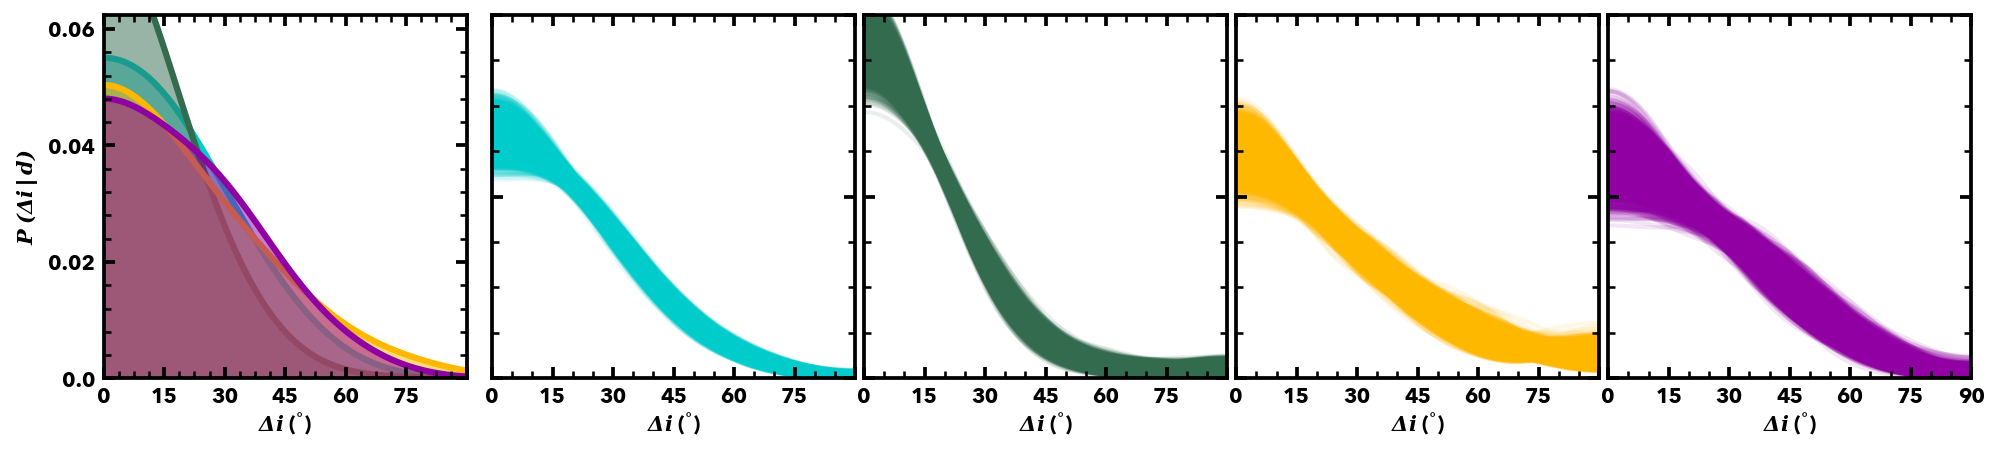

In [49]:
# PLOT KDE MONTE CARLO RESULTS

if do_kde_montecarlo_test == True:

    do_fill_between_KDE = False
    draw_alpha = 0.10
    draw_lw = 2

    # max_displayed = 150
    max_displayed = n_plot_distributions

    MC_kde_fontsize=10


    fig = plt.figure(figsize=(15, 2.5), dpi=150)
    axes = fig.subplot_mosaic(
    """
    a.bcde
    """,
    gridspec_kw={'height_ratios': [1], 'width_ratios': [1, 0.02, 1, 1, 1, 1], "bottom": 0.02, "top": 0.99, "left": 0.16, "right": 0.99, "wspace": 0.03, "hspace": 0.06}
    )
    
    ax = axes['a']
    ax.minorticks_on()

    ax.set_xlabel(r'$\Delta i$ ($^\degree$)', fontsize=MC_kde_fontsize, labelpad=2)
    ax.set_ylabel(r'$P$ $(\Delta i$ | $d)$', fontsize=MC_kde_fontsize)

    mean_PD = np.sum(x_grid_plot * density_estimation_total_positive_x_PD)
    mean_DD = np.sum(x_grid_plot * density_estimation_total_positive_x_DD)
    mean_WJ = np.sum(x_grid_plot * density_estimation_total_positive_x_WJ)
    mean_HJ = np.sum(x_grid_plot * density_estimation_total_positive_x_HJ)

    print('mean_PD: ' + str(mean_PD))
    print('mean_DD: ' + str(mean_DD))
    print('mean_WJ: ' + str(mean_WJ))
    print('mean_HJ: ' + str(mean_HJ))

    ax.plot(x_grid_plot, density_estimation_total_positive_x_PD, color=pd_color, alpha=1, lw=3, zorder=-11)
    ax.fill_between(x_grid_plot, density_estimation_total_positive_x_PD, color=pd_color, alpha=0.5, label='Protoplanetary Disks', zorder=-12)
    ax.plot(x_grid_plot, density_estimation_total_positive_x_DD, color=dd_color, alpha=1, lw=3, zorder=-10)
    ax.fill_between(x_grid_plot, density_estimation_total_positive_x_DD, color=dd_color, alpha=0.5, label='Debris Disks', zorder=-10)
    ax.plot(x_grid_plot, density_estimation_total_positive_x_WJ, color=WJ_color, lw=3, alpha=1, zorder=-9)
    ax.fill_between(x_grid_plot, density_estimation_total_positive_x_WJ, color=WJ_color, alpha=0.5, label='Warm Jupiters', zorder=-9)
    ax.plot(x_grid_plot, density_estimation_total_positive_x_HJ, color=HJ_color, lw=3, alpha=1, zorder=-8)
    ax.fill_between(x_grid_plot, density_estimation_total_positive_x_HJ, color=HJ_color, alpha=0.5, label='Hot Jupiters', zorder=-8)

    xmin_test, xmax_test = 0, 90
    ymin_test, ymax_test = 0, 1.10 * max(kde_975)

    ax.set_xlim(xmin_test, xmax_test)
    ax.set_ylim(ymin_test, ymax_test)

    xticks_major = [0, 15, 30, 45, 60, 75, 90]
    ax.set_xticks(xticks_major, minor=False)
    xlabels = [str(int(xtick)) for xtick in xticks_major]
    xlabels[-1] = ' '
    ax.set_xticklabels(xlabels, fontsize=MC_kde_fontsize)
    # ax.set_xticklabels(xticks_hist_minor, fontsize=Delta_i_hist_fontsize)
    # minor_locator = AutoMinorLocator(3)
    # ax.xaxis.set_minor_locator(minor_locator)

    yticks_a = np.arange(0, 0.11 + 0.02, 0.02)
    ax.set_yticklabels(yticks_a, fontsize=MC_kde_fontsize)


    # ----------------------

    for sample_type in sample_type_list:

        if sample_type == 'PD':
            which_dataset = 'PD'
            line_color = pd_color
            ax_letter = 'b'
        if sample_type == 'DD':
            which_dataset = 'DD'
            line_color = dd_color
            ax_letter = 'c'
        if sample_type == 'WJ':
            which_dataset = 'WJ'
            line_color = WJ_color
            ax_letter = 'd'
        if sample_type == 'HJ':
            which_dataset = 'HJ'
            line_color = HJ_color
            ax_letter = 'e'

        ax = axes[ax_letter]
        ax.minorticks_on()

        ax.set_xlabel(r'$\Delta i$ ($^\degree$)', fontsize=MC_kde_fontsize, labelpad=2)
        ax.set_ylabel('')

        kde_025 = np.array(KDE_sample_type_dict[sample_type]['2.5'])
        kde_16 = np.array(KDE_sample_type_dict[sample_type]['16'])
        kde_50 = np.array(KDE_sample_type_dict[sample_type]['50'])
        kde_84 = np.array(KDE_sample_type_dict[sample_type]['84'])
        kde_975 = np.array(KDE_sample_type_dict[sample_type]['97.5'])

        # ax.plot(x_grid_plot, nominal_kde, ls=':', dashes=(1, 1), color='#000000', lw=4, alpha=0.5, label='Nominal KDE', zorder=-3)
        
        plot_kde_nums = choices(np.arange(0, len(kdes_plot[sample_type]), 1), k=max_displayed)

        if do_fill_between_KDE == True:
            ax.fill_between(x_grid_plot_family, kde_975_plot[sample_type], kde_025_plot[sample_type], lw=0, color=line_color, alpha=0.3, zorder=-6)
            ax.fill_between(x_grid_plot_family, kde_84_plot[sample_type], kde_16_plot[sample_type], lw=0, color=line_color, alpha=1, zorder=-5)
        else:
            for kde_i, kde_i_plot in enumerate(kdes_plot[sample_type]):
                if kde_i in plot_kde_nums:
                    ax.plot(x_grid_plot_family, kde_i_plot, lw=draw_lw, linestyle='-', color=line_color, alpha=draw_alpha, zorder=-5)


        xmin_test, xmax_test = 0, 90
        ymin_test, ymax_test = 0, 0.03

        ax.set_xlim(xmin_test, xmax_test)
        ax.set_ylim(ymin_test, ymax_test)

        xticks_major = [0, 15, 30, 45, 60, 75, 90]
        ax.set_xticks(xticks_major, minor=False)
        xlabels = [str(int(xtick)) for xtick in xticks_major]
        if ax_letter != 'e':
            xlabels[-1] = ' '
        ax.set_xticklabels(xlabels, fontsize=MC_kde_fontsize)
        minor_locator = AutoMinorLocator(3)
        ax.xaxis.set_minor_locator(minor_locator)

        yticks = np.arange(ymin_test, ymax_test + 0.02, 0.02)
        ax.set_yticks(yticks)
        # if ax_letter == 'b':
        #     ax.set_yticklabels(yticks, fontsize=MC_kde_fontsize)
        # else:
        ax.set_yticklabels([], fontsize=MC_kde_fontsize)

    plt.show() 
    plt.close()

kde_i 9900


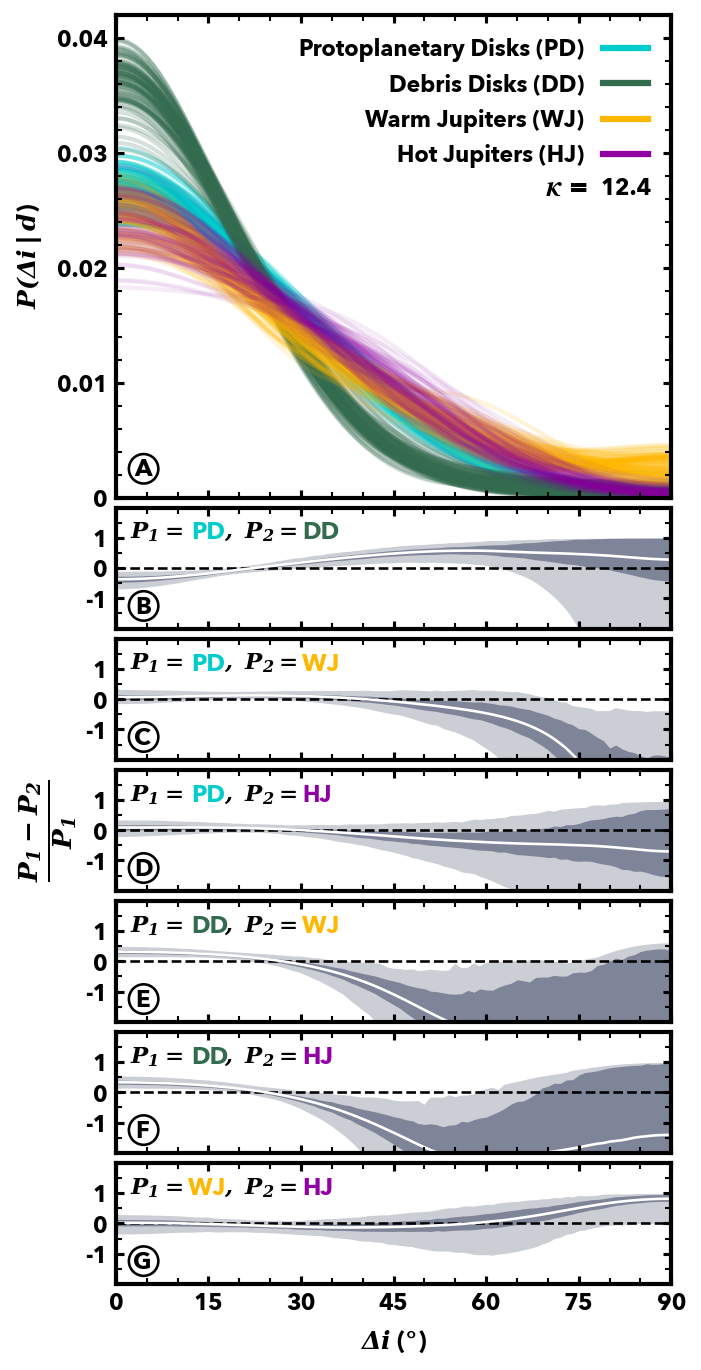

In [50]:
# PLOT THE RESIDUALS OF THE KDE FAMILIES

residual_stacked_plots_width = 4.5
residual_stacked_plots_height = 9.0

residual_stacked_plots_suptitlepad = 10
residual_stacked_plots_suptitle_fontsize = 10

residual_stacked_plots_labelpad = 6
residual_stacked_plots_label_fontsize = 11

residual_stacked_plots_tick_fontsize = 11

residual_text_fontsize = 12

face_text_size = 11

# max_displayed = 100
max_displayed = 100  # n_plot_distributions

# dd_color = '#336b4f'

fig = plt.figure(figsize=(residual_stacked_plots_width, residual_stacked_plots_height), dpi=150)
axes = fig.subplot_mosaic(
    """
    k
    j
    i
    h
    l
    m
    n
    """,
    gridspec_kw={'height_ratios': [1, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25], 'width_ratios': [1], "bottom": 0.05, "top": 0.99, "left": 0.152, "right": 0.975, "wspace": 0.10, "hspace": 0.06}
)

# axes['k'].set_title('KDEs Computed Using Random Draws From\nMeasurement Probability Distributions', fontsize=residual_stacked_plots_label_fontsize, pad=residual_stacked_plots_labelpad)
# ax.yaxis.label.set_family("DejaVu Serif")
# ax.xaxis.label.set_family("DejaVu Serif")
axes['k'].set_ylabel(r'$P(\Delta i$ | $d$)', fontsize=residual_stacked_plots_label_fontsize+1, labelpad=residual_stacked_plots_labelpad)
axes['n'].set_xlabel(r'$\Delta i$ ($\degree$)', fontsize=residual_stacked_plots_label_fontsize+1, labelpad=residual_stacked_plots_labelpad)
# axes['h'].set_ylabel(r'$\frac{P_1(\Delta i) - P_2(\Delta i)}{P_1(\Delta i)}$', fontsize=residual_stacked_plots_label_fontsize+8, labelpad=residual_stacked_plots_labelpad)  # , y=0)
axes['h'].set_ylabel(r'$\frac{P_1 - P_2}{P_1}$', fontsize=residual_stacked_plots_label_fontsize+7, labelpad=residual_stacked_plots_labelpad-3)  # , y=0)


# PD_HJ_color = combine_hex_values({"ffffff": 1.0, HJ_color[1:]: 0.5, pd_color[1:]: 0.05})
PD_HJ_color = combine_hex_values({HJ_color[1:]: 0.5, pd_color[1:]: 0.5})
PD_WJ_color = combine_hex_values({WJ_color[1:]: 0.2, pd_color[1:]: 0.2, "604020": 0.6})
PD_DD_color = combine_hex_values({dd_color[1:]: 0.3, pd_color[1:]: 0.7})
DD_HJ_color = combine_hex_values({dd_color[1:]: 0.5, HJ_color[1:]: 0.5})
DD_WJ_color = combine_hex_values({dd_color[1:]: 0.4, WJ_color[1:]: 0.6})
WJ_HJ_color = combine_hex_values({WJ_color[1:]: 0.35, HJ_color[1:]: 0.65})


for sample_type in sample_type_list:
    if sample_type == 'PD':
        line_color = pd_color
        draw_alpha = 0.3
        PD_kdes = []
        plot_zorder = -10
    if sample_type == 'DD':
        line_color = dd_color
        draw_alpha = 0.2
        DD_kdes = []
        plot_zorder = -8
    if sample_type == 'WJ':
        line_color = WJ_color
        draw_alpha = 0.15
        WJ_kdes = []
        plot_zorder = -6
    if sample_type == 'HJ':
        line_color = HJ_color
        draw_alpha = 0.075
        HJ_kdes = []
        plot_zorder = -4
    do_fill_between_KDE = False
    if do_fill_between_KDE == True:
        axes['k'].fill_between(x_grid_plot, kde_975_plot[sample_type], kde_025_plot[sample_type], lw=0, color=line_color, alpha=0.2, zorder=plot_zorder)
        axes['k'].fill_between(x_grid_plot, kde_84_plot[sample_type], kde_16_plot[sample_type], lw=0, color=line_color, alpha=0.7, zorder=plot_zorder+1)
        
    plot_kde_nums = choices(np.arange(0, len(kdes_plot[sample_type]), 1), k=max_displayed)

    for kde_i, kde_i_plot in enumerate(kdes_plot[sample_type]):

        if do_fill_between_KDE == False:
            if kde_i in plot_kde_nums:
                # print(x_grid_plot)
                axes['k'].plot(x_grid_plot, kde_i_plot, lw=draw_lw, linestyle='-', color=line_color, alpha=draw_alpha, zorder=-20)
        if sample_type == 'PD':
            PD_kdes.append(kde_i_plot)
        if sample_type == 'DD':
            DD_kdes.append(kde_i_plot)
        if sample_type == 'WJ':
            WJ_kdes.append(kde_i_plot)
        if sample_type == 'HJ':
            HJ_kdes.append(kde_i_plot)


axes['k'].text(4.4, 0.0024, 'A', horizontalalignment='center', verticalalignment='center', fontsize=face_text_size+0.5)
axes['k'].scatter(4.5, 0.0025, s=200, c='None', ec='#000000', lw=1.25)


PD_minus_HJ_residuals = []
PD_minus_WJ_residuals = []
PD_minus_DD_residuals = []
DD_minus_WJ_residuals = []
DD_minus_HJ_residuals = []
WJ_minus_HJ_residuals = []


residual_color_dark = '#1c344a'
residual_color_light = '#d9e6f2'

residual_alpha_dark = 0.125
residual_alpha_light = 0.075

plot_all_lines = False




for kde_i in range(min([len(PD_kdes), len(DD_kdes), len(WJ_kdes), len(HJ_kdes)])):

    PD_minus_HJ_residual = (PD_kdes[kde_i] - HJ_kdes[kde_i])/(PD_kdes[kde_i])
    PD_minus_WJ_residual = (PD_kdes[kde_i] - WJ_kdes[kde_i])/(PD_kdes[kde_i])
    PD_minus_DD_residual = (PD_kdes[kde_i] - DD_kdes[kde_i])/(PD_kdes[kde_i])
    DD_minus_WJ_residual = (DD_kdes[kde_i] - WJ_kdes[kde_i])/(DD_kdes[kde_i])
    DD_minus_HJ_residual = (DD_kdes[kde_i] - HJ_kdes[kde_i])/(DD_kdes[kde_i])
    WJ_minus_HJ_residual = (WJ_kdes[kde_i] - HJ_kdes[kde_i])/(WJ_kdes[kde_i])

    PD_minus_HJ_residuals.append(PD_minus_HJ_residual)
    PD_minus_WJ_residuals.append(PD_minus_WJ_residual)
    PD_minus_DD_residuals.append(PD_minus_DD_residual)
    DD_minus_WJ_residuals.append(DD_minus_WJ_residual)
    DD_minus_HJ_residuals.append(DD_minus_HJ_residual)
    WJ_minus_HJ_residuals.append(WJ_minus_HJ_residual)
    
    if plot_all_lines == True:
        if kde_i in plot_kde_nums:
            axes['h'].plot(x_grid_plot, PD_minus_HJ_residual, color=residual_color_dark, alpha=residual_alpha_dark, lw=1.25, zorder=-11)
            axes['i'].plot(x_grid_plot, PD_minus_WJ_residual, color=residual_color_dark, alpha=residual_alpha_dark, lw=1.25, zorder=-11)
            axes['j'].plot(x_grid_plot, PD_minus_DD_residual, color=residual_color_dark, alpha=residual_alpha_dark, lw=1.25, zorder=-11)
            axes['l'].plot(x_grid_plot, DD_minus_WJ_residual, color=residual_color_dark, alpha=residual_alpha_dark, lw=1.25, zorder=-11)
            axes['m'].plot(x_grid_plot, DD_minus_HJ_residual, color=residual_color_dark, alpha=residual_alpha_dark, lw=1.25, zorder=-11)
            axes['n'].plot(x_grid_plot, WJ_minus_HJ_residual, color=residual_color_dark, alpha=residual_alpha_dark, lw=1.25, zorder=-11)

print("kde_i", kde_i)

mean_PD_minus_HJ_residuals = np.mean(PD_minus_HJ_residuals, axis=0)
mean_PD_minus_WJ_residuals = np.mean(PD_minus_WJ_residuals, axis=0)
mean_PD_minus_DD_residuals = np.mean(PD_minus_DD_residuals, axis=0)
mean_DD_minus_WJ_residuals = np.mean(DD_minus_WJ_residuals, axis=0)
mean_DD_minus_HJ_residuals = np.mean(DD_minus_HJ_residuals, axis=0)
mean_WJ_minus_HJ_residuals = np.mean(WJ_minus_HJ_residuals, axis=0)

p50_PD_minus_HJ_residuals = np.percentile(PD_minus_HJ_residuals, 50, axis=0)
p50_PD_minus_WJ_residuals = np.percentile(PD_minus_WJ_residuals, 50, axis=0)
p50_PD_minus_DD_residuals = np.percentile(PD_minus_DD_residuals, 50, axis=0)
p50_DD_minus_WJ_residuals = np.percentile(DD_minus_WJ_residuals, 50, axis=0)
p50_DD_minus_HJ_residuals = np.percentile(DD_minus_HJ_residuals, 50, axis=0)
p50_WJ_minus_HJ_residuals = np.percentile(WJ_minus_HJ_residuals, 50, axis=0)

p84_PD_minus_HJ_residuals = np.percentile(PD_minus_HJ_residuals, 84, axis=0)
p84_PD_minus_WJ_residuals = np.percentile(PD_minus_WJ_residuals, 84, axis=0)
p84_PD_minus_DD_residuals = np.percentile(PD_minus_DD_residuals, 84, axis=0)
p84_DD_minus_WJ_residuals = np.percentile(DD_minus_WJ_residuals, 84, axis=0)
p84_DD_minus_HJ_residuals = np.percentile(DD_minus_HJ_residuals, 84, axis=0)
p84_WJ_minus_HJ_residuals = np.percentile(WJ_minus_HJ_residuals, 84, axis=0)

p16_PD_minus_HJ_residuals = np.percentile(PD_minus_HJ_residuals, 16, axis=0)
p16_PD_minus_WJ_residuals = np.percentile(PD_minus_WJ_residuals, 16, axis=0)
p16_PD_minus_DD_residuals = np.percentile(PD_minus_DD_residuals, 16, axis=0)
p16_DD_minus_WJ_residuals = np.percentile(DD_minus_WJ_residuals, 16, axis=0)
p16_DD_minus_HJ_residuals = np.percentile(DD_minus_HJ_residuals, 16, axis=0)
p16_WJ_minus_HJ_residuals = np.percentile(WJ_minus_HJ_residuals, 16, axis=0)

p015_PD_minus_HJ_residuals = np.percentile(PD_minus_HJ_residuals, 0.15, axis=0)
p015_PD_minus_WJ_residuals = np.percentile(PD_minus_WJ_residuals, 0.15, axis=0)
p015_PD_minus_DD_residuals = np.percentile(PD_minus_DD_residuals, 0.15, axis=0)
p015_DD_minus_WJ_residuals = np.percentile(DD_minus_WJ_residuals, 0.15, axis=0)
p015_DD_minus_HJ_residuals = np.percentile(DD_minus_HJ_residuals, 0.15, axis=0)
p015_WJ_minus_HJ_residuals = np.percentile(WJ_minus_HJ_residuals, 0.15, axis=0)

p9985_PD_minus_HJ_residuals = np.percentile(PD_minus_HJ_residuals, 99.85, axis=0)
p9985_PD_minus_WJ_residuals = np.percentile(PD_minus_WJ_residuals, 99.85, axis=0)
p9985_PD_minus_DD_residuals = np.percentile(PD_minus_DD_residuals, 99.85, axis=0)
p9985_DD_minus_WJ_residuals = np.percentile(DD_minus_WJ_residuals, 99.85, axis=0)
p9985_DD_minus_HJ_residuals = np.percentile(DD_minus_HJ_residuals, 99.85, axis=0)
p9985_WJ_minus_HJ_residuals = np.percentile(WJ_minus_HJ_residuals, 99.85, axis=0)

hdi68_PD_minus_HJ_lo = []
hdi68_PD_minus_HJ_hi = []
hdi68_PD_minus_WJ_lo = []
hdi68_PD_minus_WJ_hi = []
hdi68_PD_minus_DD_lo = []
hdi68_PD_minus_DD_hi = []
hdi68_DD_minus_WJ_lo = []
hdi68_DD_minus_WJ_hi = []
hdi68_DD_minus_HJ_lo = []
hdi68_DD_minus_HJ_hi = []
hdi68_WJ_minus_HJ_lo = []
hdi68_WJ_minus_HJ_hi = []

hdi997_PD_minus_HJ_lo = []
hdi997_PD_minus_HJ_hi = []
hdi997_PD_minus_WJ_lo = []
hdi997_PD_minus_WJ_hi = []
hdi997_PD_minus_DD_lo = []
hdi997_PD_minus_DD_hi = []
hdi997_DD_minus_WJ_lo = []
hdi997_DD_minus_WJ_hi = []
hdi997_DD_minus_HJ_lo = []
hdi997_DD_minus_HJ_hi = []
hdi997_WJ_minus_HJ_lo = []
hdi997_WJ_minus_HJ_hi = []

PD_minus_HJ_residuals_transposed = np.array(PD_minus_HJ_residuals).T
PD_minus_WJ_residuals_transposed = np.array(PD_minus_WJ_residuals).T
PD_minus_DD_residuals_transposed = np.array(PD_minus_DD_residuals).T
DD_minus_WJ_residuals_transposed = np.array(DD_minus_WJ_residuals).T
DD_minus_HJ_residuals_transposed = np.array(DD_minus_HJ_residuals).T
WJ_minus_HJ_residuals_transposed = np.array(WJ_minus_HJ_residuals).T    

for element_i in range(len(x_grid_plot)):
    hdi68_PD_minus_HJ_lo_i, hdi68_PD_minus_HJ_hi_i = az.hdi(PD_minus_HJ_residuals_transposed[element_i], hdi_prob=0.68)
    hdi68_PD_minus_WJ_lo_i, hdi68_PD_minus_WJ_hi_i = az.hdi(PD_minus_WJ_residuals_transposed[element_i], hdi_prob=0.68)
    hdi68_PD_minus_DD_lo_i, hdi68_PD_minus_DD_hi_i = az.hdi(PD_minus_DD_residuals_transposed[element_i], hdi_prob=0.68)
    hdi68_DD_minus_WJ_lo_i, hdi68_DD_minus_WJ_hi_i = az.hdi(DD_minus_WJ_residuals_transposed[element_i], hdi_prob=0.68)
    hdi68_DD_minus_HJ_lo_i, hdi68_DD_minus_HJ_hi_i = az.hdi(DD_minus_HJ_residuals_transposed[element_i], hdi_prob=0.68)
    hdi68_WJ_minus_HJ_lo_i, hdi68_WJ_minus_HJ_hi_i = az.hdi(WJ_minus_HJ_residuals_transposed[element_i], hdi_prob=0.68)

    hdi997_PD_minus_HJ_lo_i, hdi997_PD_minus_HJ_hi_i = az.hdi(PD_minus_HJ_residuals_transposed[element_i], hdi_prob=0.997)
    hdi997_PD_minus_WJ_lo_i, hdi997_PD_minus_WJ_hi_i = az.hdi(PD_minus_WJ_residuals_transposed[element_i], hdi_prob=0.997)
    hdi997_PD_minus_DD_lo_i, hdi997_PD_minus_DD_hi_i = az.hdi(PD_minus_DD_residuals_transposed[element_i], hdi_prob=0.997)
    hdi997_DD_minus_WJ_lo_i, hdi997_DD_minus_WJ_hi_i = az.hdi(DD_minus_WJ_residuals_transposed[element_i], hdi_prob=0.997)
    hdi997_DD_minus_HJ_lo_i, hdi997_DD_minus_HJ_hi_i = az.hdi(DD_minus_HJ_residuals_transposed[element_i], hdi_prob=0.997)
    hdi997_WJ_minus_HJ_lo_i, hdi997_WJ_minus_HJ_hi_i = az.hdi(WJ_minus_HJ_residuals_transposed[element_i], hdi_prob=0.997)

    hdi68_PD_minus_HJ_lo.append(hdi68_PD_minus_HJ_lo_i)
    hdi68_PD_minus_HJ_hi.append(hdi68_PD_minus_HJ_hi_i)
    hdi68_PD_minus_WJ_lo.append(hdi68_PD_minus_WJ_lo_i)
    hdi68_PD_minus_WJ_hi.append(hdi68_PD_minus_WJ_hi_i)
    hdi68_PD_minus_DD_lo.append(hdi68_PD_minus_DD_lo_i)
    hdi68_PD_minus_DD_hi.append(hdi68_PD_minus_DD_hi_i)
    hdi68_DD_minus_WJ_lo.append(hdi68_DD_minus_WJ_lo_i)
    hdi68_DD_minus_WJ_hi.append(hdi68_DD_minus_WJ_hi_i)
    hdi68_DD_minus_HJ_lo.append(hdi68_DD_minus_HJ_lo_i)
    hdi68_DD_minus_HJ_hi.append(hdi68_DD_minus_HJ_hi_i)
    hdi68_WJ_minus_HJ_lo.append(hdi68_WJ_minus_HJ_lo_i)
    hdi68_WJ_minus_HJ_hi.append(hdi68_WJ_minus_HJ_hi_i)

    hdi997_PD_minus_HJ_lo.append(hdi997_PD_minus_HJ_lo_i)
    hdi997_PD_minus_HJ_hi.append(hdi997_PD_minus_HJ_hi_i)
    hdi997_PD_minus_WJ_lo.append(hdi997_PD_minus_WJ_lo_i)
    hdi997_PD_minus_WJ_hi.append(hdi997_PD_minus_WJ_hi_i)
    hdi997_PD_minus_DD_lo.append(hdi997_PD_minus_DD_lo_i)
    hdi997_PD_minus_DD_hi.append(hdi997_PD_minus_DD_hi_i)
    hdi997_DD_minus_WJ_lo.append(hdi997_DD_minus_WJ_lo_i)
    hdi997_DD_minus_WJ_hi.append(hdi997_DD_minus_WJ_hi_i)
    hdi997_DD_minus_HJ_lo.append(hdi997_DD_minus_HJ_lo_i)
    hdi997_DD_minus_HJ_hi.append(hdi997_DD_minus_HJ_hi_i)
    hdi997_WJ_minus_HJ_lo.append(hdi997_WJ_minus_HJ_lo_i)
    hdi997_WJ_minus_HJ_hi.append(hdi997_WJ_minus_HJ_hi_i)



p50_color = '#ffffff'

# axes['h'].plot(x_grid_plot, mean_PD_minus_HJ_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)
# axes['i'].plot(x_grid_plot, mean_PD_minus_WJ_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)
# axes['j'].plot(x_grid_plot, mean_PD_minus_DD_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)
# axes['l'].plot(x_grid_plot, mean_DD_minus_WJ_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)
# axes['m'].plot(x_grid_plot, mean_DD_minus_HJ_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)
# axes['n'].plot(x_grid_plot, mean_WJ_minus_HJ_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)

axes['h'].plot(x_grid_plot, p50_PD_minus_HJ_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)
axes['i'].plot(x_grid_plot, p50_PD_minus_WJ_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)
axes['j'].plot(x_grid_plot, p50_PD_minus_DD_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)
axes['l'].plot(x_grid_plot, p50_DD_minus_WJ_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)
axes['m'].plot(x_grid_plot, p50_DD_minus_HJ_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)
axes['n'].plot(x_grid_plot, p50_WJ_minus_HJ_residuals, color=p50_color, alpha=1, lw=1.25, zorder=-11)

if plot_all_lines == True:
    fill_color = '#a3abc2'  # '#d9e6f2'
    fill_color_9985 = '#a3abc2' # "#9fb6fa"
    alpha_fill = 1
    alpha_fill_9985 = 0.3
else:
    fill_color = "#7f8598"  # '#d9e6f2'
    fill_color_9985 = "#7f8598" # "#9fb6fa"
    alpha_fill = 1
    alpha_fill_9985 = 0.4

# smooth_degr = 2
# smooth_over = smooth_degr/np.diff(x_grid_plot)[0]

# hdi68_PD_minus_HJ_hi = gaussian_filter1d(hdi68_PD_minus_HJ_hi, smooth_over)
# hdi68_PD_minus_HJ_lo = gaussian_filter1d(hdi68_PD_minus_HJ_lo, smooth_over)
# hdi68_PD_minus_WJ_hi = gaussian_filter1d(hdi68_PD_minus_WJ_hi, smooth_over)
# hdi68_PD_minus_WJ_lo = gaussian_filter1d(hdi68_PD_minus_WJ_lo, smooth_over)
# hdi68_PD_minus_DD_hi = gaussian_filter1d(hdi68_PD_minus_DD_hi, smooth_over)
# hdi68_PD_minus_DD_lo = gaussian_filter1d(hdi68_PD_minus_DD_lo, smooth_over)
# hdi68_DD_minus_WJ_hi = gaussian_filter1d(hdi68_DD_minus_WJ_hi, smooth_over)
# hdi68_DD_minus_WJ_lo = gaussian_filter1d(hdi68_DD_minus_WJ_lo, smooth_over)

# hdi997_PD_minus_HJ_hi = gaussian_filter1d(hdi997_PD_minus_HJ_hi, smooth_over)
# hdi997_PD_minus_HJ_lo = gaussian_filter1d(hdi997_PD_minus_HJ_lo, smooth_over)
# hdi997_PD_minus_WJ_hi = gaussian_filter1d(hdi997_PD_minus_WJ_hi, smooth_over)
# hdi997_PD_minus_WJ_lo = gaussian_filter1d(hdi997_PD_minus_WJ_lo, smooth_over)
# hdi997_PD_minus_DD_hi = gaussian_filter1d(hdi997_PD_minus_DD_hi, smooth_over)
# hdi997_PD_minus_DD_lo = gaussian_filter1d(hdi997_PD_minus_DD_lo, smooth_over)
# hdi997_DD_minus_WJ_hi = gaussian_filter1d(hdi997_DD_minus_WJ_hi, smooth_over)
# hdi997_DD_minus_WJ_lo = gaussian_filter1d(hdi997_DD_minus_WJ_lo, smooth_over)


axes['h'].fill_between(x_grid_plot, hdi68_PD_minus_HJ_hi, hdi68_PD_minus_HJ_lo, color=fill_color, alpha=alpha_fill, lw=0, zorder=-1000)
axes['i'].fill_between(x_grid_plot, hdi68_PD_minus_WJ_hi, hdi68_PD_minus_WJ_lo, color=fill_color, alpha=alpha_fill, lw=0, zorder=-1000)
axes['j'].fill_between(x_grid_plot, hdi68_PD_minus_DD_hi, hdi68_PD_minus_DD_lo, color=fill_color, alpha=alpha_fill, lw=0, zorder=-1000)
axes['l'].fill_between(x_grid_plot, hdi68_DD_minus_WJ_hi, hdi68_DD_minus_WJ_lo, color=fill_color, alpha=alpha_fill, lw=0, zorder=-1000)
axes['m'].fill_between(x_grid_plot, hdi68_DD_minus_HJ_hi, hdi68_DD_minus_HJ_lo, color=fill_color, alpha=alpha_fill, lw=0, zorder=-1000)
axes['n'].fill_between(x_grid_plot, hdi68_WJ_minus_HJ_hi, hdi68_WJ_minus_HJ_lo, color=fill_color, alpha=alpha_fill, lw=0, zorder=-1000)

axes['h'].fill_between(x_grid_plot, hdi997_PD_minus_HJ_hi, hdi997_PD_minus_HJ_lo, color=fill_color_9985, alpha=alpha_fill_9985, lw=0, zorder=-1000)
axes['i'].fill_between(x_grid_plot, hdi997_PD_minus_WJ_hi, hdi997_PD_minus_WJ_lo, color=fill_color_9985, alpha=alpha_fill_9985, lw=0, zorder=-1000)
axes['j'].fill_between(x_grid_plot, hdi997_PD_minus_DD_hi, hdi997_PD_minus_DD_lo, color=fill_color_9985, alpha=alpha_fill_9985, lw=0, zorder=-1000)
axes['l'].fill_between(x_grid_plot, hdi997_DD_minus_WJ_hi, hdi997_DD_minus_WJ_lo, color=fill_color_9985, alpha=alpha_fill_9985, lw=0, zorder=-1000)
axes['m'].fill_between(x_grid_plot, hdi997_DD_minus_HJ_hi, hdi997_DD_minus_HJ_lo, color=fill_color_9985, alpha=alpha_fill_9985, lw=0, zorder=-1000)
axes['n'].fill_between(x_grid_plot, hdi997_WJ_minus_HJ_hi, hdi997_WJ_minus_HJ_lo, color=fill_color_9985, alpha=alpha_fill_9985, lw=0, zorder=-1000)

# axes['h'].fill_between(x_grid_plot, p84_PD_minus_HJ_residuals, p16_PD_minus_HJ_residuals, color="#9F7676", alpha=alpha_fill, lw=0, zorder=-1000)
# axes['i'].fill_between(x_grid_plot, p84_PD_minus_WJ_residuals, p16_PD_minus_WJ_residuals, color="#9F7676", alpha=alpha_fill, lw=0, zorder=-1000)
# axes['j'].fill_between(x_grid_plot, p84_PD_minus_DD_residuals, p16_PD_minus_DD_residuals, color="#9F7676", alpha=alpha_fill, lw=0, zorder=-1000)
# axes['l'].fill_between(x_grid_plot, p84_DD_minus_WJ_residuals, p16_DD_minus_WJ_residuals, color="#9F7676", alpha=alpha_fill, lw=0, zorder=-1000)
# axes['m'].fill_between(x_grid_plot, p84_DD_minus_HJ_residuals, p16_DD_minus_HJ_residuals, color="#9F7676", alpha=alpha_fill, lw=0, zorder=-1000)
# axes['n'].fill_between(x_grid_plot, p84_WJ_minus_HJ_residuals, p16_WJ_minus_HJ_residuals, color="#9F7676", alpha=alpha_fill, lw=0, zorder=-1000)

# axes['h'].fill_between(x_grid_plot, p9985_PD_minus_HJ_residuals, p015_PD_minus_HJ_residuals, color="#9F7676", alpha=alpha_fill_9985, lw=0, zorder=-1000)
# axes['i'].fill_between(x_grid_plot, p9985_PD_minus_WJ_residuals, p015_PD_minus_WJ_residuals, color="#9F7676", alpha=alpha_fill_9985, lw=0, zorder=-1000)
# axes['j'].fill_between(x_grid_plot, p9985_PD_minus_DD_residuals, p015_PD_minus_DD_residuals, color="#9F7676", alpha=alpha_fill_9985, lw=0, zorder=-1000)
# axes['l'].fill_between(x_grid_plot, p9985_DD_minus_WJ_residuals, p015_DD_minus_WJ_residuals, color="#9F7676", alpha=alpha_fill_9985, lw=0, zorder=-1000)
# axes['m'].fill_between(x_grid_plot, p9985_DD_minus_HJ_residuals, p015_DD_minus_HJ_residuals, color="#9F7676", alpha=alpha_fill_9985, lw=0, zorder=-1000)
# axes['n'].fill_between(x_grid_plot, p9985_WJ_minus_HJ_residuals, p015_WJ_minus_HJ_residuals, color="#9F7676", alpha=alpha_fill_9985, lw=0, zorder=-1000)
dotted_line_width = 1.25

axes['h'].plot([min(x_grid_plot),max(x_grid_plot)], [0, 0], ls='--', color='#000000', lw=dotted_line_width, alpha=1, zorder=-21)
axes['i'].plot([min(x_grid_plot),max(x_grid_plot)], [0, 0], ls='--', color='#000000', lw=dotted_line_width, alpha=1, zorder=-21)
axes['j'].plot([min(x_grid_plot),max(x_grid_plot)], [0, 0], ls='--', color='#000000', lw=dotted_line_width, alpha=1, zorder=-21)
axes['l'].plot([min(x_grid_plot),max(x_grid_plot)], [0, 0], ls='--', color='#000000', lw=dotted_line_width, alpha=1, zorder=-21)
axes['m'].plot([min(x_grid_plot),max(x_grid_plot)], [0, 0], ls='--', color='#000000', lw=dotted_line_width, alpha=1, zorder=-21)
axes['n'].plot([min(x_grid_plot),max(x_grid_plot)], [0, 0], ls='--', color='#000000', lw=dotted_line_width, alpha=1, zorder=-21)

axes['k'].plot([], [], color=pd_color, alpha=1, lw=3, label='Protoplanetary Disks (PD)', zorder=-11)
axes['k'].plot([], [], color=dd_color, alpha=1, lw=3, label='Debris Disks (DD)', zorder=-10)
axes['k'].plot([], [], color=WJ_color, lw=3, alpha=1, label='Warm Jupiters (WJ)', zorder=-9)
axes['k'].plot([], [], color=HJ_color, lw=3, alpha=1, label='Hot Jupiters (HJ)', zorder=-8)


# residual_ylim = [-0.02, 0.02]
residual_ylim = [-2, 2]

hatch_x = [0, 10]
hatch_y1 = [residual_ylim[1], residual_ylim[1]]
hatch_y2 = [residual_ylim[0], residual_ylim[0]]
hatch_color = '#28288a'
hatch_design = '///'
hatch_alpha = 0.2
plt.rcParams['hatch.linewidth'] = 1
# axes['k'].fill_between(hatch_x, [0.5, 0.5], [0, 0], hatch=hatch_design, color=hatch_color, facecolor="None", alpha=hatch_alpha, lw=1, zorder=-1)
# axes['h'].fill_between(hatch_x, hatch_y1, hatch_y2, hatch=hatch_design, color=hatch_color, facecolor="None", alpha=hatch_alpha, lw=1, zorder=-1)
# axes['i'].fill_between(hatch_x, hatch_y1, hatch_y2, hatch=hatch_design, color=hatch_color, facecolor="None", alpha=hatch_alpha, lw=1, zorder=-1)
# axes['j'].fill_between(hatch_x, hatch_y1, hatch_y2, hatch=hatch_design, color=hatch_color, facecolor="None", alpha=hatch_alpha, lw=1, zorder=-1)
# axes['l'].fill_between(hatch_x, hatch_y1, hatch_y2, hatch=hatch_design, color=hatch_color, facecolor="None", alpha=hatch_alpha, lw=1, zorder=-1)
# axes['m'].fill_between(hatch_x, hatch_y1, hatch_y2, hatch=hatch_design, color=hatch_color, facecolor="None", alpha=hatch_alpha, lw=1, zorder=-1)
# axes['n'].fill_between(hatch_x, hatch_y1, hatch_y2, hatch=hatch_design, color=hatch_color, facecolor="None", alpha=hatch_alpha, lw=1, zorder=-1)

mpl.rcParams['mathtext.fontset'] = 'stix'
axes['k'].text(0.85, 0.64, r'$\kappa$ =', horizontalalignment='right', verticalalignment='center', fontsize=14, transform=axes['k'].transAxes, color='#000000')
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
axes['k'].text(0.965, 0.64, str(band_width_same), horizontalalignment='right', verticalalignment='center', fontsize=residual_stacked_plots_label_fontsize, transform=axes['k'].transAxes, weight='semibold', color='#000000')

text_x_shift = 0  # 8./90.
text_y_shift = 0.025
text_x_shift_label = -0.5
text_y_shift_label = 0.05


axes['h'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['h'].transAxes, color='#000000')
axes['h'].text(0.90*(13.5/90)+text_x_shift, 0.765+text_y_shift, r'PD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['h'].transAxes, color=pd_color)
axes['h'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['h'].transAxes, weight='heavy')
axes['h'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'HJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0., transform=axes['h'].transAxes, color=HJ_color)
axes['h'].text(4.925+text_x_shift_label, -0.68*residual_ylim[-1]+text_y_shift_label, 'D', horizontalalignment='center', verticalalignment='center', fontsize=face_text_size+0.5)
axes['h'].scatter(5+text_x_shift_label, -0.65*residual_ylim[-1]+text_y_shift_label, s=200, c='None', ec='#000000', lw=1.25)

axes['i'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['i'].transAxes, color='#000000')
axes['i'].text(0.90*(13.5/90)+text_x_shift, 0.765+text_y_shift, r'PD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['i'].transAxes, color=pd_color)
axes['i'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['i'].transAxes, weight='heavy')
axes['i'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'WJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['i'].transAxes, color=WJ_color)
axes['i'].text(4.85+text_x_shift_label, -0.68*residual_ylim[-1]+text_y_shift_label, 'C', horizontalalignment='center', verticalalignment='center', fontsize=face_text_size+0.5)
axes['i'].scatter(5+text_x_shift_label, -0.65*residual_ylim[-1]+text_y_shift_label, s=200, c='None', ec='#000000', lw=1.25)

axes['j'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['j'].transAxes, color='#000000')
axes['j'].text(0.90*(13.5/90)+text_x_shift, 0.765+text_y_shift, r'PD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['j'].transAxes, color=pd_color)
axes['j'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['j'].transAxes, weight='heavy')
axes['j'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'DD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['j'].transAxes, color=dd_color)
axes['j'].text(4.925+text_x_shift_label, -0.68*residual_ylim[-1]+text_y_shift_label, 'B', horizontalalignment='center', verticalalignment='center', fontsize=face_text_size+0.5)
axes['j'].scatter(5+text_x_shift_label, -0.65*residual_ylim[-1]+text_y_shift_label, s=200, c='None', ec='#000000', lw=1.25)

axes['l'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['l'].transAxes, color='#000000')
axes['l'].text(0.90*(13.5/90)+text_x_shift, 0.765+text_y_shift, r'DD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['l'].transAxes, color=dd_color)
axes['l'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['l'].transAxes, weight='heavy')
axes['l'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'WJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['l'].transAxes, color=WJ_color)
axes['l'].text(4.85+text_x_shift_label, -0.68*residual_ylim[-1]+text_y_shift_label, 'E', horizontalalignment='center', verticalalignment='center', fontsize=face_text_size+0.5)
axes['l'].scatter(5+text_x_shift_label, -0.65*residual_ylim[-1]+text_y_shift_label, s=200, c='None', ec='#000000', lw=1.25)

axes['m'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['m'].transAxes, color='#000000')
axes['m'].text(0.90*(13.5/90)+text_x_shift, 0.765+text_y_shift, r'DD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['m'].transAxes, color=dd_color)
axes['m'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['m'].transAxes, weight='heavy')
axes['m'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'HJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['m'].transAxes, color=HJ_color)
axes['m'].text(4.85+text_x_shift_label, -0.68*residual_ylim[-1]+text_y_shift_label, 'F', horizontalalignment='center', verticalalignment='center', fontsize=face_text_size+0.5)
axes['m'].scatter(5+text_x_shift_label, -0.65*residual_ylim[-1]+text_y_shift_label, s=200, c='None', ec='#000000', lw=1.25)

axes['n'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['n'].transAxes, color='#000000')
axes['n'].text(0.90*(13./90)+text_x_shift, 0.765+text_y_shift, r'WJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['n'].transAxes, color=WJ_color)
axes['n'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['n'].transAxes, weight='heavy')
axes['n'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'HJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['n'].transAxes, color=HJ_color)
axes['n'].text(4.85+text_x_shift_label, -0.68*residual_ylim[-1]+text_y_shift_label, 'G', horizontalalignment='center', verticalalignment='center', fontsize=face_text_size+0.5)
axes['n'].scatter(5+text_x_shift_label, -0.65*residual_ylim[-1]+text_y_shift_label, s=200, c='None', ec='#000000', lw=1.25)

axes['h'].tick_params(which='minor', length=4.5, width=2, labelsize=residual_stacked_plots_label_fontsize)
axes['h'].tick_params(which='major', length=7.5, width=3, labelsize=residual_stacked_plots_label_fontsize)
axes['n'].tick_params(which='minor', length=4.5, width=2, labelsize=residual_stacked_plots_label_fontsize)
axes['n'].tick_params(which='major', length=7.5, width=3, labelsize=residual_stacked_plots_label_fontsize)


for ax in axes.keys():
    axes[ax].minorticks_on()
    axes[ax].set_rasterized(True)

    for spine in axes[ax].spines.values():
        spine.set_linewidth(2)

    # SPECIFY THE X TICKS
    xticks = [0, 15, 30, 45, 60, 75, 90]
    xticklabels = [str(int(xtick)) for xtick in xticks]
    axes[ax].set_xticks(xticks)
    if (ax == 'n'):
        axes[ax].set_xticklabels(xticklabels, fontsize=residual_stacked_plots_tick_fontsize, zorder=10)
    else:
        axes[ax].set_xticklabels([])

    axes[ax].set_xlim(0, 90)
    axes['h'].set_ylim(residual_ylim)
    axes['i'].set_ylim(residual_ylim)
    axes['j'].set_ylim(residual_ylim)
    axes['k'].set_ylim(0, 0.042)
    axes['l'].set_ylim(residual_ylim)
    axes['m'].set_ylim(residual_ylim)
    axes['n'].set_ylim(residual_ylim)

    yticks = [0, 0.01, 0.02, 0.03, 0.04]
    axes['k'].set_yticks(yticks)
    axes['k'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)

    # yticks = np.array([-0.01, 0, 0.01])
    yticks = np.array([-1, 0, 1])
    axes['h'].set_yticks(yticks) #, fontsize=residual_stacked_plots_tick_fontsize)
    axes['h'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)
    axes['i'].set_yticks(yticks) #, fontsize=residual_stacked_plots_tick_fontsize)
    axes['i'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)
    axes['j'].set_yticks(yticks) #, fontsize=residual_stacked_plots_tick_fontsize)
    axes['j'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)
    axes['l'].set_yticks(yticks) #, fontsize=residual_stacked_plots_tick_fontsize)
    axes['l'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)
    axes['m'].set_yticks(yticks) #, fontsize=residual_stacked_plots_tick_fontsize)
    axes['m'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)
    axes['n'].set_yticks(yticks) #, fontsize=residual_stacked_plots_tick_fontsize)
    axes['n'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)

    yticks_minor = AutoMinorLocator(2) 
    axes['h'].yaxis.set_minor_locator(yticks_minor)
    axes['i'].yaxis.set_minor_locator(yticks_minor)
    axes['j'].yaxis.set_minor_locator(yticks_minor)
    axes['l'].yaxis.set_minor_locator(yticks_minor)
    axes['m'].yaxis.set_minor_locator(yticks_minor)
    axes['n'].yaxis.set_minor_locator(yticks_minor)

    xticks_minor = AutoMinorLocator(3) 
    axes['k'].xaxis.set_minor_locator(xticks_minor)
    axes['h'].xaxis.set_minor_locator(xticks_minor)
    axes['i'].xaxis.set_minor_locator(xticks_minor)
    axes['j'].xaxis.set_minor_locator(xticks_minor)
    axes['l'].xaxis.set_minor_locator(xticks_minor)
    axes['m'].xaxis.set_minor_locator(xticks_minor)
    axes['n'].xaxis.set_minor_locator(xticks_minor)

    axes['h'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
    axes['h'].tick_params(axis='both', which='minor', length=3, width=1)
    axes['i'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
    axes['i'].tick_params(axis='both', which='minor', length=3, width=1)
    axes['j'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
    axes['j'].tick_params(axis='both', which='minor', length=3, width=1)
    axes['k'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
    axes['k'].tick_params(axis='both', which='minor', length=3, width=1)
    axes['l'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
    axes['l'].tick_params(axis='both', which='minor', length=3, width=1)
    axes['m'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
    axes['m'].tick_params(axis='both', which='minor', length=3, width=1)
    axes['n'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
    axes['n'].tick_params(axis='both', which='minor', length=3, width=1)

    # axes['h'].tick_params(axis='x', which='major', pad=4)
    # axes['i'].tick_params(axis='x', which='major', pad=4)
    # axes['j'].tick_params(axis='x', which='major', pad=4)
    # axes['k'].tick_params(axis='x', which='major', pad=4)
    # axes['l'].tick_params(axis='x', which='major', pad=4)
    # axes['m'].tick_params(axis='x', which='major', pad=4)
    # axes['n'].tick_params(axis='x', which='major', pad=4)

axes['k'].legend(loc='upper right', fontsize=residual_stacked_plots_tick_fontsize, markerfirst=False)


# SAVE THE FIGURE
save_par_vs_stacked_residuals = 'Residuals_draws_' + light_or_dark_dext + '_' + transparent_text + '_' + date_str + '.pdf'

fig.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/' + save_par_vs_stacked_residuals, dpi=300, transparent=False)
plt.show()



In [51]:
# IDENTIFY REGIONS OF SIGNIFICANT DIFFERENCE BETWEEN SAMPLES
range_width = 5
test_bounds = np.arange(0, 90 + range_width, range_width)
test_ranges = [[int(test_bounds[bound]), int(test_bounds[bound + 1])] for bound in range(len(test_bounds) - 1)]

# xrange_test = np.array(x_grid_plot[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])])

sample_1_list = [['PD', 'DD'], ['PD', 'WJ'], ['PD', 'HJ'], ['DD', 'WJ'], ['DD', 'HJ'], ['WJ', 'HJ']]
sample_p50 = [p50_PD_minus_DD_residuals, p50_PD_minus_WJ_residuals, p50_PD_minus_HJ_residuals, p50_DD_minus_WJ_residuals, p50_DD_minus_HJ_residuals, p50_WJ_minus_HJ_residuals]
sample_p015 = [p015_PD_minus_DD_residuals, p015_PD_minus_WJ_residuals, p015_PD_minus_HJ_residuals, p015_DD_minus_WJ_residuals, p015_DD_minus_HJ_residuals, p015_WJ_minus_HJ_residuals]
sample_p9985 = [p9985_PD_minus_DD_residuals, p9985_PD_minus_WJ_residuals, p9985_PD_minus_HJ_residuals, p9985_DD_minus_WJ_residuals, p9985_DD_minus_HJ_residuals, p9985_WJ_minus_HJ_residuals]

sample_residual_averages = []
sample_point_fill_colors = []
test_range_centers = []
test_range_spans = []

for sample_pair_i in range(len(sample_1_list)):

    test_p50 = sample_p50[sample_pair_i]
    test_p0150 = sample_p015[sample_pair_i]
    test_p9985 = sample_p9985[sample_pair_i]
    
    residual_averages = []
    point_fill_colors = []
    range_centers = []
    range_spans = []

    for test_range in test_ranges:

        test_range_center = np.mean(test_range)
        test_range_span = (test_range[1] - test_range[0]) / 2

        test_range_p50 = np.array(test_p50[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])])
        test_range_p015 = np.array(test_p0150[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])])
        test_range_p9985 = np.array(test_p9985[(x_grid_plot >= test_range[0]) & (x_grid_plot <= test_range[1])])
        
        mean_test_range_p50 = np.mean(test_range_p50)
        mean_test_range_p015 = np.mean(test_range_p015)
        mean_test_range_p9985 = np.mean(test_range_p9985)

        if mean_test_range_p50 >= 0 and mean_test_range_p015 < 0:
            point_fill = '#000000'
        elif mean_test_range_p50 >= 0 and mean_test_range_p015 >= 0:
            point_fill = '#ffffff'
        elif mean_test_range_p50 < 0 and mean_test_range_p9985 > 0:
            point_fill = '#000000'
        elif mean_test_range_p50 < 0 and mean_test_range_p9985 <= 0:
            point_fill = '#ffffff'

        residual_averages.append(mean_test_range_p50)
        point_fill_colors.append(point_fill)
        range_centers.append(test_range_center)
        range_spans.append(test_range_span)



    sample_residual_averages.append(residual_averages)
    sample_point_fill_colors.append(point_fill_colors)
    test_range_centers.append(range_centers)
    test_range_spans.append(range_spans)




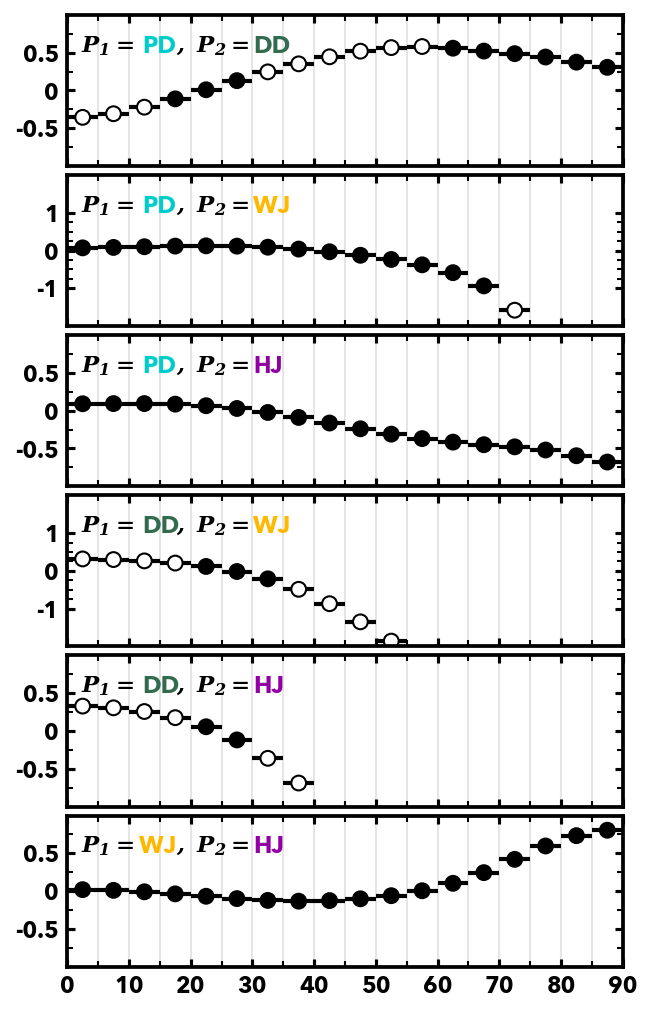

In [52]:
fig = plt.figure(figsize=(residual_stacked_plots_width, residual_stacked_plots_height*0.75), dpi=150)
axes = fig.subplot_mosaic(
    """
    a
    b
    c
    d
    e
    f
    """,
    gridspec_kw={'height_ratios': [1, 1, 1, 1, 1, 1], 'width_ratios': [1], "bottom": 0.05, "top": 0.99, "left": 0.152, "right": 0.975, "wspace": 0.10, "hspace": 0.06}
)

# axes['a'].xaxis.grid(True)
# axes['b'].xaxis.grid(True)
# axes['c'].xaxis.grid(True)
# axes['d'].xaxis.grid(True)
# axes['e'].xaxis.grid(True)
# axes['f'].xaxis.grid(True)

text_x_shift = 0
text_y_shift = 0.025
text_x_shift_label = -0.5
text_y_shift_label = 0.05

axes['a'].scatter(test_range_centers[0], sample_residual_averages[0], s=np.pi*4**2, color=sample_point_fill_colors[0], edgecolor='#000000', linestyle='None', zorder=-1)
axes['a'].errorbar(test_range_centers[0], sample_residual_averages[0], xerr=test_range_spans[0], elinewidth=2, ecolor='#000000', linestyle='None', zorder=-2)
axes['b'].scatter(test_range_centers[1], sample_residual_averages[1], s=np.pi*4**2, color=sample_point_fill_colors[1], edgecolor='#000000', linestyle='None', zorder=-1)
axes['b'].errorbar(test_range_centers[1], sample_residual_averages[1], xerr=test_range_spans[1], elinewidth=2, ecolor='#000000', linestyle='None', zorder=-2)
axes['c'].scatter(test_range_centers[2], sample_residual_averages[2], s=np.pi*4**2, color=sample_point_fill_colors[2], edgecolor='#000000', linestyle='None', zorder=-1)
axes['c'].errorbar(test_range_centers[2], sample_residual_averages[2], xerr=test_range_spans[2], elinewidth=2, ecolor='#000000', linestyle='None', zorder=-2)
axes['d'].scatter(test_range_centers[3], sample_residual_averages[3], s=np.pi*4**2, color=sample_point_fill_colors[3], edgecolor='#000000', linestyle='None', zorder=-1)
axes['d'].errorbar(test_range_centers[3], sample_residual_averages[3], xerr=test_range_spans[3], elinewidth=2, ecolor='#000000', linestyle='None', zorder=-2)
axes['e'].scatter(test_range_centers[4], sample_residual_averages[4], s=np.pi*4**2, color=sample_point_fill_colors[4], edgecolor='#000000', linestyle='None', zorder=-1)
axes['e'].errorbar(test_range_centers[4], sample_residual_averages[4], xerr=test_range_spans[4], elinewidth=2, ecolor='#000000', linestyle='None', zorder=-2)
axes['f'].scatter(test_range_centers[5], sample_residual_averages[5], s=np.pi*4**2, color=sample_point_fill_colors[5], edgecolor='#000000', linestyle='None', zorder=-1)
axes['f'].errorbar(test_range_centers[5], sample_residual_averages[5], xerr=test_range_spans[5], elinewidth=2, ecolor='#000000', linestyle='None', zorder=-2)


axes['c'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['c'].transAxes, color='#000000')
axes['c'].text(0.90*(13.5/90)+text_x_shift, 0.765+text_y_shift, r'PD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['c'].transAxes, color=pd_color)
axes['c'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['c'].transAxes, weight='heavy')
axes['c'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'HJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0., transform=axes['c'].transAxes, color=HJ_color)

axes['b'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['b'].transAxes, color='#000000')
axes['b'].text(0.90*(13.5/90)+text_x_shift, 0.765+text_y_shift, r'PD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['b'].transAxes, color=pd_color)
axes['b'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['b'].transAxes, weight='heavy')
axes['b'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'WJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['b'].transAxes, color=WJ_color)

axes['a'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['a'].transAxes, color='#000000')
axes['a'].text(0.90*(13.5/90)+text_x_shift, 0.765+text_y_shift, r'PD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['a'].transAxes, color=pd_color)
axes['a'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['a'].transAxes, weight='heavy')
axes['a'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'DD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['a'].transAxes, color=dd_color)

axes['d'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['d'].transAxes, color='#000000')
axes['d'].text(0.90*(13.5/90)+text_x_shift, 0.765+text_y_shift, r'DD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['d'].transAxes, color=dd_color)
axes['d'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['d'].transAxes, weight='heavy')
axes['d'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'WJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['d'].transAxes, color=WJ_color)

axes['e'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['e'].transAxes, color='#000000')
axes['e'].text(0.90*(13.5/90)+text_x_shift, 0.765+text_y_shift, r'DD', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['e'].transAxes, color=dd_color)
axes['e'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['e'].transAxes, weight='heavy')
axes['e'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'HJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['e'].transAxes, color=HJ_color)

axes['f'].text(0.90*(2.5/90)+text_x_shift, 0.77+text_y_shift, r'$P_1=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['f'].transAxes, color='#000000')
axes['f'].text(0.90*(13./90)+text_x_shift, 0.765+text_y_shift, r'WJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['f'].transAxes, color=WJ_color)
axes['f'].text(0.90*(19.5/90)+text_x_shift, 0.77+text_y_shift, r'$,~P_2=$', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size, transform=axes['f'].transAxes, weight='heavy')
axes['f'].text(0.90*(33.5/90)+text_x_shift, 0.765+text_y_shift, r'HJ', horizontalalignment='left', verticalalignment='center', fontsize=face_text_size+0.5, transform=axes['f'].transAxes, color=HJ_color)

a_ylim = [-1, 1]
b_ylim = [-2, 2]
c_ylim = [-1, 1]
d_ylim = [-2, 2]
e_ylim = [-1, 1]
f_ylim = [-1, 1]

axes['a'].vlines(x=np.arange(0, 90+range_width, range_width), ymin=a_ylim[0], ymax=a_ylim[1], color='#000000', lw=1, alpha=0.1, zorder=-10)
axes['b'].vlines(x=np.arange(0, 90+range_width, range_width), ymin=b_ylim[0], ymax=b_ylim[1], color='#000000', lw=1, alpha=0.1, zorder=-10)
axes['c'].vlines(x=np.arange(0, 90+range_width, range_width), ymin=c_ylim[0], ymax=c_ylim[1], color='#000000', lw=1, alpha=0.1, zorder=-10)
axes['d'].vlines(x=np.arange(0, 90+range_width, range_width), ymin=d_ylim[0], ymax=d_ylim[1], color='#000000', lw=1, alpha=0.1, zorder=-10)
axes['e'].vlines(x=np.arange(0, 90+range_width, range_width), ymin=e_ylim[0], ymax=e_ylim[1], color='#000000', lw=1, alpha=0.1, zorder=-10)
axes['f'].vlines(x=np.arange(0, 90+range_width, range_width), ymin=f_ylim[0], ymax=f_ylim[1], color='#000000', lw=1, alpha=0.1, zorder=-10)

xticks = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
xticklabels = [str(int(xtick)) for xtick in xticks]
axes['a'].set_xticks(xticks)
axes['a'].set_xticklabels([])
axes['b'].set_xticks(xticks)
axes['b'].set_xticklabels([])
axes['c'].set_xticks(xticks)
axes['c'].set_xticklabels([])
axes['d'].set_xticks(xticks)
axes['d'].set_xticklabels([])
axes['e'].set_xticks(xticks)
axes['e'].set_xticklabels([])
axes['f'].set_xticks(xticks)
axes['f'].set_xticklabels(xticklabels, fontsize=residual_stacked_plots_tick_fontsize, zorder=10)

yticks = [-0.5, 0, 0.5]
axes['a'].set_yticks(yticks)
axes['a'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)
yticks = [-1, 0, 1]
axes['b'].set_yticks(yticks)
axes['b'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)
yticks = [-0.5, 0, 0.5]
axes['c'].set_yticks(yticks)
axes['c'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)
yticks = [-1, 0, 1]
axes['d'].set_yticks(yticks)
axes['d'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)
yticks = [-0.5, 0, 0.5]
axes['e'].set_yticks(yticks)
axes['e'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)
yticks = [-0.5, 0, 0.5]
axes['f'].set_yticks(yticks)
axes['f'].set_yticklabels(yticks, fontsize=residual_stacked_plots_tick_fontsize)

axes['a'].set_xlim(0, 90)
axes['b'].set_xlim(0, 90)
axes['c'].set_xlim(0, 90)
axes['d'].set_xlim(0, 90)
axes['e'].set_xlim(0, 90)
axes['f'].set_xlim(0, 90)

axes['a'].set_ylim(a_ylim)
axes['b'].set_ylim(b_ylim)
axes['c'].set_ylim(c_ylim)
axes['d'].set_ylim(d_ylim)
axes['e'].set_ylim(e_ylim)
axes['f'].set_ylim(f_ylim)

yticks_minor = AutoMinorLocator(2) 
axes['a'].yaxis.set_minor_locator(yticks_minor)
axes['b'].yaxis.set_minor_locator(yticks_minor)
axes['c'].yaxis.set_minor_locator(yticks_minor)
axes['d'].yaxis.set_minor_locator(yticks_minor)
axes['e'].yaxis.set_minor_locator(yticks_minor)
axes['f'].yaxis.set_minor_locator(yticks_minor)

xticks_minor = AutoMinorLocator(2) 
axes['a'].xaxis.set_minor_locator(xticks_minor)
axes['b'].xaxis.set_minor_locator(xticks_minor)
axes['c'].xaxis.set_minor_locator(xticks_minor)
axes['d'].xaxis.set_minor_locator(xticks_minor)
axes['e'].xaxis.set_minor_locator(xticks_minor)
axes['f'].xaxis.set_minor_locator(xticks_minor)

axes['a'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
axes['a'].tick_params(axis='both', which='minor', length=3, width=1)
axes['b'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
axes['b'].tick_params(axis='both', which='minor', length=3, width=1)
axes['c'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
axes['c'].tick_params(axis='both', which='minor', length=3, width=1)
axes['d'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
axes['d'].tick_params(axis='both', which='minor', length=3, width=1)
axes['e'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
axes['e'].tick_params(axis='both', which='minor', length=3, width=1)
axes['f'].tick_params(axis='both', which='major', length=4, width=1.5, pad=4)
axes['f'].tick_params(axis='both', which='minor', length=3, width=1)



plt.show()

# Distributions Mosaic

20
['K2-139' 'K2-281' 'K2-329' 'K2-77' 'Kepler-1654' 'Kepler-27' 'Kepler-28'
 'Kepler-289' 'Kepler-30' 'Kepler-447' 'Kepler-468' 'Kepler-51'
 'Kepler-52' 'Kepler-539' 'Kepler-75' 'Kepler-9' 'TOI-1227' 'TOI-4562'
 'V1298 Tau' 'WASP-84']


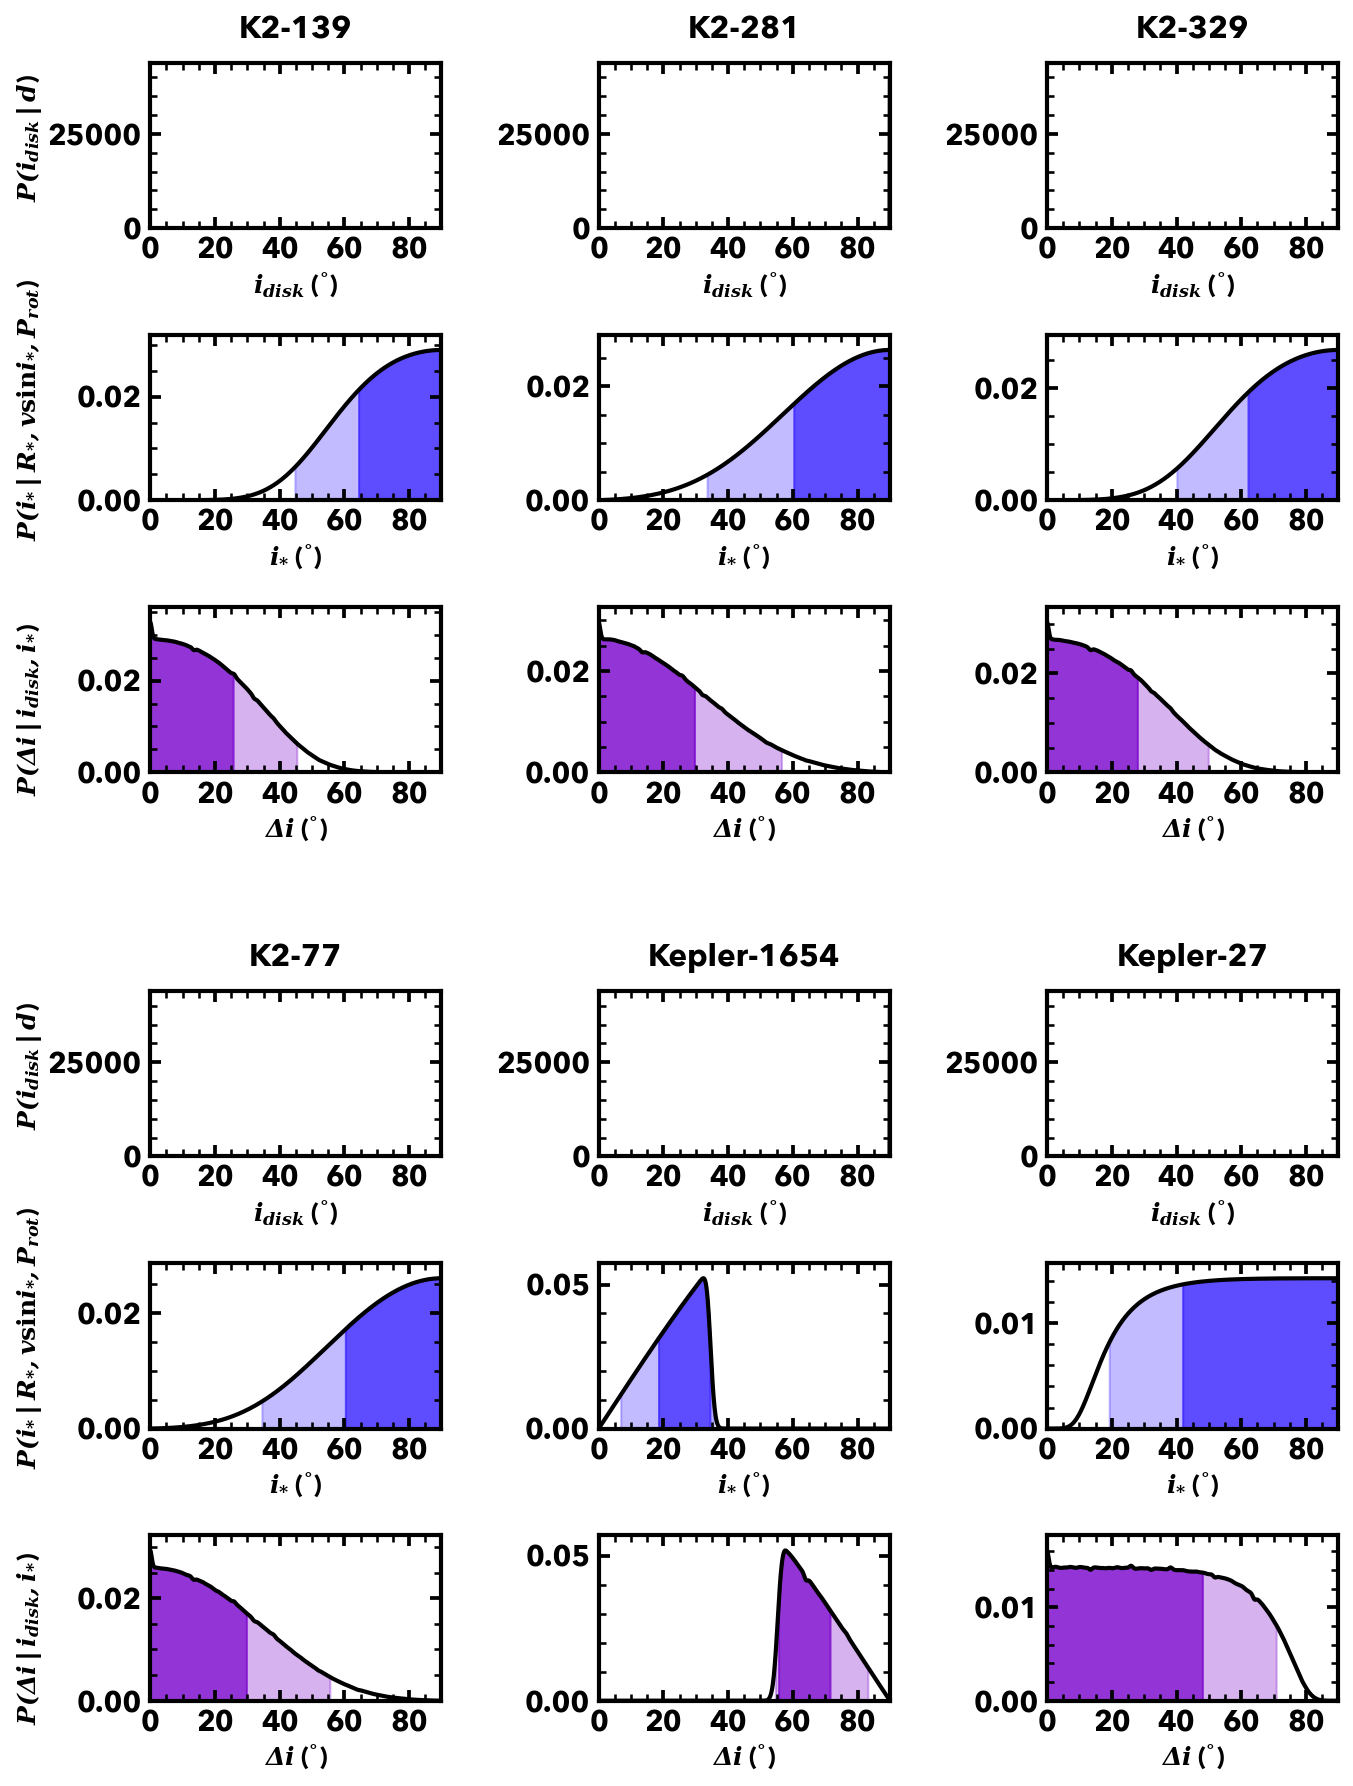

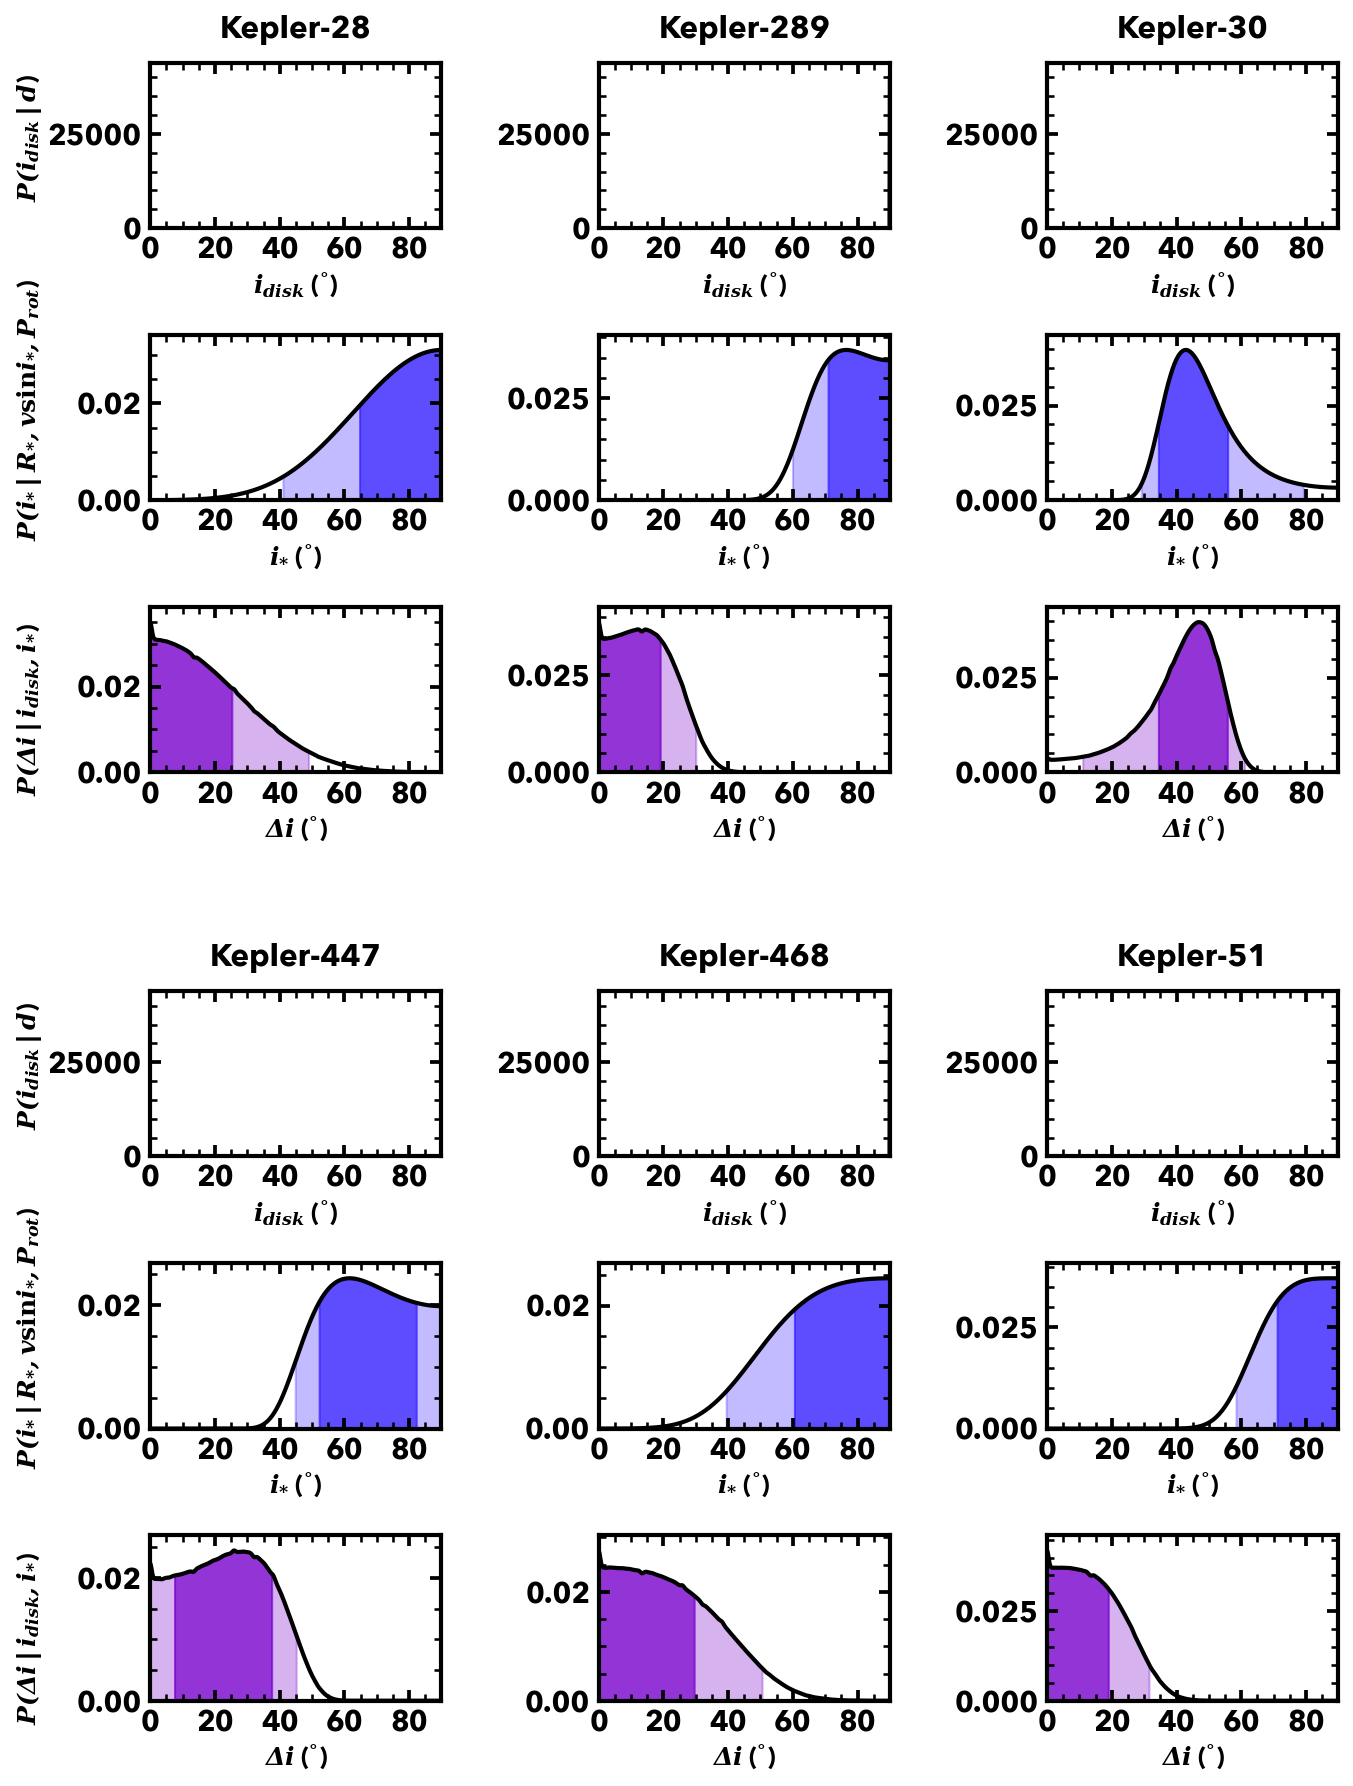

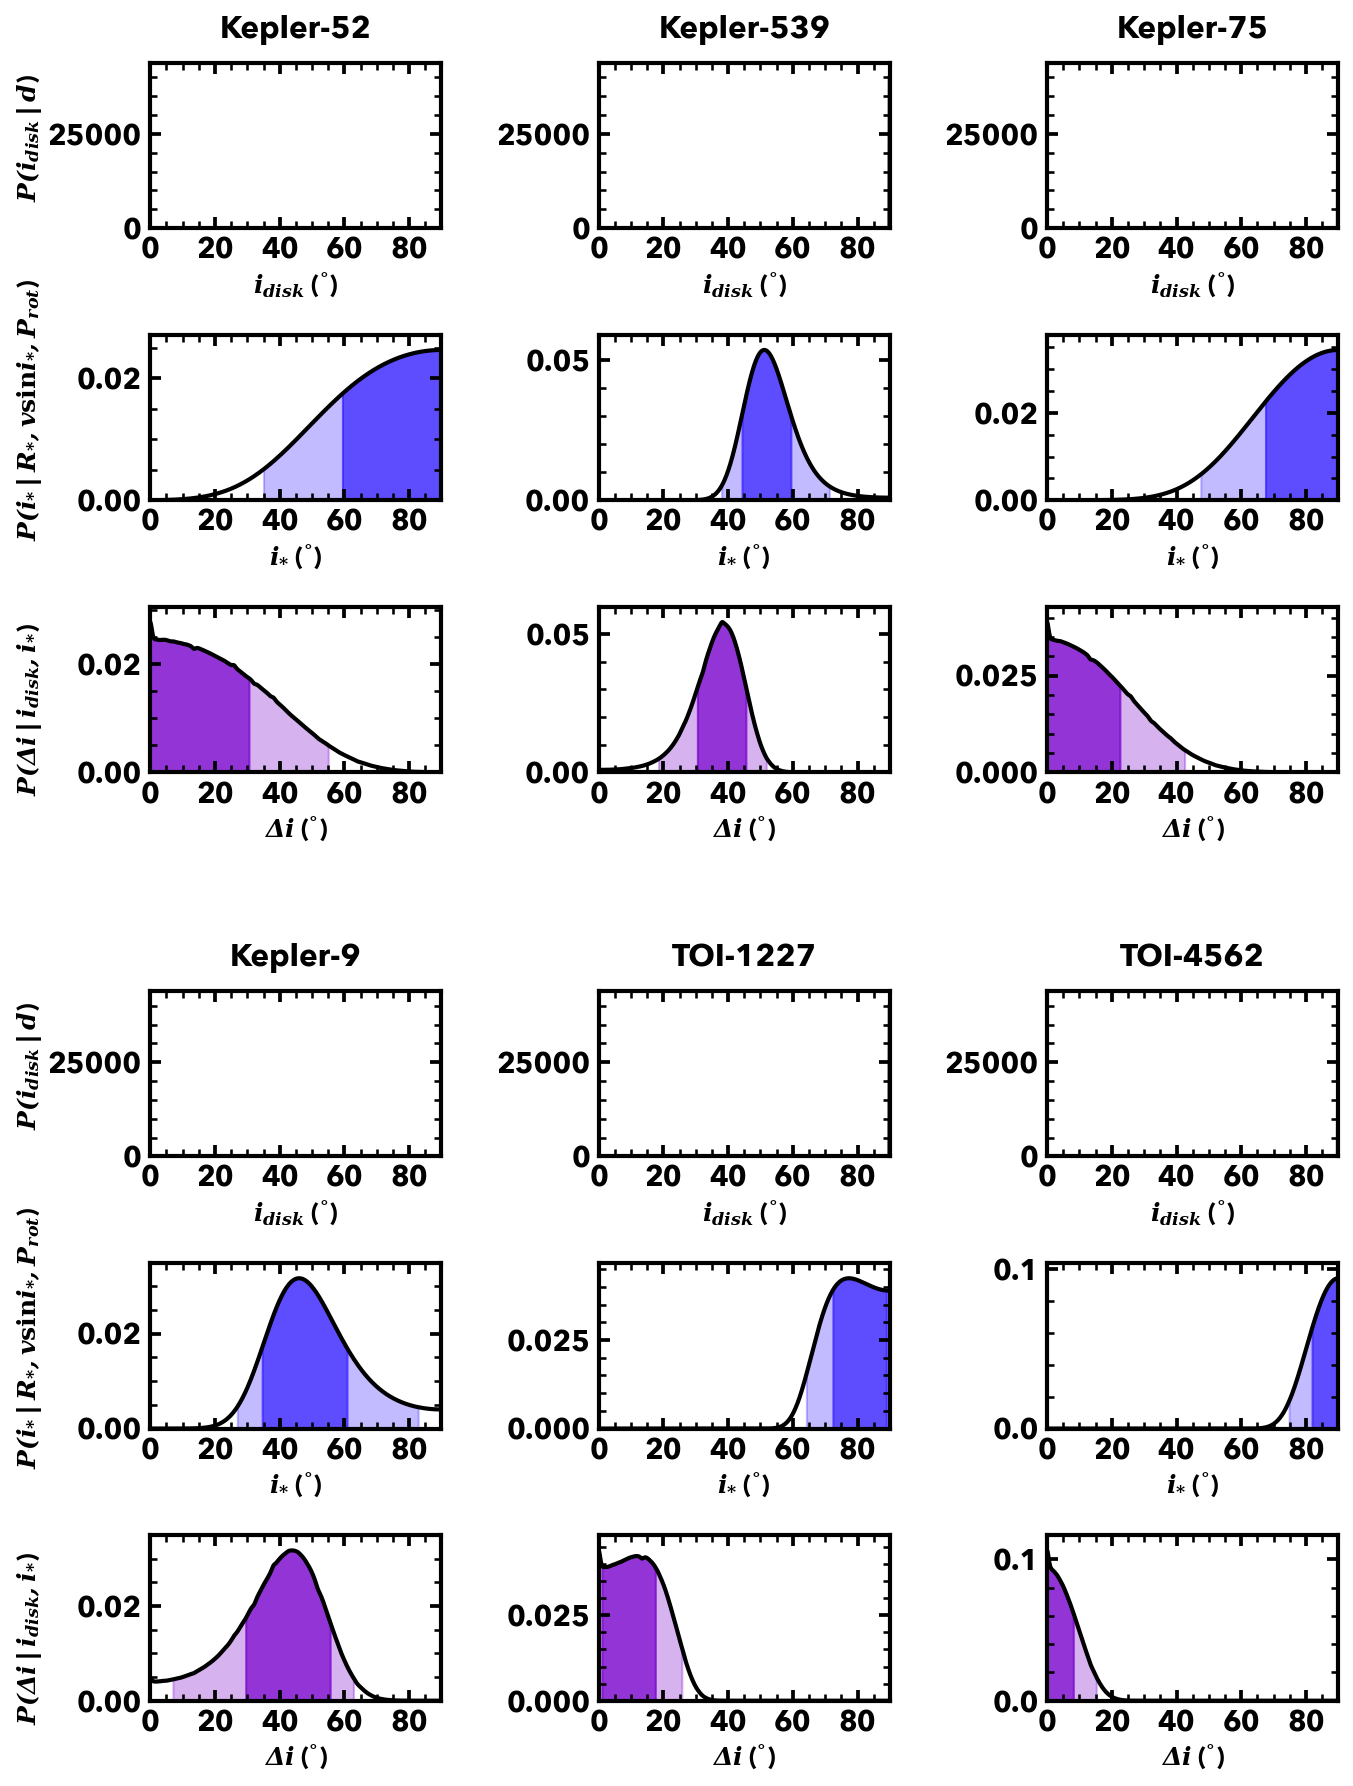

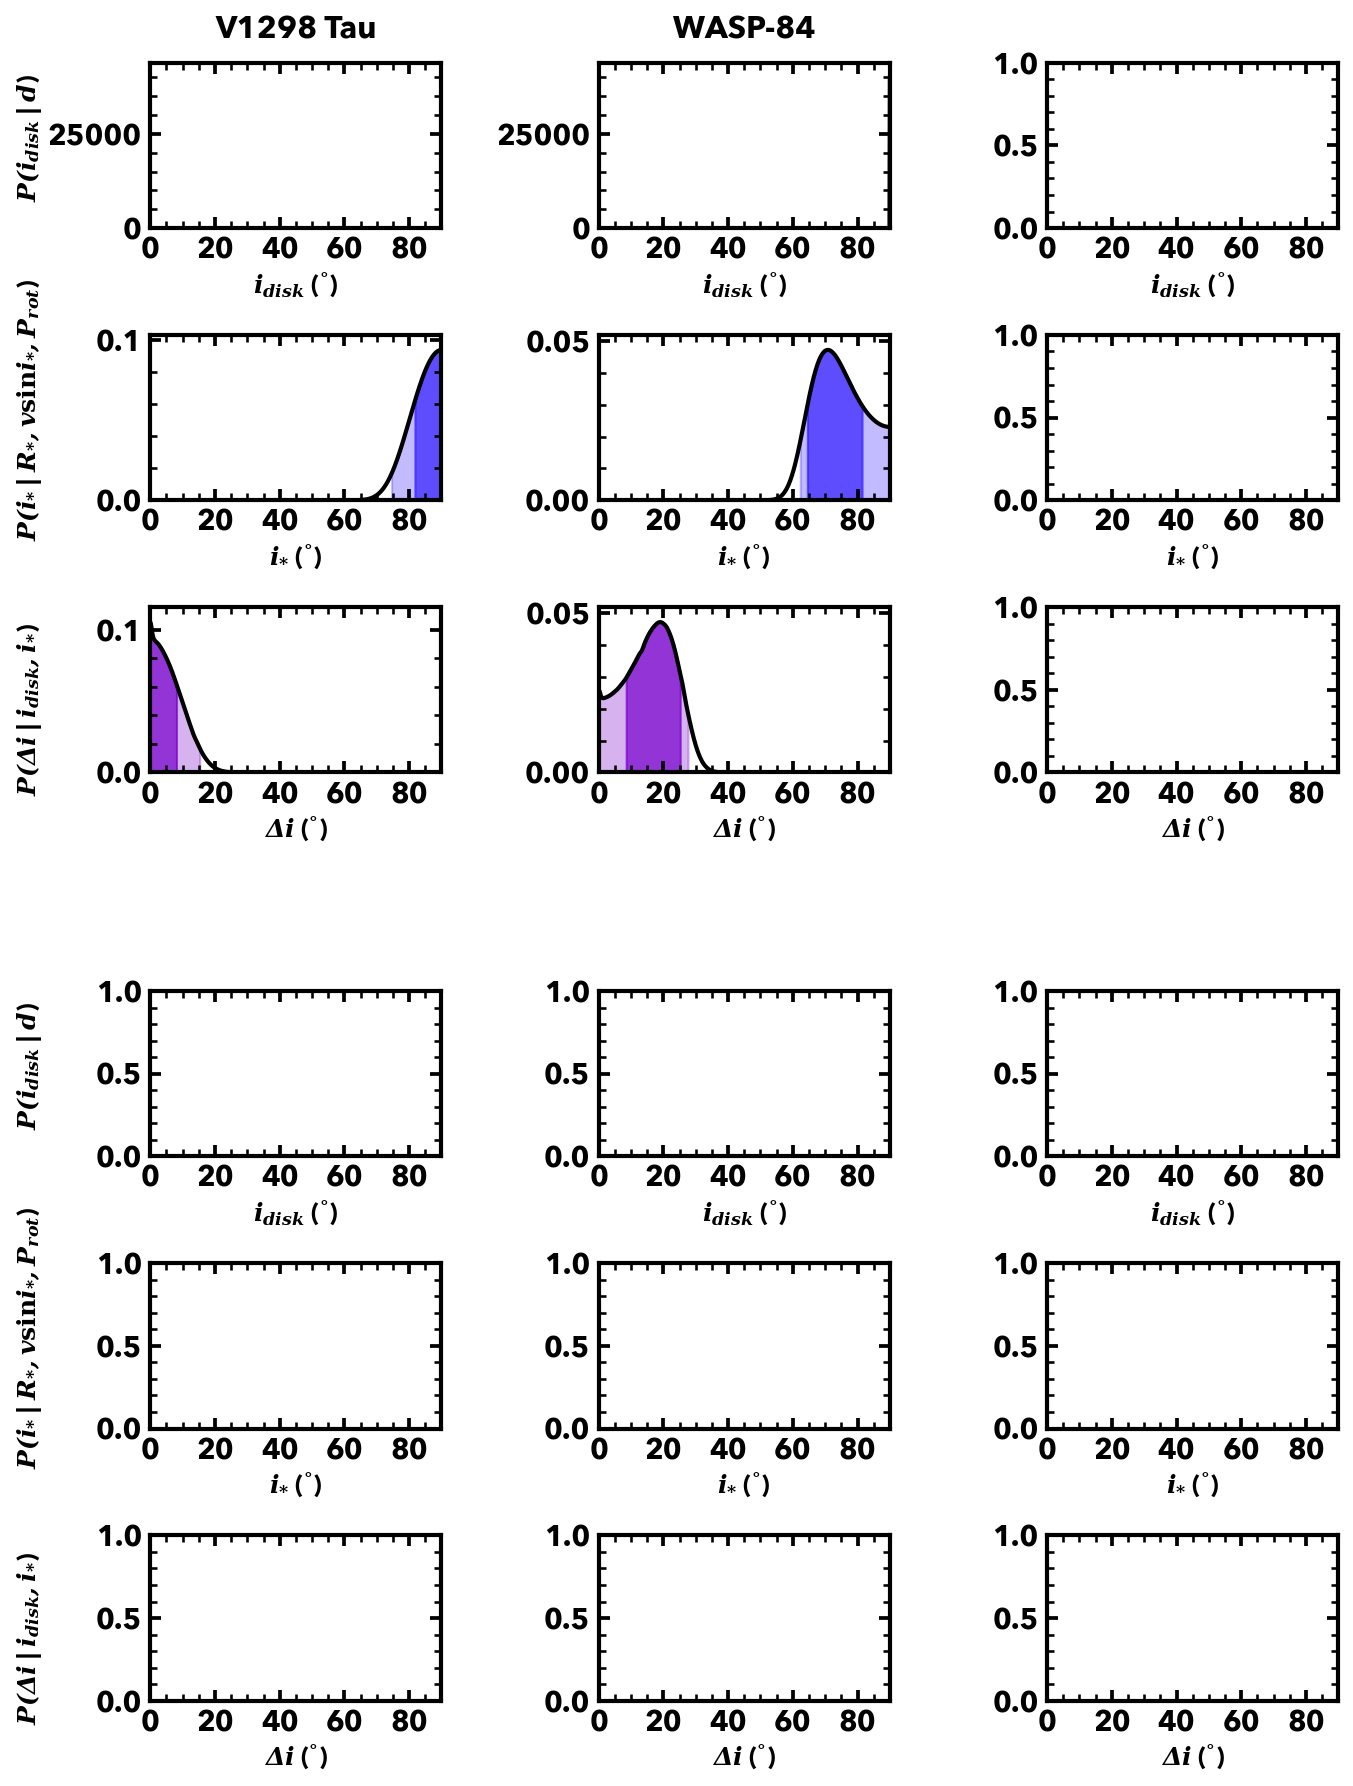

In [53]:

do_distributions_mosaic = True

# ----------------------------------------------
title_fontsize = 15 
label_fontsize = 12
tick_fontsize = 11
targetlabel_fontsize = 12

title_weight = 'semibold'

title_pad = 12  # 4
label_pad = 1.5  # 4

mosaic_datasets = ['WJ']

if do_distributions_mosaic == True:

    for which_dataset in mosaic_datasets:


        if which_dataset == 'PD':
            plot_df = df_PD
            which_list = 'PD'
            ccombonum = 1
        if which_dataset == 'DD':
            plot_df = df_DD
            which_list = 'DD'
            ccombonum = 2
        if which_dataset == 'WJ':
            plot_df = df_WJ
            which_list = 'WJ'
            ccombonum = 3
        if which_dataset == 'HJ':
            plot_df = df_HJ
            which_list = 'HJ'
            ccombonum = 4

        if ccombonum == 1:
            ccombo = ['#008fc7', '#6a3dff', '#9000a3'] 
        elif ccombonum == 2:
            ccombo = ['#ff6600', '#006666', '#739900']
        elif ccombonum == 3:
            ccombo = ['#004080', '#351fff', '#7800cc'] 
        elif ccombonum == 4:
            ccombo = ['#0000cc', '#00cc90', '#808080'] 
        i_disk_fill_color = ccombo[0]
        i_star_fill_color = ccombo[1]
        Delta_i_fill_color = ccombo[2]


        setnum = 0


        frame_numbers_on = False


        sig1_widths = []

        misaligned10_90percent_confidence = []
        misaligned10_80percent_confidence = []

        misaligned20_90percent_confidence = []
        misaligned20_80percent_confidence = []


        fig_height = 12
        fig_width = 9.0

        distribution_linewidths = 2

        target_list = plot_df['Target'].values
        print(len(target_list))
        print(target_list)

        target_sets = []
        set_len = 6
        trgt_i = 0
        while trgt_i < len(target_list):
            if trgt_i + set_len < len(target_list):
                target_set = target_list[trgt_i:trgt_i + set_len]
            else:
                target_set = target_list[trgt_i::]
            target_sets.append(target_set)
            trgt_i += 6

        # print(target_sets)

        set_col_axes = [['a', 'b', 'c'], ['d', 'e', 'f'], ['g', 'h', 'i'],
                        ['j', 'k', 'l'], ['m', 'n', 'o'], ['p', 'q', 'r']]

        for targ_set_i in range(len(target_sets)):
        # for targ_set_i in range(1):

            targ_set = np.array(target_sets[targ_set_i])

            targ_titles = []
            for set_element in targ_set:
                if isinstance(set_element, str):
                    if '(' in set_element:
                        set_element = set_element.split('(')[0]
                    if '2MASS' in set_element:
                        if '+' in set_element[5:]:
                            split1 = set_element[5:].split('+')[0].replace(' ', '')[0:5]
                            split2 = '+' + set_element[5:].split('+')[1].replace(' ', '')[0:4]
                        if '-' in set_element[5:]:
                            split1 = set_element[5:].split('-')[0].replace(' ', '')[0:5]
                            split2 = '-' + set_element[5:].split('-')[1].replace(' ', '')[0:4]
                        targ_titles.append('2M ' + split1 + split2)
                    else:
                        targ_titles.append(set_element)

                else:
                    continue

            fig = plt.figure(figsize=(fig_width, fig_height), dpi=150)
            axes = fig.subplot_mosaic(
                """
                adg
                beh
                cfi
                ...
                jmp
                knq
                lor
                """,
                gridspec_kw={'height_ratios': [1, 1, 1, 0.03, 1, 1, 1], 'width_ratios': [1, 1, 1], "bottom": 0.05, "top": 0.96, "left": 0.11, "right": 0.99, "wspace": 0.54, "hspace": 0.75,}
            )

            # blank_axes = []
            for ax in axes.keys():
                # if len(targ_set) == 5:
                #     blank_axes = ['p', 'q', 'r']
                # if len(targ_set) == 4:
                #     blank_axes = ['p', 'q', 'r', 'm', 'n', 'o']
                # if len(targ_set) == 2:
                #     blank_axes = ['p', 'q', 'r', 'm', 'n', 'o', 'j', 'k', 'l', 'g', 'h', 'i']
                # if len(targ_set) == 1:
                #     blank_axes = ['p', 'q', 'r', 'm', 'n', 'o', 'j', 'k', 'l', 'g', 'h', 'i', 'd', 'e', 'f']
                    
                # if ax not in blank_axes:
                axes[ax].minorticks_on()
                axes[ax].set_rasterized(True)

                for spine in axes[ax].spines.values():
                    spine.set_linewidth(2.0)

                # SPECIFY THE X TICKS
                xticks = [0, 20, 40, 60, 80]
                xticklabels = [str(int(xtick)) for xtick in xticks]
                axes[ax].set_xticks(xticks)
                axes[ax].set_xticklabels(xticklabels)
                axes[ax].set_xlim(0, 90)

            axes['a'].set_ylabel(r'$P(i_{disk}$ | $d$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['b'].set_ylabel(r'$P(i_{*}$ | $R_{*}, v\mathrm{sin}i_{*}, P_{rot}$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['c'].set_ylabel(r'$P(\Delta i$ | $i_{disk}, i_{*}$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['j'].set_ylabel(r'$P(i_{disk}$ | $d$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['k'].set_ylabel(r'$P(i_{*}$ | $R_{*}, v\mathrm{sin}i_{*}, P_{rot}$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['l'].set_ylabel(r'$P(\Delta i$ | $i_{disk}, i_{*}$)', fontsize=label_fontsize, labelpad=label_pad)

            axes['a'].yaxis.set_label_coords(-0.365, 0.55)
            axes['b'].yaxis.set_label_coords(-0.365, 0.55)
            axes['c'].yaxis.set_label_coords(-0.365, 0.38)
            axes['j'].yaxis.set_label_coords(-0.365, 0.55)
            axes['k'].yaxis.set_label_coords(-0.365, 0.55)
            axes['l'].yaxis.set_label_coords(-0.365, 0.38)

            axes['a'].set_xlabel(r'$i_{disk}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['d'].set_xlabel(r'$i_{disk}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['g'].set_xlabel(r'$i_{disk}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['j'].set_xlabel(r'$i_{disk}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['m'].set_xlabel(r'$i_{disk}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['p'].set_xlabel(r'$i_{disk}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)

            axes['b'].set_xlabel(r'$i_{*}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['e'].set_xlabel(r'$i_{*}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['h'].set_xlabel(r'$i_{*}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['k'].set_xlabel(r'$i_{*}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['n'].set_xlabel(r'$i_{*}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['q'].set_xlabel(r'$i_{*}$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)

            axes['c'].set_xlabel(r'$\Delta i$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['f'].set_xlabel(r'$\Delta i$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['i'].set_xlabel(r'$\Delta i$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['l'].set_xlabel(r'$\Delta i$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['o'].set_xlabel(r'$\Delta i$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)
            axes['r'].set_xlabel(r'$\Delta i$ ($^\degree$)', fontsize=label_fontsize, labelpad=label_pad)


            if len(targ_titles) == 6:
                axes['a'].set_title(targ_titles[0], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['d'].set_title(targ_titles[1], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['g'].set_title(targ_titles[2], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['j'].set_title(targ_titles[3], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['m'].set_title(targ_titles[4], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['p'].set_title(targ_titles[5], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
            elif len(targ_titles) == 5:
                axes['a'].set_title(targ_titles[0], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['d'].set_title(targ_titles[1], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['g'].set_title(targ_titles[2], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['j'].set_title(targ_titles[3], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['m'].set_title(targ_titles[4], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
            elif len(targ_titles) == 4:
                axes['a'].set_title(targ_titles[0], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['d'].set_title(targ_titles[1], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['g'].set_title(targ_titles[2], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['j'].set_title(targ_titles[3], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
            elif len(targ_titles) == 3:
                axes['a'].set_title(targ_titles[0], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['d'].set_title(targ_titles[1], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['g'].set_title(targ_titles[2], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
            elif len(targ_titles) == 2:
                axes['a'].set_title(targ_titles[0], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
                axes['d'].set_title(targ_titles[1], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)
            elif len(targ_titles) == 1:
                axes['a'].set_title(targ_titles[0], fontsize=title_fontsize, pad=title_pad, fontweight=title_weight)




            for set_element_i in range(len(targ_set)):

                simbad_name = targ_set[set_element_i]

                if isinstance(simbad_name, str) == False:
                    continue
                target_str = targ_set[set_element_i].replace(' ', '')
                if '/' in targ_set[set_element_i]:
                    target_str = target_str.replace('/', '-')
                if '(' in target_str:
                    target_str = target_str.split('(')[0]
                
                if which_list == 'PD':
                    Pdensity = pd.read_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Tables/Probability_Distributions/High_Final/' + 'Prob_' + target_str + '.csv')
                else:
                    if which_list == 'DD':
                        Pdensity = pd.read_csv(probability_distributions_dir + 'Prob_' + target_str + '.csv')
                    else:
                        Pdensity = pd.read_csv(probability_distributions_dir + 'Posteriors_' + target_str + '_' + which_list + '.csv')
                i_values = Pdensity['i (deg)'].values

                P_i_disk = Pdensity['P(i Disk | d)'].values
                MAP_i_disk = Pdensity['i Disk MAP'].values[0]
                sig1_m_i_disk = Pdensity['i Disk -Unc1'].values[0]
                sig1_p_i_disk = Pdensity['i Disk +Unc1'].values[0]
                sig2_m_i_disk = Pdensity['i Disk -Unc2'].values[0]
                sig2_p_i_disk = Pdensity['i Disk +Unc2'].values[0]

                P_i_star = Pdensity['P(i Star | d)'].values
                MAP_i_star = Pdensity['i Star MAP'].values[0]
                sig1_m_i_star = Pdensity['i Star -Unc1'].values[0]
                sig1_p_i_star = Pdensity['i Star +Unc1'].values[0]
                sig2_m_i_star = Pdensity['i Star -Unc2'].values[0]
                sig2_p_i_star = Pdensity['i Star +Unc2'].values[0]

                P_Delta_i = Pdensity['P(Delta i | d)'].values
                MAP_Delta_i = Pdensity['Delta i MAP'].values[0]
                sig1_m_Delta_i = Pdensity['Delta i -Unc1'].values[0]
                sig1_p_Delta_i = Pdensity['Delta i +Unc1'].values[0]
                sig2_m_Delta_i = Pdensity['Delta i -Unc2'].values[0]
                sig2_p_Delta_i = Pdensity['Delta i +Unc2'].values[0]


                set_col_ax = set_col_axes[set_element_i]

                alpha_sig2 = 0.25
                alpha_sig1 = 1 - alpha_sig2

                axes[set_col_ax[0]].plot(i_values, P_i_disk, color='#000000', lw=distribution_linewidths, zorder=4)
                where_sig1 = np.where((i_values >= MAP_i_disk - sig1_m_i_disk) & (i_values <= MAP_i_disk + sig1_p_i_disk))[0]
                where_sig2 = np.where((i_values >= MAP_i_disk - sig2_m_i_disk) & (i_values <= MAP_i_disk + sig2_p_i_disk))[0]
                axes[set_col_ax[0]].fill_between(x=i_values[where_sig1], y1=P_i_disk[where_sig1], color=i_disk_fill_color, alpha=alpha_sig1, zorder=-1)
                axes[set_col_ax[0]].fill_between(x=i_values[where_sig2], y1=P_i_disk[where_sig2], color=i_disk_fill_color, alpha=alpha_sig2, zorder=-1)
                axes[set_col_ax[0]].set_ylim(0, 1.10*max(P_i_disk))

                alpha_sig2 = 0.3
                alpha_sig1 = 1 - alpha_sig2

                axes[set_col_ax[1]].plot(i_values, P_i_star, color='#000000', lw=distribution_linewidths, zorder=4)
                where_sig1 = np.where((i_values >= MAP_i_star - sig1_m_i_star) & (i_values <= MAP_i_star + sig1_p_i_star))[0]
                where_sig2 = np.where((i_values >= MAP_i_star - sig2_m_i_star) & (i_values <= MAP_i_star + sig2_p_i_star))[0]
                axes[set_col_ax[1]].fill_between(x=i_values[where_sig1], y1=P_i_star[where_sig1], color=i_star_fill_color, alpha=alpha_sig1, zorder=-1)
                axes[set_col_ax[1]].fill_between(x=i_values[where_sig2], y1=P_i_star[where_sig2], color=i_star_fill_color, alpha=alpha_sig2, zorder=-1)
                axes[set_col_ax[1]].set_ylim(0, 1.10*max(P_i_star))

                alpha_sig2 = 0.3
                alpha_sig1 = 1 - alpha_sig2

                axes[set_col_ax[2]].plot(i_values, P_Delta_i, color='#000000', lw=distribution_linewidths, zorder=4)
                where_sig1 = np.where((i_values >= MAP_Delta_i - sig1_m_Delta_i) & (i_values <= MAP_Delta_i + sig1_p_Delta_i))[0]
                where_sig2 = np.where((i_values >= MAP_Delta_i - sig2_m_Delta_i) & (i_values <= MAP_Delta_i + sig2_p_Delta_i))[0]
                i_MAP = i_values[P_Delta_i == max(P_Delta_i)]
                axes[set_col_ax[2]].fill_between(x=i_values[where_sig1], y1=P_Delta_i[where_sig1], color=Delta_i_fill_color, alpha=alpha_sig1, zorder=-1)
                axes[set_col_ax[2]].fill_between(x=i_values[where_sig2], y1=P_Delta_i[where_sig2], color=Delta_i_fill_color, alpha=alpha_sig2, zorder=-1)
                axes[set_col_ax[2]].set_ylim(0, 1.10*max(P_Delta_i))

            fig.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/' + 'Distributions_' + which_list + '_' + str(targ_set_i+1) + '.pdf', dpi=300, transparent=False)
            plt.show()
            plt.close()


In [54]:
def determine_misalignment(param_x, pdf_y, MAP, threshold, confidence_requirement, lower_sigma):

    # if MAP >= threshold:

    param_x_fine = np.linspace(min(param_x), max(param_x), 10000)
    pdf_y_fine = np.interp(x=param_x_fine, xp=param_x, fp=pdf_y)

    param_x_above = param_x_fine[param_x_fine >= threshold]
    pdf_y_above = pdf_y_fine[param_x_fine >= threshold]

    area_above_threshold = np.trapezoid(y=pdf_y_above, x=param_x_above, dx=np.diff(param_x_above)[0])

    if area_above_threshold >= confidence_requirement:
        return True
    else:
        return False
    # else:
    #     return False



In [55]:
df_PD, df_DD, df_WJ, df_HJ = read_datafiles()

OPENING FILES...
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_PD_2025-Oct-24.csv
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_DD_2025-Oct-24.csv
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_WJ_2025-Oct-24.csv
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_HJ_2025-Oct-24.csv


In [56]:
# Identify misaligned systems and construct dictionaries

datasets = ['PD', 'DD', 'WJ', 'HJ']

mean_Deltai_err_PD = (df_PD['disk diff +Unc'].values + df_PD['disk diff -Unc'].values) / 2.
mean_Deltai_err_DD = (df_DD['disk diff +Unc'].values + df_DD['disk diff -Unc'].values) / 2.
mean_Deltai_err_WJ = (df_WJ['disk diff +Unc'].values + df_WJ['disk diff -Unc'].values) / 2.
mean_Deltai_err_HJ = (df_HJ['disk diff +Unc'].values + df_HJ['disk diff -Unc'].values) / 2.

print(np.mean(mean_Deltai_err_PD))
print(np.mean(mean_Deltai_err_DD))
print(np.mean(mean_Deltai_err_WJ))
print(np.mean(mean_Deltai_err_HJ))

lower_thres = [np.round(np.mean(mean_Deltai_err_PD)), np.round(np.mean(mean_Deltai_err_DD)), np.round(np.mean(mean_Deltai_err_WJ)), np.round(np.mean(mean_Deltai_err_HJ))]
# lower_thres = [mis_thres, mis_thres, mis_thres, mis_thres]

# misalignment_thresholds = [10, 20, 40]
misalignment_thresholds = [10, 25, 40, 55]

misaligned_lists = {}
misaligned_lists_multis = {}
misaligned_lists_singles = {}

misaligned_lists_global_threshold = {}
misaligned_lists_multis_global_threshold = {}
misaligned_lists_singles_global_threshold = {}

MAP_gt_10 = {}
MAP_gt_15 = {}
MAP_gt_20 = {}

MAP_gt_10_2sig = {}
MAP_gt_15_2sig = {}
MAP_gt_20_2sig = {}


for which_dataset in datasets:

    if which_dataset == 'PD':
        test_df = df_PD
        multis_list = PD_multis
        singles_list = PD_singles
        only_multis = only_multis_PD
        only_singles = only_singles_PD
    if which_dataset == 'DD':
        test_df = df_DD
        multis_list = DD_multis
        singles_list = DD_singles
        only_multis = only_multis_DD
        only_singles = only_singles_DD
    if which_dataset == 'WJ':
        test_df = df_WJ
        multis_list = WJ_multis
        singles_list = WJ_singles
        only_multis = only_multis_WJ
        only_singles = only_singles_WJ
    if which_dataset == 'HJ':
        test_df = df_HJ
        multis_list = HJ_multis
        singles_list = HJ_singles
        only_multis = only_multis_HJ
        only_singles = only_singles_HJ

    if only_multis == True:
        only_singles = False

    sample_size = len(test_df['Target'].values)

    list_of_targets = []
    list_of_posteriors = []
    list_of_MAPS = []

    misaligned_all = []
    misaligned_all_multis = []
    misaligned_all_singles = []

    misaligned_threshold_lists = {}
    misaligned_threshold_lists_multis = {}
    misaligned_threshold_lists_singles = {}

    for threshold_i in misalignment_thresholds:
        misaligned_threshold_lists['{:d} deg'.format(threshold_i)] = []
        misaligned_threshold_lists_multis['{:d} deg'.format(threshold_i)] = []
        misaligned_threshold_lists_singles['{:d} deg'.format(threshold_i)] = []

        misaligned_threshold_lists['{:d} deg'.format(threshold_i) + ' MAP'] = []
        misaligned_threshold_lists_multis['{:d} deg'.format(threshold_i) + ' MAP'] = []
        misaligned_threshold_lists_singles['{:d} deg'.format(threshold_i) + ' MAP'] = []

    misaligned_Delta_i_MAP_all = []
    misaligned_Delta_i_sig1_all = []

    print('COMPUTING MISALIGNMENTS BASED ON INDIVIDUAL PRECISON...')
    for target_i in range(sample_size):

        if only_multis == True:
            if test_df['Target'].values[target_i] not in multis_list:
                continue
        if only_singles == True:
            if test_df['Target'].values[target_i] not in singles_list:
                continue

        target_str = test_df['Target'].values[target_i].replace(' ', '')
        if '/' in test_df['Target'].values[target_i]:
            target_str = target_str.replace('/', '-')
        if '(' in target_str:
                target_str = target_str.split('(')[0]
            
        if which_dataset == 'PD':
            Pdensity = pd.read_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Tables/Probability_Distributions/High_Final/' + 'Prob_' + target_str + '.csv')
        else:
            if which_dataset == 'DD':
                Pdensity = pd.read_csv('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Probability_Distributions/'  + 'Prob_' + target_str + '.csv')
            else:
                Pdensity = pd.read_csv(probability_distributions_dir + 'Posteriors_' + target_str + '_' + which_dataset + '.csv')
        
        if which_dataset == 'PD':
            i_values_PD = Pdensity['i (deg)'].values

        i_values = Pdensity['i (deg)'].values
        P_Delta_i = Pdensity['P(Delta i | d)'].values
        MAP_Delta_i = Pdensity['Delta i MAP'].values[0]
        sig1_m_Delta_i = Pdensity['Delta i -Unc1'].values[0]
        sig1_p_Delta_i = Pdensity['Delta i +Unc1'].values[0]
        sig2_m_Delta_i = Pdensity['Delta i -Unc2'].values[0]
        sig2_p_Delta_i = Pdensity['Delta i +Unc2'].values[0]

        mean_sig1 = (sig1_m_Delta_i + sig1_p_Delta_i) / 2.
        
        
        P_Delta_i = P_Delta_i/(sum(P_Delta_i)*np.diff(i_values)[0])

        if MAP_Delta_i > 2*np.diff(i_values)[0]:

            if MAP_Delta_i/sig1_m_Delta_i >= 2.0:

                misaligned_all.append(target_str)
                misaligned_Delta_i_MAP_all.append(float(MAP_Delta_i))
                misaligned_Delta_i_sig1_all.append(float(mean_sig1))

                if test_df['Target'].values[target_i] in multis_list:
                    misaligned_all_multis.append(target_str)
                if test_df['Target'].values[target_i] in singles_list:
                    misaligned_all_singles.append(target_str)

                for threshold_i in misalignment_thresholds:
                    if MAP_Delta_i >= threshold_i:
                        misaligned_threshold_lists['{:d} deg'.format(threshold_i)].append(target_str)
                        misaligned_threshold_lists['{:d} deg'.format(threshold_i) + ' MAP'].append(float(MAP_Delta_i))
                        if test_df['Target'].values[target_i] in multis_list:
                            misaligned_threshold_lists_multis['{:d} deg'.format(threshold_i)].append(target_str)
                            misaligned_threshold_lists_multis['{:d} deg'.format(threshold_i) + ' MAP'].append(float(MAP_Delta_i))
                        if test_df['Target'].values[target_i] in singles_list:
                            misaligned_threshold_lists_singles['{:d} deg'.format(threshold_i)].append(target_str)
                            misaligned_threshold_lists_singles['{:d} deg'.format(threshold_i) + ' MAP'].append(float(MAP_Delta_i))

    misaligned_list = {}
    misaligned_list['ALL'] = misaligned_all
    misaligned_list['ALL MAP'] = misaligned_Delta_i_MAP_all
    misaligned_list['ALL SIG1'] = misaligned_Delta_i_sig1_all

    misaligned_list_multis = {}
    misaligned_list_multis['ALL'] = misaligned_all
    misaligned_list_multis['ALL MAP'] = misaligned_Delta_i_MAP_all
    misaligned_list_multis['ALL SIG1'] = misaligned_Delta_i_sig1_all

    misaligned_list_singles = {}
    misaligned_list_singles['ALL'] = misaligned_all
    misaligned_list_singles['ALL MAP'] = misaligned_Delta_i_MAP_all
    misaligned_list_singles['ALL SIG1'] = misaligned_Delta_i_sig1_all


    for threshold_i in misalignment_thresholds:
        misaligned_list['{:d} deg'.format(threshold_i)] = misaligned_threshold_lists['{:d} deg'.format(threshold_i)]
        misaligned_list['{:d} deg MAP'.format(threshold_i)] = misaligned_threshold_lists['{:d} deg'.format(threshold_i) + ' MAP']

        misaligned_list_multis['{:d} deg'.format(threshold_i)] = misaligned_threshold_lists_multis['{:d} deg'.format(threshold_i)]
        misaligned_list_multis['{:d} deg MAP'.format(threshold_i)] = misaligned_threshold_lists_multis['{:d} deg'.format(threshold_i) + ' MAP']

        misaligned_list_singles['{:d} deg'.format(threshold_i)] = misaligned_threshold_lists_singles['{:d} deg'.format(threshold_i)]
        misaligned_list_singles['{:d} deg MAP'.format(threshold_i)] = misaligned_threshold_lists_singles['{:d} deg'.format(threshold_i) + ' MAP']


    
    misaligned_lists[which_dataset] = misaligned_list
    misaligned_lists_multis[which_dataset] = misaligned_list_multis
    misaligned_lists_singles[which_dataset] = misaligned_list_singles

    #------------------------------------------------------------------------
    #-------------------- GLOBAL THRESHOLD ----------------------------------
    #------------------------------------------------------------------------

    confidence_requirement = 0.90

    list_of_targets = []
    list_of_posteriors = []
    list_of_MAPS = []

    misaligned_threshold_lists = {}
    misaligned_threshold_lists_multis = {}
    misaligned_threshold_lists_singles = {}

    for threshold_i in misalignment_thresholds:
        misaligned_threshold_lists['{:d} deg'.format(threshold_i)] = []
        misaligned_threshold_lists_multis['{:d} deg'.format(threshold_i)] = []
        misaligned_threshold_lists_singles['{:d} deg'.format(threshold_i)] = []

        misaligned_threshold_lists['{:d} deg'.format(threshold_i) + ' MAP'] = []
        misaligned_threshold_lists_multis['{:d} deg'.format(threshold_i) + ' MAP'] = []
        misaligned_threshold_lists_singles['{:d} deg'.format(threshold_i) + ' MAP'] = []

    misaligned_Delta_i_MAP_all = []
    misaligned_Delta_i_sig1_all = []

    print('COMPUTING MISALIGNMENTS BASED ON A GLOBAL THRESHOLD...')

    for target_i in range(sample_size):

        if only_multis == True:
            if test_df['Target'].values[target_i] not in multis_list:
                continue
        if only_singles == True:
            if test_df['Target'].values[target_i] not in singles_list:
                continue

        target_str = test_df['Target'].values[target_i].replace(' ', '')
        if '/' in test_df['Target'].values[target_i]:
            target_str = target_str.replace('/', '-')
        if '(' in target_str:
                target_str = target_str.split('(')[0]
            
        if which_dataset == 'PD':
            Pdensity = pd.read_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Tables/Probability_Distributions/High_Final/' + 'Prob_' + target_str + '.csv')
        else:
            if which_dataset == 'DD':
                Pdensity = pd.read_csv('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Probability_Distributions/'  + 'Prob_' + target_str + '.csv')
            else:
                Pdensity = pd.read_csv(probability_distributions_dir + 'Posteriors_' + target_str + '_' + which_dataset + '.csv')
        
        if which_dataset == 'PD':
            i_values_PD = Pdensity['i (deg)'].values

        i_values = Pdensity['i (deg)'].values
        P_Delta_i = Pdensity['P(Delta i | d)'].values
        MAP_Delta_i = Pdensity['Delta i MAP'].values[0]
        sig1_m_Delta_i = Pdensity['Delta i -Unc1'].values[0]
        sig1_p_Delta_i = Pdensity['Delta i +Unc1'].values[0]
        sig2_m_Delta_i = Pdensity['Delta i -Unc2'].values[0]
        sig2_p_Delta_i = Pdensity['Delta i +Unc2'].values[0]
        
        P_Delta_i = P_Delta_i/(sum(P_Delta_i)*np.diff(i_values)[0])

        for threshold_i in misalignment_thresholds:
            confidence_level_i = determine_misalignment(param_x=i_values, pdf_y=P_Delta_i, MAP=MAP_Delta_i, threshold=threshold_i, confidence_requirement=confidence_requirement, lower_sigma=sig1_m_Delta_i)

            if confidence_level_i == True:

                misaligned_threshold_lists['{:d} deg'.format(threshold_i)].append(target_str)
                misaligned_threshold_lists['{:d} deg'.format(threshold_i) + ' MAP'].append(float(MAP_Delta_i))
                if test_df['Target'].values[target_i] in multis_list:
                    misaligned_threshold_lists_multis['{:d} deg'.format(threshold_i)].append(target_str)
                    misaligned_threshold_lists_multis['{:d} deg'.format(threshold_i) + ' MAP'].append(float(MAP_Delta_i))
                if test_df['Target'].values[target_i] in singles_list:
                    misaligned_threshold_lists_singles['{:d} deg'.format(threshold_i)].append(target_str)
                    misaligned_threshold_lists_singles['{:d} deg'.format(threshold_i) + ' MAP'].append(float(MAP_Delta_i))


    misaligned_list = {}
    for threshold_i in misalignment_thresholds:
        misaligned_list['{:d} deg'.format(threshold_i)] = misaligned_threshold_lists['{:d} deg'.format(threshold_i)]
        misaligned_list['{:d} deg MAP'.format(threshold_i)] = misaligned_threshold_lists['{:d} deg'.format(threshold_i) + ' MAP']

    misaligned_list_multis = {}
    for threshold_i in misalignment_thresholds:
        misaligned_list_multis['{:d} deg'.format(threshold_i)] = misaligned_threshold_lists_multis['{:d} deg'.format(threshold_i)]
        misaligned_list_multis['{:d} deg MAP'.format(threshold_i)] = misaligned_threshold_lists_multis['{:d} deg'.format(threshold_i) + ' MAP']

    misaligned_list_singles = {}
    for threshold_i in misalignment_thresholds:
        misaligned_list_singles['{:d} deg'.format(threshold_i)] = misaligned_threshold_lists_singles['{:d} deg'.format(threshold_i)]
        misaligned_list_singles['{:d} deg MAP'.format(threshold_i)] = misaligned_threshold_lists_singles['{:d} deg'.format(threshold_i) + ' MAP']
    
    misaligned_lists_global_threshold[which_dataset] = misaligned_list
    misaligned_lists_multis_global_threshold[which_dataset] = misaligned_list_multis
    misaligned_lists_singles_global_threshold[which_dataset] = misaligned_list_singles
    

9.646476067520407
7.572063958826088
11.667851227424999
12.422191297800001
COMPUTING MISALIGNMENTS BASED ON INDIVIDUAL PRECISON...
COMPUTING MISALIGNMENTS BASED ON A GLOBAL THRESHOLD...
COMPUTING MISALIGNMENTS BASED ON INDIVIDUAL PRECISON...
COMPUTING MISALIGNMENTS BASED ON A GLOBAL THRESHOLD...
COMPUTING MISALIGNMENTS BASED ON INDIVIDUAL PRECISON...
COMPUTING MISALIGNMENTS BASED ON A GLOBAL THRESHOLD...
COMPUTING MISALIGNMENTS BASED ON INDIVIDUAL PRECISON...
COMPUTING MISALIGNMENTS BASED ON A GLOBAL THRESHOLD...


In [57]:
# Report misalignment fractions and average misalignments for each dataset based on individual precisions

for which_dataset in datasets:

    print(' ')
    print('--------------------------------- ' + which_dataset + ' ---------------------------------')

    if which_dataset == 'PD':
        test_df = df_PD
        multis_list = PD_multis
        singles_list = PD_singles
        only_multis = only_multis_PD
        only_singles = only_singles_PD
    if which_dataset == 'DD':
        test_df = df_DD
        multis_list = DD_multis
        singles_list = DD_singles
        only_multis = only_multis_DD
        only_singles = only_singles_DD
    if which_dataset == 'WJ':
        test_df = df_WJ
        multis_list = WJ_multis
        singles_list = WJ_singles
        only_multis = only_multis_WJ
        only_singles = only_singles_WJ
    if which_dataset == 'HJ':
        test_df = df_HJ
        multis_list = HJ_multis
        singles_list = HJ_singles
        only_multis = only_multis_HJ
        only_singles = only_singles_HJ

    sample_size = len(test_df['Target'].values)
    sample_size_multis = len(multis_list)
    sample_size_singles = len(singles_list)

    average_Deltai_all = np.mean(misaligned_lists[which_dataset]['ALL MAP'])
    average_Deltai_sig1_all = np.mean(misaligned_lists[which_dataset]['ALL SIG1'])

    average_Deltai_misaligned = {}
    average_Deltai_misaligned_multis = {}
    average_Deltai_misaligned_singles = {}

    for threshold_i in misalignment_thresholds:
        average_Deltai_misaligned['{:d} deg'.format(threshold_i)] = np.mean(misaligned_lists[which_dataset]['{:d} deg MAP'.format(threshold_i)])
        average_Deltai_misaligned_multis['{:d} deg'.format(threshold_i)] = np.mean(misaligned_lists_multis[which_dataset]['{:d} deg MAP'.format(threshold_i)])
        average_Deltai_misaligned_singles['{:d} deg'.format(threshold_i)] = np.mean(misaligned_lists_singles[which_dataset]['{:d} deg MAP'.format(threshold_i)])


    report_stat = 'mode'

    x = np.linspace(0, 1, 1000)
    n = sample_size
    n_multis = sample_size_multis
    n_singles = sample_size_singles

    k_individual = len(misaligned_lists[which_dataset]['ALL'])
    prob_dist_individual = bb_binomial_ppd(x, k_individual, n, normapprox=False)

    misaligned_prob_individual, sig1_misaligned_m_individual, sig1_misaligned_p_individual, _, _, misaligned_prob_individual_allstats = highest_density_interval(x=x, pdf_y=prob_dist_individual, sigma=0.6827, type=report_stat)

    print('-------------------------- ' + r'95.4% Confidence' + ' --------------------------')
    print('MISALIGNED (ALL):  {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)'.format(len(misaligned_lists[which_dataset]['ALL']), sample_size, int(np.round(misaligned_prob_individual*100)), int(np.round(sig1_misaligned_p_individual*100)), int(np.round(sig1_misaligned_m_individual*100))))
    print('AVERAGE Deltai = {:.1f} deg'.format(average_Deltai_all))
    print('AVERAGE Deltai SIG1 = {:.1f} deg'.format(average_Deltai_sig1_all))
    print(' ')

    

    for threshold_i in misalignment_thresholds:
        k_i = len(misaligned_lists[which_dataset]['{:d} deg'.format(threshold_i)])
        k_multis_i = len(misaligned_lists_multis[which_dataset]['{:d} deg'.format(threshold_i)])
        k_singles_i = len(misaligned_lists_singles[which_dataset]['{:d} deg'.format(threshold_i)])

        prob_dist_i = bb_binomial_ppd(x, k_i, n, normapprox=False)
        prob_dist_multis_i = bb_binomial_ppd(x, k_multis_i, n, normapprox=False)
        prob_dist_singles_i = bb_binomial_ppd(x, k_singles_i, n, normapprox=False)

        misaligned_prob_i, sig1_misaligned_m_i, sig1_misaligned_p_i, _, _, misaligned_10_allstats = highest_density_interval(x=x, pdf_y=prob_dist_i, sigma=0.6827, type=report_stat)
        misaligned_prob_multis_i, sig1_misaligned_m_multis_i, sig1_misaligned_p_multis_i, _, _, misaligned_10_allstats = highest_density_interval(x=x, pdf_y=prob_dist_multis_i, sigma=0.6827, type=report_stat)
        misaligned_prob_singles_i, sig1_misaligned_m_singles_i, sig1_misaligned_p_singles_i, _, _, misaligned_10_allstats = highest_density_interval(x=x, pdf_y=prob_dist_singles_i, sigma=0.6827, type=report_stat)

        print('MISALIGNED >= {:02d} deg:  {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)'.format(threshold_i, len(misaligned_lists[which_dataset]['{:d} deg'.format(threshold_i)]), sample_size, int(np.round(misaligned_prob_i*100)), int(np.round(sig1_misaligned_p_i*100)), int(np.round(sig1_misaligned_m_i*100))))
        if np.isnan(average_Deltai_misaligned_multis['{:d} deg'.format(threshold_i)]) == False:
            print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_multis[which_dataset]['{:d} deg'.format(threshold_i)]), sample_size_multis, int(np.round(misaligned_prob_multis_i*100)), int(np.round(sig1_misaligned_p_multis_i*100)), int(np.round(sig1_misaligned_m_multis_i*100)), average_Deltai_misaligned_multis['{:d} deg'.format(threshold_i)]))
        else:
            print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_multis[which_dataset]['{:d} deg'.format(threshold_i)]), sample_size_multis, int(np.round(misaligned_prob_multis_i*100)), int(np.round(sig1_misaligned_p_multis_i*100)), int(np.round(sig1_misaligned_m_multis_i*100))))
        if np.isnan(average_Deltai_misaligned_singles['{:d} deg'.format(threshold_i)]) == False:
            print('SINGLES:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_singles[which_dataset]['{:d} deg'.format(threshold_i)]), sample_size_singles, int(np.round(misaligned_prob_singles_i*100)), int(np.round(sig1_misaligned_p_singles_i*100)), int(np.round(sig1_misaligned_m_singles_i*100)), average_Deltai_misaligned_singles['{:d} deg'.format(threshold_i)]))
        else:
            print('SINGLES:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_singles[which_dataset]['{:d} deg'.format(threshold_i)]), sample_size_singles, int(np.round(misaligned_prob_singles_i*100)), int(np.round(sig1_misaligned_p_singles_i*100)), int(np.round(sig1_misaligned_m_singles_i*100))))
        
        print(' ')
    
    print(' ')

   


 
--------------------------------- PD ---------------------------------


/opt/anaconda3/envs/main_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/main_env/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


-------------------------- 95.4% Confidence --------------------------
MISALIGNED (ALL):  16/49  (32+07-06 %)
AVERAGE Deltai = 30.5 deg
AVERAGE Deltai SIG1 = 10.1 deg
 
MISALIGNED >= 10 deg:  16/49  (32+07-06 %)
MULTIS:                00/01  (00+01-00 %)    AVERAGE Deltai: ---
SINGLES:            00/00  (00+01-00 %)    AVERAGE Deltai: ---
 
MISALIGNED >= 25 deg:  10/49  (21+05-06 %)
MULTIS:                00/01  (00+01-00 %)    AVERAGE Deltai: ---
SINGLES:            00/00  (00+01-00 %)    AVERAGE Deltai: ---
 
MISALIGNED >= 40 deg:  06/49  (13+05-05 %)
MULTIS:                00/01  (00+01-00 %)    AVERAGE Deltai: ---
SINGLES:            00/00  (00+01-00 %)    AVERAGE Deltai: ---
 
MISALIGNED >= 55 deg:  01/49  (02+02-02 %)
MULTIS:                00/01  (00+01-00 %)    AVERAGE Deltai: ---
SINGLES:            00/00  (00+01-00 %)    AVERAGE Deltai: ---
 
 
 
--------------------------------- DD ---------------------------------
-------------------------- 95.4% Confidence ----------------

In [58]:
# DO 90% CONFIDENCE WITH GLOBAL THRESHOLD RESULTS REPORTING
do_90percent_confidence_global_threshold = False
if do_90percent_confidence_global_threshold == True:

    for which_dataset in datasets:

        print(' ')
        print('--------------------------------- ' + which_dataset + ' ---------------------------------')

        if which_dataset == 'PD':
            test_df = df_PD
            multis_list = PD_multis
            singles_list = PD_singles
            only_multis = only_multis_PD
            only_singles = only_singles_PD
        if which_dataset == 'DD':
            test_df = df_DD
            multis_list = DD_multis
            singles_list = DD_singles
            only_multis = only_multis_DD
            only_singles = only_singles_DD
        if which_dataset == 'WJ':
            test_df = df_WJ
            multis_list = WJ_multis
            singles_list = WJ_singles
            only_multis = only_multis_WJ
            only_singles = only_singles_WJ
        if which_dataset == 'HJ':
            test_df = df_HJ
            multis_list = HJ_multis
            singles_list = HJ_singles
            only_multis = only_multis_HJ
            only_singles = only_singles_HJ


        sample_size = len(test_df['Target'].values)
        sample_size_multis = len(multis_list)
        sample_size_singles = len(singles_list)

        misaligned10_90percent_confidence_fraction = round(len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])])/sample_size, 4)
        misaligned15_90percent_confidence_fraction = round(len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])/sample_size, 4)
        misaligned20_90percent_confidence_fraction = round(len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])/sample_size, 4)

        average_Deltai_10 = np.mean(misaligned_lists_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[0])])
        average_Deltai_15 = np.mean(misaligned_lists_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[1])])
        average_Deltai_20 = np.mean(misaligned_lists_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[2])])

        average_Deltai_10_multis = np.mean(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[0])])
        average_Deltai_15_multis = np.mean(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[1])])
        average_Deltai_20_multis = np.mean(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[2])])

        average_Deltai_10_singles = np.mean(misaligned_lists_singles_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[0])])
        average_Deltai_15_singles = np.mean(misaligned_lists_singles_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[1])])
        average_Deltai_20_singles = np.mean(misaligned_lists_singles_global_threshold[which_dataset]['{:d} deg MAP'.format(misalignment_thresholds[2])])

        

        x = np.linspace(0, 1, 1000)
        n = sample_size
        n_multis = sample_size_multis
        n_singles = sample_size_singles

        k_10 = len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])])
        k_15 = len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])
        k_20 = len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])
        k_10_multis = len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])])
        k_15_multis = len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])
        k_20_multis = len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])
        k_10_singles = len(misaligned_lists_singles_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])])
        k_15_singles = len(misaligned_lists_singles_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])
        k_20_singles = len(misaligned_lists_singles_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])
        
        prob_dist_10 = bb_binomial_ppd(x, k_10, n, normapprox=False)
        prob_dist_15 = bb_binomial_ppd(x, k_15, n, normapprox=False)
        prob_dist_20 = bb_binomial_ppd(x, k_20, n, normapprox=False)
        prob_dist_10_multis = bb_binomial_ppd(x, k_10_multis, n_multis, normapprox=False)
        prob_dist_15_multis = bb_binomial_ppd(x, k_15_multis, n_multis, normapprox=False)
        prob_dist_20_multis = bb_binomial_ppd(x, k_20_multis, n_multis, normapprox=False)
        prob_dist_10_singles = bb_binomial_ppd(x, k_10_singles, n_singles, normapprox=False)
        prob_dist_15_singles = bb_binomial_ppd(x, k_15_singles, n_singles, normapprox=False)
        prob_dist_20_singles = bb_binomial_ppd(x, k_20_singles, n_singles, normapprox=False)

        misaligned_prob_10, sig1_misaligned_m_10, sig1_misaligned_p_10, _, _, misaligned_prob_10_allstats = highest_density_interval(x=x, pdf_y=prob_dist_10, sigma=0.6827, type=report_stat)
        misaligned_prob_15, sig1_misaligned_m_15, sig1_misaligned_p_15, _, _, misaligned_prob_15_allstats = highest_density_interval(x=x, pdf_y=prob_dist_15, sigma=0.6827, type=report_stat)
        misaligned_prob_20, sig1_misaligned_m_20, sig1_misaligned_p_20, _, _, misaligned_prob_20_allstats = highest_density_interval(x=x, pdf_y=prob_dist_20, sigma=0.6827, type=report_stat)
        misaligned_prob_10_multis, sig1_misaligned_m_10_multis, sig1_misaligned_p_10_multis, _, _, misaligned_prob_10_multis_allstats = highest_density_interval(x=x, pdf_y=prob_dist_10_multis, sigma=0.6827, type=report_stat)
        misaligned_prob_15_multis, sig1_misaligned_m_15_multis, sig1_misaligned_p_15_multis, _, _, misaligned_prob_15_multis_allstats = highest_density_interval(x=x, pdf_y=prob_dist_15_multis, sigma=0.6827, type=report_stat)
        misaligned_prob_20_multis, sig1_misaligned_m_20_multis, sig1_misaligned_p_20_multis, _, _, misaligned_prob_20_multis_allstats = highest_density_interval(x=x, pdf_y=prob_dist_20_multis, sigma=0.6827, type=report_stat)
        misaligned_prob_10_singles, sig1_misaligned_m_10_singles, sig1_misaligned_p_10_singles, _, _, misaligned_prob_10_singles_allstats = highest_density_interval(x=x, pdf_y=prob_dist_10_singles, sigma=0.6827, type=report_stat)
        misaligned_prob_15_singles, sig1_misaligned_m_15_singles, sig1_misaligned_p_15_singles, _, _, misaligned_prob_15_singles_allstats = highest_density_interval(x=x, pdf_y=prob_dist_15_singles, sigma=0.6827, type=report_stat)
        misaligned_prob_20_singles, sig1_misaligned_m_20_singles, sig1_misaligned_p_20_singles, _, _, misaligned_prob_20_singles_allstats = highest_density_interval(x=x, pdf_y=prob_dist_20_singles, sigma=0.6827, type=report_stat)

        print('-------------------------- ' + 'GLOBAL THRESHOLD' + ' --------------------------')
        print('-------------------------- ' + r'{:2.1f}% Confidence'.format(confidence_requirement*100) + ' --------------------------')
        
        print('MISALIGNED >= {:02d} deg:  {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)'.format(misalignment_thresholds[0], len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])]), sample_size, int(np.round(misaligned_prob_10*100)), int(np.round(sig1_misaligned_p_10*100)), int(np.round(sig1_misaligned_m_10*100))))
        if np.isnan(average_Deltai_10_multis) == False:
            print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])]), sample_size_multis, int(np.round(misaligned_prob_10_multis*100)), int(np.round(sig1_misaligned_p_10_multis*100)), int(np.round(sig1_misaligned_m_10_multis*100)), average_Deltai_10_multis))
        else:
            print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])]), sample_size_multis, int(np.round(misaligned_prob_10_multis*100)), int(np.round(sig1_misaligned_p_10_multis*100)), int(np.round(sig1_misaligned_m_10_multis*100))))
        if np.isnan(average_Deltai_10_singles) == False:
            print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_singles_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])]), sample_size_singles, int(np.round(misaligned_prob_10_singles*100)), int(np.round(sig1_misaligned_p_10_singles*100)), int(np.round(sig1_misaligned_m_10_singles*100)), average_Deltai_10_singles))
        else:
            print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_singles_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])]), sample_size_singles, int(np.round(misaligned_prob_10_singles*100)), int(np.round(sig1_misaligned_p_10_singles*100)), int(np.round(sig1_misaligned_m_10_singles*100))))
        
        print(' ')
        print('MISALIGNED >= {:02d} deg:  {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)'.format(misalignment_thresholds[1], len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])]), sample_size, int(np.round(misaligned_prob_15*100)), int(np.round(sig1_misaligned_p_15*100)), int(np.round(sig1_misaligned_m_15*100))))
        if np.isnan(average_Deltai_15_multis) == False:
            print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])]), sample_size_multis, int(np.round(misaligned_prob_15_multis*100)), int(np.round(sig1_misaligned_p_15_multis*100)), int(np.round(sig1_misaligned_m_15_multis*100)), average_Deltai_15_multis))
        else:
            print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])]), sample_size_multis, int(np.round(misaligned_prob_15_multis*100)), int(np.round(sig1_misaligned_p_15_multis*100)), int(np.round(sig1_misaligned_m_15_multis*100))))
        if np.isnan(average_Deltai_15_singles) == False:
            print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_singles_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])]), sample_size_singles, int(np.round(misaligned_prob_15_singles*100)), int(np.round(sig1_misaligned_p_15_singles*100)), int(np.round(sig1_misaligned_m_15_singles*100)), average_Deltai_15_singles))
        else:
            print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_singles_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])]), sample_size_singles, int(np.round(misaligned_prob_15_singles*100)), int(np.round(sig1_misaligned_p_15_singles*100)), int(np.round(sig1_misaligned_m_15_singles*100))))
        
        print(' ')
        print('MISALIGNED >= {:02d} deg:  {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)'.format(misalignment_thresholds[2], len(misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])]), sample_size, int(np.round(misaligned_prob_20*100)), int(np.round(sig1_misaligned_p_20*100)), int(np.round(sig1_misaligned_m_20*100))))
        if np.isnan(average_Deltai_20_multis) == False:
            print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])]), sample_size_multis, int(np.round(misaligned_prob_20_multis*100)), int(np.round(sig1_misaligned_p_20_multis*100)), int(np.round(sig1_misaligned_m_20_multis*100)), average_Deltai_20_multis))
        else:
            print('MULTIS:                {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_multis_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])]), sample_size_multis, int(np.round(misaligned_prob_20_multis*100)), int(np.round(sig1_misaligned_p_20_multis*100)), int(np.round(sig1_misaligned_m_20_multis*100))))
        if np.isnan(average_Deltai_20_singles) == False:
            print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: {:.1f} deg'.format(len(misaligned_lists_singles_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])]), sample_size_singles, int(np.round(misaligned_prob_20_singles*100)), int(np.round(sig1_misaligned_p_20_singles*100)), int(np.round(sig1_misaligned_m_20_singles*100)), average_Deltai_20_singles))
        else:
            print('NON-MULTIS:            {:02d}/{:02d}  ({:02d}+{:02d}-{:02d} %)    AVERAGE Deltai: ---'.format(len(misaligned_lists_singles_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])]), sample_size_singles, int(np.round(misaligned_prob_20_singles*100)), int(np.round(sig1_misaligned_p_20_singles*100)), int(np.round(sig1_misaligned_m_20_singles*100))))
        print(' ')
        print(' ')



In [59]:
print('-------- INDIVIDUAL PRECISION ---------------')
for which_dataset in datasets:

    print('Misaligned ' + which_dataset + ':')
    print('ALL: ', misaligned_lists[which_dataset]['ALL'])
    # print(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])
    # print(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])
    print(' ')

if do_90percent_confidence_global_threshold == True:
    print('-------- GLOBAL THRESHOLD ---------------')
    for which_dataset in datasets:

        print('Misaligned ' + which_dataset + ':')
        print('{:d} deg thres'.format(misalignment_thresholds[0]), misaligned_lists_global_threshold[which_dataset]['{:d} deg'.format(misalignment_thresholds[0])])
        # print(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[1])])
        # print(misaligned_lists[which_dataset]['{:d} deg'.format(misalignment_thresholds[2])])
        print(' ')

-------- INDIVIDUAL PRECISION ---------------
Misaligned PD:
ALL:  ['2MASSJ04124068+2438157', '2MASSJ11004022-7619280', '2MASSJ16083070-3828268', 'AS209', 'BPTau', 'CIDA-7', 'DNTau', 'FTTau', 'IMLup', 'RXJ1615.3-3255', 'RXJ1842.9-3532', 'RXJ1852.3-3700', 'Sz114', 'TWHya', 'V836Tau', 'WSB52']
 
Misaligned DD:
ALL:  ['HD10647', 'HD38858', 'HD53143', 'TWA7', 'epsilonEridani']
 
Misaligned WJ:
ALL:  ['Kepler-1654', 'Kepler-30', 'Kepler-539', 'Kepler-9']
 
Misaligned HJ:
ALL:  ['HAT-P-20', 'HD209458', 'WASP-32', 'WASP-94A']
 


In [60]:

sigma_disk_diff_aligned = {'PD': [],
                           'DD': [],
                           'WJ': [],
                           'HJ': [],
                           }
sigma_disk_diff_misaligned = {'PD': [],
                           'DD': [],
                           'WJ': [],
                           'HJ': [],
                           }

for which_dataset in datasets:
    misaligned_systems = misaligned_lists[which_dataset]['ALL']
    # print(misaligned_systems)
    if which_dataset == 'PD':
        test_set = df_PD
    if which_dataset == 'DD':
        test_set = df_DD
    if which_dataset == 'WJ':
        test_set = df_WJ
    if which_dataset == 'HJ':
        test_set = df_HJ
    for system in test_set['Target'].values:

        temp_df = test_set[test_set['Target'].values == system]
        mean_Deltai_err = (temp_df['disk diff +Unc'].values + temp_df['disk diff -Unc'].values) / 2.

        system = system.replace(' ', '')

        if system in misaligned_systems:
            sigma_disk_diff_misaligned[which_dataset].append(mean_Deltai_err[0])
        else:
            sigma_disk_diff_aligned[which_dataset].append(mean_Deltai_err[0])

for which_dataset in datasets:
    aligned_sigmas = np.array(sigma_disk_diff_aligned[which_dataset])
    misaligned_sigmas = np.array(sigma_disk_diff_misaligned[which_dataset])
    print('------------------ ' + which_dataset + ' ------------------')
    print('ALIGNED:   N = {:d},   MEAN sigma_disk_diff = {:.2f} deg,   MEDIAN sigma_disk_diff = {:.2f} deg'.format(len(aligned_sigmas), np.mean(aligned_sigmas), np.median(aligned_sigmas)))
    print('MISALIGNED: N = {:d},   MEAN sigma_disk_diff = {:.2f} deg,   MEDIAN sigma_disk_diff = {:.2f} deg'.format(len(misaligned_sigmas), np.mean(misaligned_sigmas), np.median(misaligned_sigmas)))
    print(' ')


------------------ PD ------------------
ALIGNED:   N = 33,   MEAN sigma_disk_diff = 9.43 deg,   MEDIAN sigma_disk_diff = 9.55 deg
MISALIGNED: N = 16,   MEAN sigma_disk_diff = 10.09 deg,   MEDIAN sigma_disk_diff = 10.55 deg
 
------------------ DD ------------------
ALIGNED:   N = 18,   MEAN sigma_disk_diff = 7.10 deg,   MEDIAN sigma_disk_diff = 7.02 deg
MISALIGNED: N = 5,   MEAN sigma_disk_diff = 9.27 deg,   MEDIAN sigma_disk_diff = 8.82 deg
 
------------------ WJ ------------------
ALIGNED:   N = 16,   MEAN sigma_disk_diff = 12.11 deg,   MEDIAN sigma_disk_diff = 12.76 deg
MISALIGNED: N = 4,   MEAN sigma_disk_diff = 9.88 deg,   MEDIAN sigma_disk_diff = 9.39 deg
 
------------------ HJ ------------------
ALIGNED:   N = 16,   MEAN sigma_disk_diff = 12.70 deg,   MEDIAN sigma_disk_diff = 12.26 deg
MISALIGNED: N = 4,   MEAN sigma_disk_diff = 11.32 deg,   MEDIAN sigma_disk_diff = 11.40 deg
 


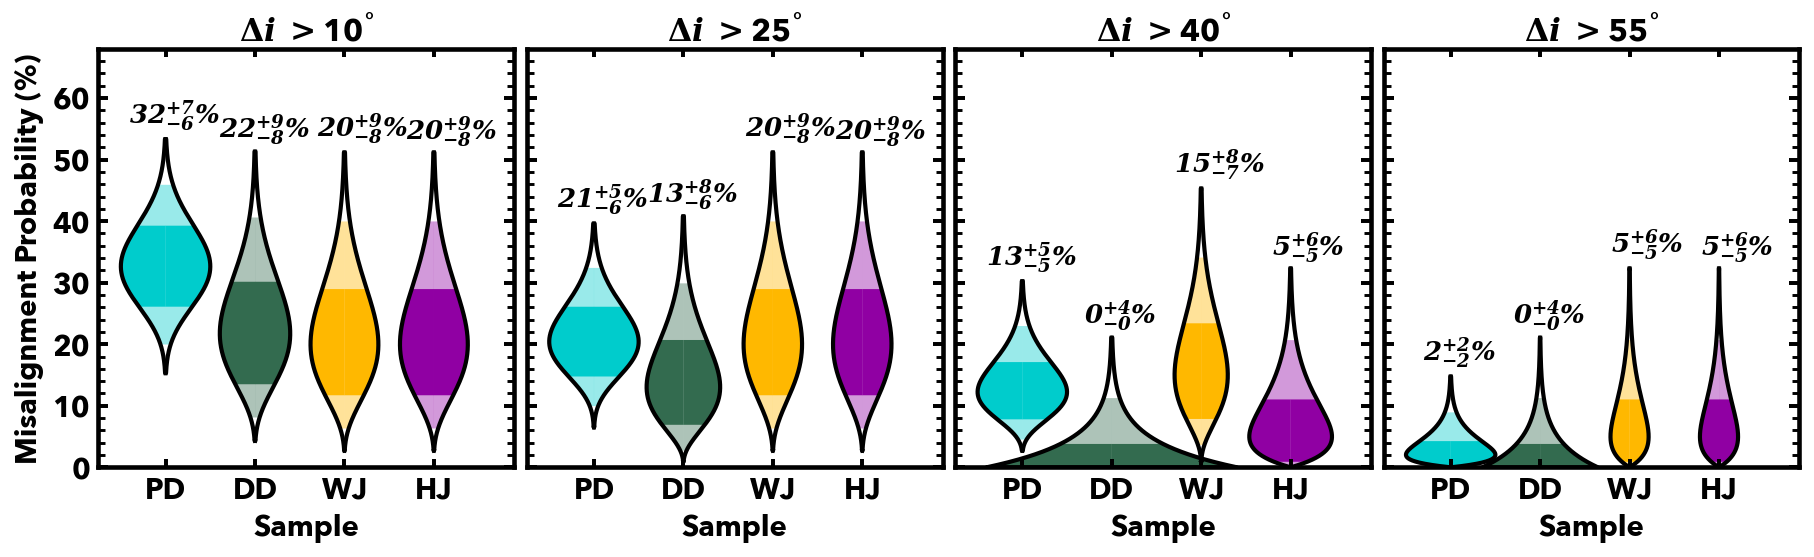

In [61]:
misalignment_method = 'Individual Precision'
# misalignment_method = 'Global Threshold'

misaligned_rate_fontsize = 14

possible_ax_letters = list(string.ascii_lowercase)
num_ax_letters = len([key_i for key_i in misaligned_lists['DD'].keys() if 'MAP' in key_i]) - 1
ax_letters = possible_ax_letters[0:num_ax_letters]
mosaic_str = ''.join(ax_letters)

misalignment_fractions = {}
for which_dataset in datasets:
    misalignment_fractions[which_dataset] = {}
    for threshold_i in misalignment_thresholds:
        misalignment_fractions[which_dataset]['{:d} deg'.format(threshold_i)] = {}
        

fig = plt.figure(figsize=(3*num_ax_letters, 4-(0.1*num_ax_letters)))
axes = fig.subplot_mosaic(
    mosaic_str,
    gridspec_kw={'height_ratios': [1], 'width_ratios': [1]*num_ax_letters, "bottom": 0.145, "top": 0.92, "left": 0.05, "right": 0.995, "wspace": 0.03, "hspace": 0.06}
)

if only_multis_PD == True or only_multis_DD == True or only_multis_WJ == True or only_multis_HJ == True:
    yticks = [0, 10, 20, 30, 40, 50, 60, 70, 80]
    ymax = 84
else:
    yticks = [0, 10, 20, 30, 40, 50, 60]
    ymax = 68

for mis_panel, mis in enumerate(misalignment_thresholds):

    test_mis = 9
    do_test_mis = False
    
    ax = axes[ax_letters[mis_panel]]

    ax.minorticks_on()

    # mpl.rcParams['mathtext.fontset'] = 'stix'
    mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
    ax.set_title(r'$\mathit{\Delta i}$' + r' $>$' + str(mis) + r'$^{\degree}$', fontsize=misaligned_rate_fontsize+1, family='sans-serif')

    ax.set_yticks(yticks)
    if ax_letters[mis_panel] == ax_letters[0]:
        ax.set_ylabel(r'Misalignment Probability (%)', fontsize=misaligned_rate_fontsize)
        ax.set_yticklabels(yticks, fontsize=misaligned_rate_fontsize)
    else:
        ax.set_yticklabels([], fontsize=misaligned_rate_fontsize)
    ax.set_xlabel('Sample', fontsize=misaligned_rate_fontsize)

    for data_i, which_dataset in enumerate(datasets):
        confidence = 90

        if which_dataset == 'PD':
            test_df = df_PD
            ccombonum = 1
            multis_list = PD_multis
            singles_list = PD_singles
            only_multis = only_multis_PD
            only_singles = only_singles_PD
        if which_dataset == 'DD':
            test_df = df_DD
            ccombonum = 2
            multis_list = DD_multis
            singles_list = DD_singles
            only_multis = only_multis_DD
            only_singles = only_singles_DD
        if which_dataset == 'WJ':
            test_df = df_WJ
            ccombonum = 3
            multis_list = WJ_multis
            singles_list = WJ_singles
            only_multis = only_multis_WJ
            only_singles = only_singles_WJ
        if which_dataset == 'HJ':
            test_df = df_HJ
            ccombonum = 4
            multis_list = HJ_multis
            singles_list = HJ_singles
            only_multis = only_multis_HJ
            only_singles = only_singles_HJ


        if only_multis == True:
            only_singles = False

        if only_multis == False and only_singles == False:
            sample_size = len(test_df['Target'].values)
        if only_multis == True:
            sample_size = len(multis_list)
        if only_singles == True:
            sample_size = len(singles_list)

        if ccombonum == 1:
            ccombo = ['#008fc7', '#6a3dff', pd_color] 
        elif ccombonum == 2:
            ccombo = ['#ff6600', '#006666', dd_color]
        elif ccombonum == 3:
            ccombo = ['#cc6600', '#cc3300', WJ_color] 
        elif ccombonum == 4:
            ccombo = ['#0000cc', '#808080', HJ_color]


        p90_color = ccombo[2]            
        
        x = np.linspace(0, 1, 10000)
        n = sample_size

        # print(str(mis) + ' deg: ')
        if misalignment_method == 'Individual Precision':
            k = len(misaligned_lists[which_dataset][str(mis) + ' deg'])
        if misalignment_method == 'Global Threshold':
            k = len(misaligned_lists_global_threshold[which_dataset][str(mis) + ' deg'])


        prob_dist = bb_binomial_ppd(x, k, n, normapprox=False)

        if which_dataset == 'PD':
            max_dist = max(prob_dist)

        report_stat = 'mode'
        misaligned_MAP, sig1_misaligned_m, sig1_misaligned_p, _, _, misaligned_allstats = highest_density_interval(x=x, pdf_y=prob_dist, sigma=0.6827, type=report_stat)
        _, sig2_misaligned_m, sig2_misaligned_p, _, _, _ = highest_density_interval(x=x, pdf_y=prob_dist, sigma=0.9545, type=report_stat)
        _, sig3_misaligned_m, sig3_misaligned_p, _, _, _ = highest_density_interval(x=x, pdf_y=prob_dist, sigma=0.9973, type=report_stat)

        misalignment_fractions[which_dataset][str(mis) + ' deg'][str(confidence)] = misaligned_MAP*100
        misalignment_fractions[which_dataset][str(mis) + ' deg'][str(confidence) + '+'] = sig1_misaligned_p*100
        misalignment_fractions[which_dataset][str(mis) + ' deg'][str(confidence) + '-'] = sig1_misaligned_m*100

        fill_x = x[np.where((x >= misaligned_MAP - sig1_misaligned_m) & (x <= misaligned_MAP + sig1_misaligned_p))[0]] * 100
        fill_y = prob_dist[np.where((x >= misaligned_MAP - sig1_misaligned_m) & (x <= misaligned_MAP + sig1_misaligned_p))[0]]/max_dist*0.5

        fill_x = np.concatenate(([fill_x[0]], fill_x, [fill_x[-1]]))
        fill_y = np.concatenate(([0], fill_y, [0]))

        fill_x2 = x[np.where((x >= misaligned_MAP - sig2_misaligned_m) & (x <= misaligned_MAP + sig2_misaligned_p))[0]] * 100
        fill_y2 = prob_dist[np.where((x >= misaligned_MAP - sig2_misaligned_m) & (x <= misaligned_MAP + sig2_misaligned_p))[0]]/max_dist*0.5

        fill_x2 = np.concatenate(([fill_x2[0]], fill_x2, [fill_x2[-1]]))
        fill_y2 = np.concatenate(([0], fill_y2, [0]))

        plot_x = x[np.where((x >= misaligned_MAP - sig3_misaligned_m) & (x <= misaligned_MAP + sig3_misaligned_p))[0]] * 100
        plot_y = prob_dist[np.where((x >= misaligned_MAP - sig3_misaligned_m) & (x <= misaligned_MAP + sig3_misaligned_p))[0]]/max_dist*0.5

        plot_x = np.concatenate(([plot_x[0]], plot_x, [plot_x[-1]]))
        plot_y = np.concatenate(([0], plot_y, [0]))

        ax.plot(plot_y + ccombonum, plot_x, color='#000000', lw=2.0)
        ax.plot((-plot_y) + ccombonum, plot_x, color='#000000', lw=2.0)
        
        ax.fill_between(x=fill_y + ccombonum, y1=fill_x, y2=0, facecolor=p90_color, alpha=1, zorder=-1)
        fill_y = -fill_y
        fill_y[0] += 0.0011
        fill_y[-1] += 0.0011
        ax.fill_between(x=fill_y + ccombonum, y1=fill_x, y2=0, facecolor=p90_color, alpha=1, zorder=-1)
        
        ax.fill_between(x=fill_y2 + ccombonum, y1=fill_x2, y2=0, facecolor=p90_color, alpha=0.4, zorder=-2)
        fill_y2 = -fill_y2
        fill_y2[0] += 0.0011
        fill_y2[-1] += 0.0011
        ax.fill_between(x=fill_y2 + ccombonum, y1=fill_x2, y2=0, facecolor=p90_color, alpha=0.4, zorder=-2)


        # plt.rcParams['mathtext.default'] = 'regular'
        # if which_dataset == 'PD' and mis == misalignment_thresholds[1]:
        #     fraction_text = r"${:d}^{{+{:d}}}_{{-{:d}}}\%$".format(round(misaligned_MAP*100), round(sig1_misaligned_p*100), 5)
        # else:

        if which_dataset == 'PD':
            fraction_text_xshift = 0.1
            fraction_text_yshift = 1
        elif which_dataset == 'DD':
            fraction_text_xshift = 0.1
            fraction_text_yshift = 0.75
        elif which_dataset == 'WJ':
            fraction_text_xshift = 0.2
            fraction_text_yshift = 1
        elif which_dataset == 'HJ':
            fraction_text_xshift = 0.2
            fraction_text_yshift = 0.5


        fraction_text = r"${:d}^{{+{:d}}}_{{-{:d}}}\%$".format(round(misaligned_MAP*100), round(sig1_misaligned_p*100), round(sig1_misaligned_m*100))
        ax.text(ccombonum + fraction_text_xshift, max(plot_x) + fraction_text_yshift, fraction_text, horizontalalignment='center', verticalalignment='bottom', fontsize=misaligned_rate_fontsize-1.5) # , fontfamily='DejaVu Serif')  # , transform=ax.transAxes)

        xticks = [1, 2, 3, 4]
        xlabs = ['PD', 'DD', 'WJ', 'HJ']
        ax.set_xticks(xticks)
        ax.set_xticklabels(xlabs)

        ax.set_xlim(0.35, 4.65)

        # ax.tick_params(axis='both', which='major', length=5, width=1.9)
        # ax.tick_params(axis='both', which='minor', length=4, width=1.4, bottom=False, top=False)

        fraction_text2 = "{:d} +{:d},-{:d} %".format(round(misaligned_MAP*100), round(sig1_misaligned_p*100), round(sig1_misaligned_m*100))

    ax.tick_params(axis='x', which='major', length=4, width=1.9, labelsize=misaligned_rate_fontsize)
    ax.tick_params(axis='y', which='major', length=5, width=1.9, labelsize=misaligned_rate_fontsize) 
    ax.tick_params(axis='x', which='minor', length=0, width=1.4, labelsize=misaligned_rate_fontsize)
    ax.tick_params(axis='y', which='minor', length=3.5, width=1.4, labelsize=misaligned_rate_fontsize) 

    for spine_location in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine_location].set_linewidth(2.2)

    ax.set_ylim(0, ymax)
    ax.set_xlim(0.25, 4.9)
    
    # print(' ')

# SAVE THE FIGURE
misalignmet_rate_savetext = 'Misalignment_Thresholds_' + date_str + '.pdf'
fig.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/' + misalignmet_rate_savetext, dpi=300, transparent=False)
plt.show()
plt.close()

Median Ages: 
PD: 2.31 Myr
DD: 190.00 Myr
WJ: 1.85 Gyr
HJ: 7.00 Gyr


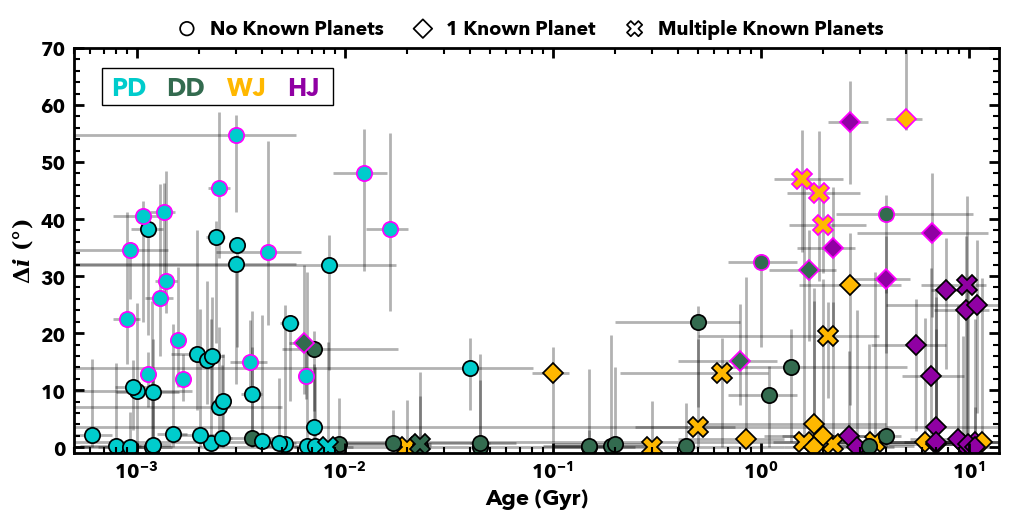

In [ ]:
fig = plt.figure(figsize=(10, 5), dpi=100)
ax = fig.add_axes(111)
ax.minorticks_on()
ax.set_xlabel('Age (Gyr)', fontsize=16) # , labelpad=8)
ax.yaxis.label.set_family("DejaVu Serif")
ax.set_ylabel(r'$\mathit{\Delta i}$ ($\degree$)', fontsize=16, weight='semibold') # , labelpad=8)

edge_color = "#000000"

print('Median Ages: ')

age_progression_dataset_order = ['PD', 'DD', 'WJ', 'HJ']

for which_dataset in age_progression_dataset_order:

    if which_dataset == 'PD':
        plot_df = df_PD
        dataset_point_color = pd_color
        aligned_color = '#b0e8e8'
        misaligned_color = '#004d4d'
        multis_list = PD_multis
        singles_list = PD_singles
        with_planets_list = PD_with_planets
        z_order_base = -2
        x_key = 'Rdisk (au)'
        x_key_m = 'Rdisk -Unc'
        x_key_p = 'Rdisk -Unc'
        print(f"{which_dataset}: {np.median(plot_df['Age (Myr)'].values):.2f} Myr")
    if which_dataset == 'DD':
        plot_df = df_DD
        dataset_point_color = dd_color
        aligned_color = '#87c5a6'
        misaligned_color = '#214534'
        multis_list = DD_multis
        singles_list = DD_singles
        with_planets_list = DD_with_planets
        z_order_base = -8
        x_key = 'Rdisk (au)'
        x_key_m = 'Rdisk -Unc'
        x_key_p = 'Rdisk -Unc'
        print(f"{which_dataset}: {np.median(plot_df['Age (Myr)'].values):.2f} Myr")
    if which_dataset == 'WJ':
        plot_df = df_WJ
        dataset_point_color = WJ_color
        aligned_color = '#ffe9b3'
        misaligned_color = '#805b00'
        multis_list = WJ_multis
        singles_list = WJ_singles
        with_planets_list = WJ_with_planets
        z_order_base = -11
        x_key = 'a/Rstar'
        x_key_m = 'a/Rstar -Unc'
        x_key_p = 'a/Rstar +Unc'
        print(f"{which_dataset}: {np.median(np.array(plot_df['Age (Myr)'].values) * 1e-3):.2f} Gyr")
    if which_dataset == 'HJ':
        plot_df = df_HJ
        dataset_point_color = HJ_color
        aligned_color = '#cf70db'
        misaligned_color = '#5a0066'
        multis_list = HJ_multis
        singles_list = HJ_singles
        with_planets_list = HJ_with_planets
        z_order_base = -5
        x_key = 'a/Rstar'
        x_key_m = 'a/Rstar -Unc'
        x_key_p = 'a/Rstar +Unc'
        print(f"{which_dataset}: {np.median(np.array(plot_df['Age (Myr)'].values) * 1e-3):.2f} Gyr")

        

    targets_list = np.array(plot_df['Target'].values)

    x_data = np.array(plot_df['Age (Myr)'].values) * 1e-3
    x_err_m = np.array(plot_df['Age -Unc'].values) * 1e-3
    x_err_p = np.array(plot_df['Age +Unc'].values) * 1e-3

    y_data = np.array(plot_df['disk diff'].values)
    y_err_m = np.array(plot_df['disk diff -Unc'].values)
    y_err_p = np.array(plot_df['disk diff +Unc'].values)

    for bep_i in range(len(targets_list)):

        point_edge_color = '#000000'
        point_edge_width = 1.25

        if targets_list[bep_i] in with_planets_list:
            point_shape = 'D'
            point_size_number = 10
            if targets_list[bep_i] in multis_list:
                point_shape = 'X'
                point_size_number = 14
                z_order_number = z_order_base - 1
        else:
            point_shape = 'o'
            point_size_number = 11
            z_order_number = z_order_base - 2

        target_str = targets_list[bep_i].replace(' ', '')
        if target_str not in misaligned_lists[which_dataset]['ALL']:
            point_color = aligned_color
        else:
            point_edge_color = "#FF00FF"

        point_color = dataset_point_color # misaligned_color
        

        ax.errorbar(x_data[bep_i], y_data[bep_i],
                    xerr=[[x_err_m[bep_i]], [x_err_p[bep_i]]],
                    yerr=[[y_err_m[bep_i]], [y_err_p[bep_i]]],
                    marker=point_shape, mfc=point_color, mec=point_edge_color, ms=point_size_number, mew=point_edge_width,
                    elinewidth=0, linewidth=0, capsize=0, ecolor='#000000', capthick=0, zorder=z_order_number)
        ax.errorbar(x_data[bep_i], y_data[bep_i],
                    xerr=[[x_err_m[bep_i]], [x_err_p[bep_i]]],
                    yerr=[[y_err_m[bep_i]], [y_err_p[bep_i]]],
                    marker=point_shape, mfc='None', mec='None', ms=point_size_number, mew=0,
                    elinewidth=2, linewidth=0, capsize=0, ecolor='#000000', capthick=0, alpha=0.3, zorder=z_order_number-20)

ax.scatter([], [], color='None', edgecolors='#000000', marker='o', linewidth=1.25, s=np.pi*5.5**2, linestyle='None', zorder=-4, label='No Known Planets')
ax.scatter([], [], color='None', edgecolors='#000000', marker='D', linewidth=1.25, s=90, linestyle='None', zorder=-4, label='1 Known Planet')
ax.scatter([], [], color='None', edgecolors='#000000', marker='X', linewidth=1.25, s=120, linestyle='None', zorder=-4, label='Multiple Known Planets')

xlims = 5e-4, 14 # , 1.5e-4, 15

ax.set_xlim(xlims)
ax.set_ylim(-1, 70)

xticks = (1e-3, 1e-2, 1e-1, 1e0, 1e1)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, fontsize=16)

ax.set_xscale('log')

ax.tick_params(axis='x', which='major', labelsize=14, length=7, width=2.25, pad=6)
ax.tick_params(axis='y', which='major', labelsize=14, length=7, width=2.25, pad=6)
ax.tick_params(axis='x', which='minor', length=4, width=1.5)
ax.tick_params(axis='y', which='minor', length=4, width=1.5)

for spine1 in ax.spines.values():
        spine1.set_linewidth(2)

ax.legend(loc='upper left', ncol=4, handletextpad=0.2, frameon=False, framealpha=1, bbox_to_anchor=(0.08, 1.12), fontsize=14)

label_y = 0.87

PD_xy = 0.04, label_y
DD_xy = PD_xy[0] + 0.06, label_y
WJ_xy = PD_xy[0] + 0.125, label_y
HJ_xy = PD_xy[0] + 0.19, label_y

ax.text(PD_xy[0], PD_xy[1], 'PD', color=pd_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax.transAxes)
ax.text(DD_xy[0], DD_xy[1], 'DD', color=dd_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax.transAxes)
ax.text(WJ_xy[0], WJ_xy[1], 'WJ', color=WJ_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax.transAxes)
ax.text(HJ_xy[0], HJ_xy[1], 'HJ', color=HJ_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax.transAxes)

# 2. Define rectangle parameters
# Anchor at (1.5, 2.0), width 2.0, height 1.5
bottom_left_xy = PD_xy[0]-0.01, PD_xy[1]-0.01
width = HJ_xy[0] + 0.04 - PD_xy[0] + 0.02
height = 0.09

# 3. Create a Rectangle patch (hollow with red edge)
rect = mpl.patches.Rectangle(
    bottom_left_xy,
    width,
    height,
    linewidth=1,
    edgecolor='#000000',
    facecolor='none',
    transform=ax.transAxes
)

ax.add_patch(rect)

plt.subplots_adjust(bottom=0.12, top=0.93, left=0.065, right=0.99)

# SAVE THE FIGURE
save_age_vs_Deltai_string = 'Age_vs_Deltai_' + date_str + '.pdf'

fig.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/' + save_age_vs_Deltai_string, dpi=300, transparent=False)

plt.show()
plt.close()


Median Ages: 
PD: 2.31 Myr
DD: 190.00 Myr
WJ: 1.85 Gyr
HJ: 7.00 Gyr


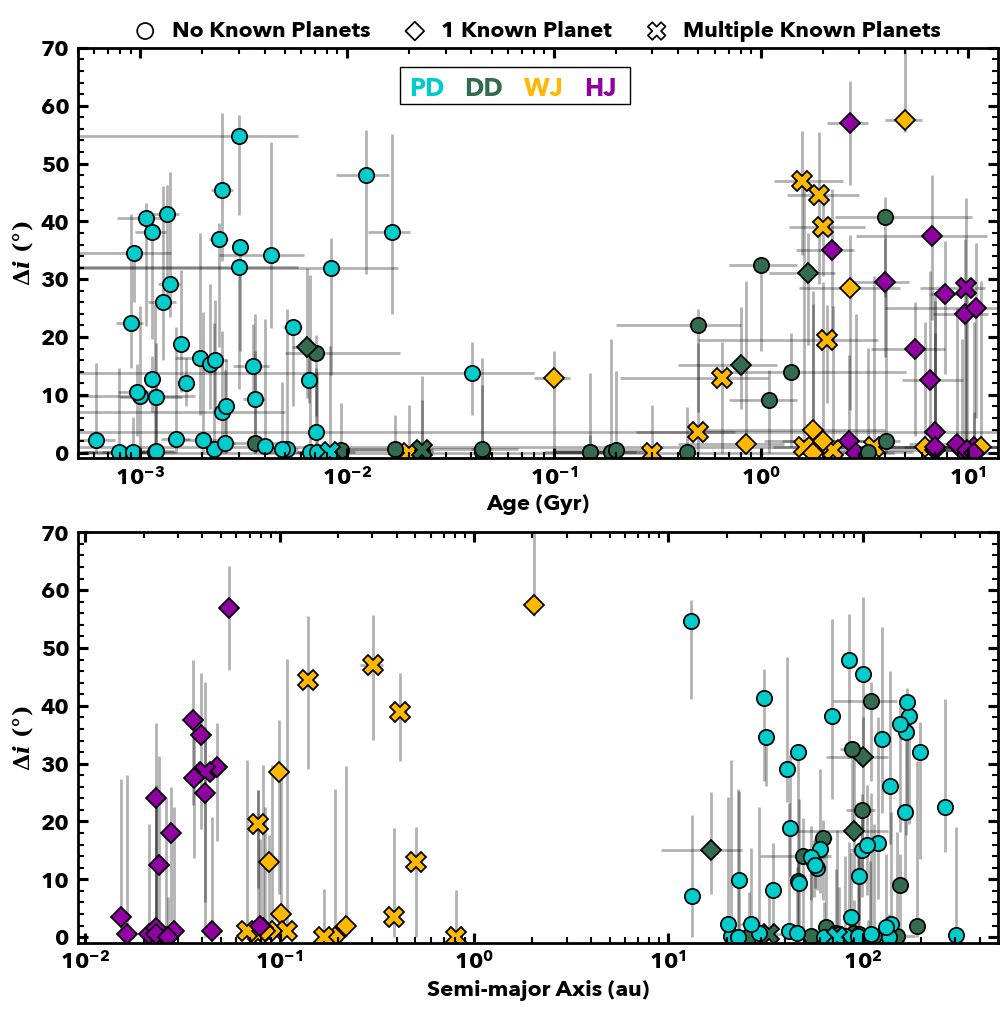

In [ ]:
fig = plt.figure(figsize=(10, 10), dpi=100)
axes = fig.subplot_mosaic(
    """
    a
    b
    """,
    gridspec_kw={'height_ratios': [1, 1], 'width_ratios': [1], "bottom": 0.065, "top": 0.96, "left": 0.07, "right": 0.99, "wspace": 0.0, "hspace": 0.18}
)

edge_color = "#000000"
misaligned_edge_color = "#000000"
age_sep_fontsize = 16

ax1 = axes['a']
ax1.minorticks_on()
ax1.set_xlabel('Age (Gyr)', fontsize=age_sep_fontsize, labelpad=3)
ax1.yaxis.label.set_family("DejaVu Serif")
ax1.set_ylabel(r'$\mathit{\Delta i}$ ($\degree$)', fontsize=16, weight='semibold') # , labelpad=8)

ax2 = axes['b']
ax2.minorticks_on()
ax2.set_xlabel('Semi-major Axis (au)', fontsize=16) # , labelpad=8)
ax2.yaxis.label.set_family("DejaVu Serif")
ax2.set_ylabel(r'$\mathit{\Delta i}$ ($\degree$)', fontsize=16, weight='semibold') # , labelpad=8)


print('Median Ages: ')

age_progression_dataset_order = ['PD', 'DD', 'WJ', 'HJ']

for which_dataset in age_progression_dataset_order:

    if which_dataset == 'PD':
        plot_df = df_PD
        dataset_point_color = pd_color
        aligned_color = '#b0e8e8'
        misaligned_color = '#004d4d'
        multis_list = PD_multis
        singles_list = PD_singles
        with_planets_list = PD_with_planets
        z_order_base = -2
        x_key = 'Rdisk (au)'
        x_key_m = 'Rdisk -Unc'
        x_key_p = 'Rdisk -Unc'
        print(f"{which_dataset}: {np.median(plot_df['Age (Myr)'].values):.2f} Myr")
    if which_dataset == 'DD':
        plot_df = df_DD
        dataset_point_color = dd_color
        aligned_color = '#87c5a6'
        misaligned_color = '#214534'
        multis_list = DD_multis
        singles_list = DD_singles
        with_planets_list = DD_with_planets
        z_order_base = -8
        x_key = 'Rdisk (au)'
        x_key_m = 'Rdisk -Unc'
        x_key_p = 'Rdisk -Unc'
        print(f"{which_dataset}: {np.median(plot_df['Age (Myr)'].values):.2f} Myr")
    if which_dataset == 'WJ':
        plot_df = df_WJ
        dataset_point_color = WJ_color
        aligned_color = '#ffe9b3'
        misaligned_color = '#805b00'
        multis_list = WJ_multis
        singles_list = WJ_singles
        with_planets_list = WJ_with_planets
        z_order_base = -11
        x_key = 'a/Rstar'
        x_key_m = 'a/Rstar -Unc'
        x_key_p = 'a/Rstar +Unc'
        print(f"{which_dataset}: {np.median(np.array(plot_df['Age (Myr)'].values) * 1e-3):.2f} Gyr")
    if which_dataset == 'HJ':
        plot_df = df_HJ
        dataset_point_color = HJ_color
        aligned_color = '#cf70db'
        misaligned_color = '#5a0066'
        multis_list = HJ_multis
        singles_list = HJ_singles
        with_planets_list = HJ_with_planets
        z_order_base = -5
        x_key = 'a/Rstar'
        x_key_m = 'a/Rstar -Unc'
        x_key_p = 'a/Rstar +Unc'
        print(f"{which_dataset}: {np.median(np.array(plot_df['Age (Myr)'].values) * 1e-3):.2f} Gyr")

        

    targets_list = np.array(plot_df['Target'].values)

    x_data = np.array(plot_df['Age (Myr)'].values) * 1e-3
    x_err_m = np.array(plot_df['Age -Unc'].values) * 1e-3
    x_err_p = np.array(plot_df['Age +Unc'].values) * 1e-3

    y_data = np.array(plot_df['disk diff'].values)
    y_err_m = np.array(plot_df['disk diff -Unc'].values)
    y_err_p = np.array(plot_df['disk diff +Unc'].values)

    for bep_i in range(len(targets_list)):

        point_edge_color = '#000000'
        point_edge_width = 1.25

        if targets_list[bep_i] in with_planets_list:
            point_shape = 'D'
            point_size_number = 10
            if targets_list[bep_i] in multis_list:
                point_shape = 'X'
                point_size_number = 14
                z_order_number = z_order_base - 1
        else:
            point_shape = 'o'
            point_size_number = 11
            z_order_number = z_order_base - 2

        target_str = targets_list[bep_i].replace(' ', '')
        if target_str not in misaligned_lists[which_dataset]['ALL']:
            point_color = aligned_color
        else:
            point_edge_color = misaligned_edge_color  # "#B7FF00" # "#FF00FF"

        point_color = dataset_point_color # misaligned_color
        

        ax1.errorbar(x_data[bep_i], y_data[bep_i],
                    xerr=[[x_err_m[bep_i]], [x_err_p[bep_i]]],
                    yerr=[[y_err_m[bep_i]], [y_err_p[bep_i]]],
                    marker=point_shape, mfc=point_color, mec=point_edge_color, ms=point_size_number, mew=point_edge_width,
                    elinewidth=0, linewidth=0, capsize=0, ecolor='#000000', capthick=0, zorder=z_order_number)
        ax1.errorbar(x_data[bep_i], y_data[bep_i],
                    xerr=[[x_err_m[bep_i]], [x_err_p[bep_i]]],
                    yerr=[[y_err_m[bep_i]], [y_err_p[bep_i]]],
                    marker=point_shape, mfc='None', mec='None', ms=point_size_number, mew=0,
                    elinewidth=2, linewidth=0, capsize=0, ecolor='#000000', capthick=0, alpha=0.3, zorder=z_order_number-20)


    x_data1 = np.array(plot_df[x_key].values)
    x_data = []
    x_err_m = []
    x_err_p = []

    if which_dataset == 'PD':
        x_data = np.array(plot_df[x_key].values)
        x_err_m = np.array(plot_df[x_key_m].values)
        x_err_p = np.array(plot_df[x_key_p].values)
    elif which_dataset == 'DD':
        delta_x = plot_df['Delta Rdisk (au)'].values
        for delta_Rdisk_i, delta_Rdisk in enumerate(delta_x):
            x_data.append(float(plot_df[x_key].values[delta_Rdisk_i]))
            if delta_Rdisk_i == 0:
                x_err_m.append(float(plot_df['Delta Rdisk -Unc'].values[delta_Rdisk_i]))
                x_err_p.append(float(plot_df['Delta Rdisk +Unc'].values[delta_Rdisk_i]))
            else:
                x_err_m.append(float(0.5 * delta_x[delta_Rdisk_i]))
                x_err_p.append(float(0.5 * delta_x[delta_Rdisk_i]))
    else:
        for separation_i, separation in enumerate(x_data1):
            x_data.append(float(separation * (np.array(plot_df['Rstar (Rsun)'].values[separation_i]) * u.Rsun).to(u.au).value))
            x_err_m.append(float(plot_df[x_key_m].values[separation_i] * (np.array(plot_df['Rstar (Rsun)'].values[separation_i])*u.Rsun).to(u.au).value))
            x_err_p.append(float(plot_df[x_key_p].values[separation_i] * (np.array(plot_df['Rstar (Rsun)'].values[separation_i])*u.Rsun).to(u.au).value))


    y_data = np.array(plot_df['disk diff'].values)
    y_err_m = np.array(plot_df['disk diff -Unc'].values)
    y_err_p = np.array(plot_df['disk diff +Unc'].values)

    for bep_i in range(len(targets_list)):

        point_edge_color = '#000000'
        point_edge_width = 1.25

        if targets_list[bep_i] in with_planets_list:
            point_shape = 'D'
            point_size_number = 10
            if targets_list[bep_i] in multis_list:
                point_shape = 'X'
                point_size_number = 14
                z_order_number = z_order_base - 1
        else:
            point_shape = 'o'
            point_size_number = 11
            z_order_number = z_order_base - 2

        target_str = targets_list[bep_i].replace(' ', '')
        if target_str not in misaligned_lists[which_dataset]['ALL']:
            point_color = aligned_color
        else:
            point_edge_color = misaligned_edge_color

        point_color = dataset_point_color # misaligned_color
        

        ax2.errorbar(x_data[bep_i], y_data[bep_i],
                    xerr=[[x_err_m[bep_i]], [x_err_p[bep_i]]],
                    yerr=[[y_err_m[bep_i]], [y_err_p[bep_i]]],
                    marker=point_shape, mfc=point_color, mec=point_edge_color, ms=point_size_number, mew=point_edge_width,
                    elinewidth=0, linewidth=0, capsize=0, ecolor='#000000', capthick=0, zorder=z_order_number)
        ax2.errorbar(x_data[bep_i], y_data[bep_i],
                    xerr=[[x_err_m[bep_i]], [x_err_p[bep_i]]],
                    yerr=[[y_err_m[bep_i]], [y_err_p[bep_i]]],
                    marker=point_shape, mfc='None', mec='None', ms=point_size_number, mew=0,
                    elinewidth=2, linewidth=0, capsize=0, ecolor='#000000', capthick=0, alpha=0.3, zorder=z_order_number-20)
        
ax1.scatter([], [], color='None', edgecolors='#000000', marker='o', linewidth=1.25, s=np.pi*6.5**2, linestyle='None', zorder=-4, label='No Known Planets')
ax1.scatter([], [], color='None', edgecolors='#000000', marker='D', linewidth=1.25, s=90, linestyle='None', zorder=-4, label='1 Known Planet')
ax1.scatter([], [], color='None', edgecolors='#000000', marker='X', linewidth=1.25, s=160, linestyle='None', zorder=-4, label='Multiple Known Planets')

xlims = 5e-4, 14 # , 1.5e-4, 15
ylims = -1, 66

ax1.set_xlim(xlims)
ax1.set_ylim(ylims)
ax2.set_ylim(ylims)

xticks = (1e-3, 1e-2, 1e-1, 1e0, 1e1)
ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, fontsize=16)

ax1.set_xscale('log')
ax2.set_xscale('log')

ax1.tick_params(axis='x', which='major', labelsize=age_sep_fontsize, length=7, width=2.25, pad=6)
ax1.tick_params(axis='y', which='major', labelsize=age_sep_fontsize, length=7, width=2.25, pad=6)
ax1.tick_params(axis='x', which='minor', length=4, width=1.5)
ax1.tick_params(axis='y', which='minor', length=4, width=1.5)

ax2.tick_params(axis='x', which='major', labelsize=age_sep_fontsize, length=7, width=2.25, pad=6)
ax2.tick_params(axis='y', which='major', labelsize=age_sep_fontsize, length=7, width=2.25, pad=6)
ax2.tick_params(axis='x', which='minor', length=4, width=1.5)
ax2.tick_params(axis='y', which='minor', length=4, width=1.5)

for spine1 in ax1.spines.values():
        spine1.set_linewidth(2)
for spine2 in ax2.spines.values():
        spine2.set_linewidth(2)

# ax1.legend(loc='upper left', ncol=4, handletextpad=0.2, frameon=False, framealpha=1, bbox_to_anchor=(0.025, 1.12), fontsize=age_sep_fontsize)
ax1.legend(loc='upper left', ncol=4, handletextpad=0.2, frameon=False, framealpha=1, bbox_to_anchor=(0.025, 1.12), fontsize=age_sep_fontsize)

label_y = 0.87
label_x = 0.36  # 0.04

PD_xy = label_x, label_y
DD_xy = PD_xy[0] + 0.06, label_y
WJ_xy = PD_xy[0] + 0.125, label_y
HJ_xy = PD_xy[0] + 0.19, label_y

ax1.text(PD_xy[0], PD_xy[1], 'PD', color=pd_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax1.transAxes)
ax1.text(DD_xy[0], DD_xy[1], 'DD', color=dd_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax1.transAxes)
ax1.text(WJ_xy[0], WJ_xy[1], 'WJ', color=WJ_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax1.transAxes)
ax1.text(HJ_xy[0], HJ_xy[1], 'HJ', color=HJ_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax1.transAxes)

# 2. Define rectangle parameters
# Anchor at (1.5, 2.0), width 2.0, height 1.5
bottom_left_xy = PD_xy[0]-0.01, PD_xy[1]-0.007
width = HJ_xy[0] + 0.04 - PD_xy[0] + 0.02
height = 0.09

# 3. Create a Rectangle patch (hollow with red edge)
rect = mpl.patches.Rectangle(
    bottom_left_xy,
    width,
    height,
    linewidth=1,
    edgecolor='#000000',
    facecolor='none',
    transform=ax1.transAxes
)

ax1.add_patch(rect)


# SAVE THE FIGURE
save_age_and_separation_vs_Deltai_string = 'Age_and_Separation_vs_Deltai_' + date_str + '.pdf'

fig.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/' + save_age_and_separation_vs_Deltai_string, dpi=300, transparent=False)

plt.show()
plt.close()


In [64]:
print('AGE DIFFERENCES')
print(f"DD - PD: {np.median(df_DD['Age (Myr)'].values) - np.median(df_PD['Age (Myr)'].values):.2f} Myr")
print(f"WJ - DD: {np.median(df_WJ['Age (Myr)'].values) - np.median(df_DD['Age (Myr)'].values):.2f} Myr")
print(f"HJ - WJ: {np.median(df_HJ['Age (Myr)'].values) - np.median(df_WJ['Age (Myr)'].values):.2f} Myr")



AGE DIFFERENCES
DD - PD: 187.69 Myr
WJ - DD: 1665.00 Myr
HJ - WJ: 5145.00 Myr


In [65]:
DD_misaligned_ages = []
DD_aligned_ages = []

for system in df_DD['Target'].values:
    temp_df = df_DD[df_DD['Target'].values == system]
    system = system.replace(' ', '')
    if system in misaligned_lists['DD']['ALL']:
        DD_misaligned_ages.append(temp_df['Age (Myr)'].values[0])
    else:
        DD_aligned_ages.append(temp_df['Age (Myr)'].values[0])

print(DD_misaligned_ages)
print(DD_aligned_ages)
print('------')
print('Average DD Misaligned Age: {:.2f} Myr'.format(np.mean(DD_misaligned_ages)))
print('Median DD Misaligned Age: {:.2f} Myr'.format(np.median(DD_misaligned_ages)))
print('------')
print('Average DD Aligned Age: {:.2f} Myr'.format(np.mean(DD_aligned_ages)))
print('Median DD Aligned Age: {:.2f} Myr'.format(np.median(DD_aligned_ages)))

[np.float64(1700.0), np.float64(4000.0), np.float64(1000.0), np.float64(6.4), np.float64(800.0)]
[np.float64(4020.0), np.float64(23.0), np.float64(23.0), np.float64(440.0), np.float64(500.0), np.float64(190.0), np.float64(45.0), np.float64(150.0), np.float64(17.0), np.float64(1100.0), np.float64(7.1), np.float64(3320.0), np.float64(1400.0), np.float64(149.0), np.float64(45.0), np.float64(200.0), np.float64(3.6), np.float64(9.4)]
------
Average DD Misaligned Age: 1501.28 Myr
Median DD Misaligned Age: 1000.00 Myr
------
Average DD Aligned Age: 646.78 Myr
Median DD Aligned Age: 149.50 Myr


Median Ages: 
PD: 2.31 Myr
DD: 190.00 Myr
WJ: 1.85 Gyr
HJ: 7.00 Gyr


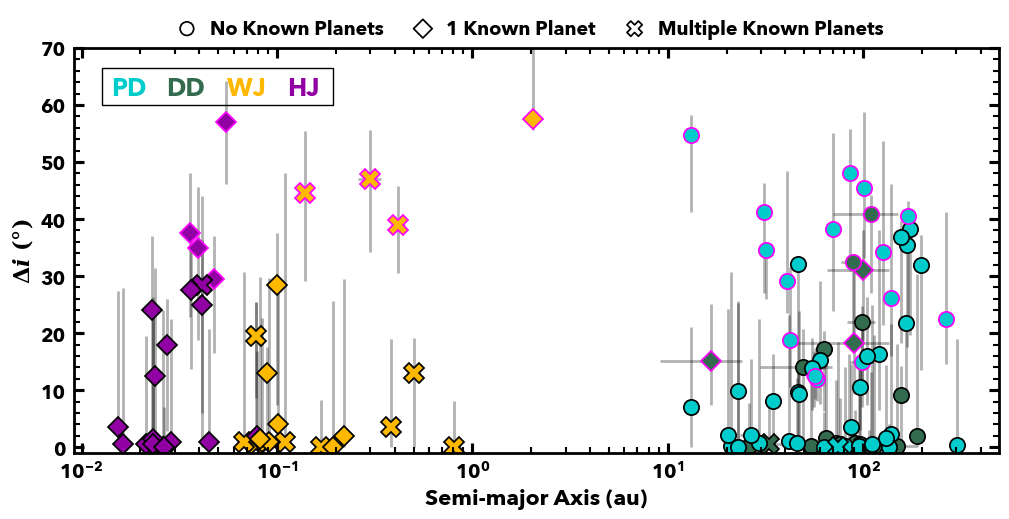

In [104]:
fig = plt.figure(figsize=(10, 5), dpi=100)
ax = fig.add_axes(111)
ax.minorticks_on()
ax.set_xlabel('Semi-major Axis (au)', fontsize=16) # , labelpad=8)
ax.yaxis.label.set_family("DejaVu Serif")
ax.set_ylabel(r'$\mathit{\Delta i}$ ($\degree$)', fontsize=16, weight='semibold') # , labelpad=8)

edge_color = "#000000"

print('Median Ages: ')

age_progression_dataset_order = ['PD', 'DD', 'WJ', 'HJ']

for which_dataset in age_progression_dataset_order:

    if which_dataset == 'PD':
        plot_df = df_PD
        dataset_point_color = pd_color
        aligned_color = '#b0e8e8'
        misaligned_color = '#004d4d'
        multis_list = PD_multis
        singles_list = PD_singles
        with_planets_list = PD_with_planets
        z_order_base = -2
        x_key = 'Rdisk (au)'
        x_key_m = 'Rdisk -Unc'
        x_key_p = 'Rdisk -Unc'
        print(f"{which_dataset}: {np.median(plot_df['Age (Myr)'].values):.2f} Myr")
    if which_dataset == 'DD':
        plot_df = df_DD
        dataset_point_color = dd_color
        aligned_color = '#87c5a6'
        misaligned_color = '#214534'
        multis_list = DD_multis
        singles_list = DD_singles
        with_planets_list = DD_with_planets
        z_order_base = -8
        x_key = 'Rdisk (au)'
        x_key_m = 'Rdisk -Unc'
        x_key_p = 'Rdisk -Unc'
        print(f"{which_dataset}: {np.median(plot_df['Age (Myr)'].values):.2f} Myr")
    if which_dataset == 'WJ':
        plot_df = df_WJ
        dataset_point_color = WJ_color
        aligned_color = '#ffe9b3'
        misaligned_color = '#805b00'
        multis_list = WJ_multis
        singles_list = WJ_singles
        with_planets_list = WJ_with_planets
        z_order_base = -11
        x_key = 'a/Rstar'
        x_key_m = 'a/Rstar -Unc'
        x_key_p = 'a/Rstar +Unc'
        print(f"{which_dataset}: {np.median(np.array(plot_df['Age (Myr)'].values) * 1e-3):.2f} Gyr")
    if which_dataset == 'HJ':
        plot_df = df_HJ
        dataset_point_color = HJ_color
        aligned_color = '#cf70db'
        misaligned_color = '#5a0066'
        multis_list = HJ_multis
        singles_list = HJ_singles
        with_planets_list = HJ_with_planets
        z_order_base = -5
        x_key = 'a/Rstar'
        x_key_m = 'a/Rstar -Unc'
        x_key_p = 'a/Rstar +Unc'
        print(f"{which_dataset}: {np.median(np.array(plot_df['Age (Myr)'].values) * 1e-3):.2f} Gyr")

    targets_list = np.array(plot_df['Target'].values)

    

    x_data1 = np.array(plot_df[x_key].values)
    x_data = []
    x_err_m = []
    x_err_p = []

    if which_dataset == 'PD':
        x_data = np.array(plot_df[x_key].values)
        x_err_m = np.array(plot_df[x_key_m].values)
        x_err_p = np.array(plot_df[x_key_p].values)
    elif which_dataset == 'DD':
        delta_x = plot_df['Delta Rdisk (au)'].values
        for delta_Rdisk_i, delta_Rdisk in enumerate(delta_x):
            x_data.append(float(plot_df[x_key].values[delta_Rdisk_i]))
            if delta_Rdisk_i == 0:
                x_err_m.append(float(plot_df['Delta Rdisk -Unc'].values[delta_Rdisk_i]))
                x_err_p.append(float(plot_df['Delta Rdisk +Unc'].values[delta_Rdisk_i]))
            else:
                x_err_m.append(float(0.5 * delta_x[delta_Rdisk_i]))
                x_err_p.append(float(0.5 * delta_x[delta_Rdisk_i]))
    else:
        for separation_i, separation in enumerate(x_data1):
            x_data.append(float(separation * (np.array(plot_df['Rstar (Rsun)'].values[separation_i]) * u.Rsun).to(u.au).value))
            x_err_m.append(float(plot_df[x_key_m].values[separation_i] * (np.array(plot_df['Rstar (Rsun)'].values[separation_i])*u.Rsun).to(u.au).value))
            x_err_p.append(float(plot_df[x_key_p].values[separation_i] * (np.array(plot_df['Rstar (Rsun)'].values[separation_i])*u.Rsun).to(u.au).value))


    y_data = np.array(plot_df['disk diff'].values)
    y_err_m = np.array(plot_df['disk diff -Unc'].values)
    y_err_p = np.array(plot_df['disk diff +Unc'].values)

    for bep_i in range(len(targets_list)):

        point_edge_color = '#000000'
        point_edge_width = 1.25

        if targets_list[bep_i] in with_planets_list:
            point_shape = 'D'
            point_size_number = 10
            if targets_list[bep_i] in multis_list:
                point_shape = 'X'
                point_size_number = 14
                z_order_number = z_order_base - 1
        else:
            point_shape = 'o'
            point_size_number = 11
            z_order_number = z_order_base - 2

        target_str = targets_list[bep_i].replace(' ', '')
        if target_str not in misaligned_lists[which_dataset]['ALL']:
            point_color = aligned_color
        else:
            point_edge_color = "#FF00FF"

        point_color = dataset_point_color # misaligned_color
        

        ax.errorbar(x_data[bep_i], y_data[bep_i],
                    xerr=[[x_err_m[bep_i]], [x_err_p[bep_i]]],
                    yerr=[[y_err_m[bep_i]], [y_err_p[bep_i]]],
                    marker=point_shape, mfc=point_color, mec=point_edge_color, ms=point_size_number, mew=point_edge_width,
                    elinewidth=0, linewidth=0, capsize=0, ecolor='#000000', capthick=0, zorder=z_order_number)
        ax.errorbar(x_data[bep_i], y_data[bep_i],
                    xerr=[[x_err_m[bep_i]], [x_err_p[bep_i]]],
                    yerr=[[y_err_m[bep_i]], [y_err_p[bep_i]]],
                    marker=point_shape, mfc='None', mec='None', ms=point_size_number, mew=0,
                    elinewidth=2, linewidth=0, capsize=0, ecolor='#000000', capthick=0, alpha=0.3, zorder=z_order_number-20)

ax.scatter([], [], color='None', edgecolors='#000000', marker='o', linewidth=1.25, s=np.pi*5.5**2, linestyle='None', zorder=-4, label='No Known Planets')
ax.scatter([], [], color='None', edgecolors='#000000', marker='D', linewidth=1.25, s=90, linestyle='None', zorder=-4, label='1 Known Planet')
ax.scatter([], [], color='None', edgecolors='#000000', marker='X', linewidth=1.25, s=120, linestyle='None', zorder=-4, label='Multiple Known Planets')

xlims = 5e-4, 14 # , 1.5e-4, 15

# ax.set_xlim(xlims)
ax.set_ylim(-1, 70)

# xticks = (1e-3, 1e-2, 1e-1, 1e0, 1e1)
# ax.set_xticks(xticks)
# ax.set_xticklabels(xticks, fontsize=16)

ax.set_xscale('log')

ax.tick_params(axis='x', which='major', labelsize=14, length=7, width=2.25, pad=6)
ax.tick_params(axis='y', which='major', labelsize=14, length=7, width=2.25, pad=6)
ax.tick_params(axis='x', which='minor', length=4, width=1.5)
ax.tick_params(axis='y', which='minor', length=4, width=1.5)

for spine1 in ax.spines.values():
        spine1.set_linewidth(2)

ax.legend(loc='upper left', ncol=4, handletextpad=0.2, frameon=False, framealpha=1, bbox_to_anchor=(0.08, 1.12), fontsize=14)

label_y = 0.87

PD_xy = 0.04, label_y
DD_xy = PD_xy[0] + 0.06, label_y
WJ_xy = PD_xy[0] + 0.125, label_y
HJ_xy = PD_xy[0] + 0.19, label_y

ax.text(PD_xy[0], PD_xy[1], 'PD', color=pd_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax.transAxes)
ax.text(DD_xy[0], DD_xy[1], 'DD', color=dd_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax.transAxes)
ax.text(WJ_xy[0], WJ_xy[1], 'WJ', color=WJ_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax.transAxes)
ax.text(HJ_xy[0], HJ_xy[1], 'HJ', color=HJ_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax.transAxes)

# 2. Define rectangle parameters
# Anchor at (1.5, 2.0), width 2.0, height 1.5
bottom_left_xy = PD_xy[0]-0.01, PD_xy[1]-0.01
width = HJ_xy[0] + 0.04 - PD_xy[0] + 0.02
height = 0.09

# 3. Create a Rectangle patch (hollow with red edge)
rect = mpl.patches.Rectangle(
    bottom_left_xy,
    width,
    height,
    linewidth=1,
    edgecolor='#000000',
    facecolor='none',
    transform=ax.transAxes
)

ax.add_patch(rect)

plt.subplots_adjust(bottom=0.12, top=0.93, left=0.065, right=0.99)

# SAVE THE FIGURE
save_age_vs_Deltai_string = 'Separation_vs_Deltai_' + date_str + '.pdf'

fig.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/' + save_age_vs_Deltai_string, dpi=300, transparent=False)

plt.show()
plt.close()


Median Ages: 
PD: 2.31 Myr
DD: 190.00 Myr
WJ: 1.85 Gyr
HJ: 7.00 Gyr


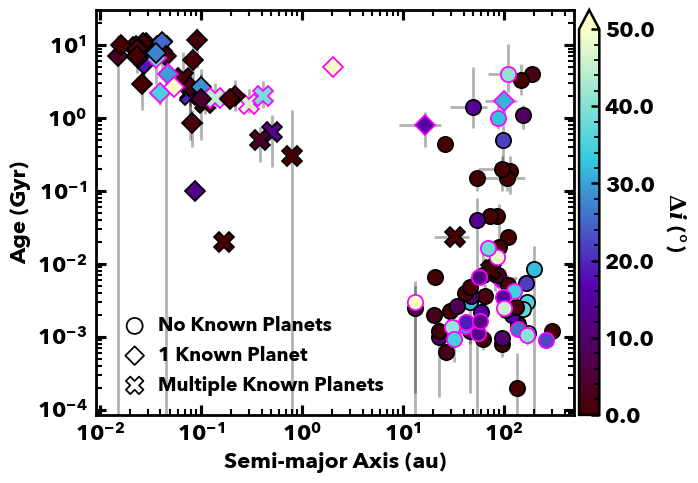

In [124]:
fig = plt.figure(figsize=(5.5, 5), dpi=100)
ax = fig.add_axes(111)
ax.minorticks_on()
ax.set_xlabel('Semi-major Axis (au)', fontsize=16, weight='semibold') # , labelpad=8)
ax.set_ylabel('Age (Gyr)', fontsize=16, weight='semibold') # , labelpad=8)
# ax.yaxis.label.set_family("DejaVu Serif")
# ax.set_ylabel(r'$\mathit{\Delta i}$ ($\degree$)', fontsize=16, weight='semibold') # , labelpad=8)

edge_color = "#000000"

print('Median Ages: ')

age_progression_dataset_order = ['PD', 'DD', 'WJ', 'HJ']

for which_dataset in age_progression_dataset_order:

    if which_dataset == 'PD':
        plot_df = df_PD
        dataset_point_color = pd_color
        aligned_color = '#b0e8e8'
        misaligned_color = '#004d4d'
        multis_list = PD_multis
        singles_list = PD_singles
        with_planets_list = PD_with_planets
        z_order_base = -2
        x_key = 'Rdisk (au)'
        x_key_m = 'Rdisk -Unc'
        x_key_p = 'Rdisk -Unc'
        print(f"{which_dataset}: {np.median(plot_df['Age (Myr)'].values):.2f} Myr")
    if which_dataset == 'DD':
        plot_df = df_DD
        dataset_point_color = dd_color
        aligned_color = '#87c5a6'
        misaligned_color = '#214534'
        multis_list = DD_multis
        singles_list = DD_singles
        with_planets_list = DD_with_planets
        z_order_base = -8
        x_key = 'Rdisk (au)'
        x_key_m = 'Rdisk -Unc'
        x_key_p = 'Rdisk -Unc'
        print(f"{which_dataset}: {np.median(plot_df['Age (Myr)'].values):.2f} Myr")
    if which_dataset == 'WJ':
        plot_df = df_WJ
        dataset_point_color = WJ_color
        aligned_color = '#ffe9b3'
        misaligned_color = '#805b00'
        multis_list = WJ_multis
        singles_list = WJ_singles
        with_planets_list = WJ_with_planets
        z_order_base = -11
        x_key = 'a/Rstar'
        x_key_m = 'a/Rstar -Unc'
        x_key_p = 'a/Rstar +Unc'
        print(f"{which_dataset}: {np.median(np.array(plot_df['Age (Myr)'].values) * 1e-3):.2f} Gyr")
    if which_dataset == 'HJ':
        plot_df = df_HJ
        dataset_point_color = HJ_color
        aligned_color = '#cf70db'
        misaligned_color = '#5a0066'
        multis_list = HJ_multis
        singles_list = HJ_singles
        with_planets_list = HJ_with_planets
        z_order_base = -5
        x_key = 'a/Rstar'
        x_key_m = 'a/Rstar -Unc'
        x_key_p = 'a/Rstar +Unc'
        print(f"{which_dataset}: {np.median(np.array(plot_df['Age (Myr)'].values) * 1e-3):.2f} Gyr")

    targets_list = np.array(plot_df['Target'].values)

    

    x_data1 = np.array(plot_df[x_key].values)
    x_data = []
    x_err_m = []
    x_err_p = []

    if which_dataset == 'PD':
        x_data = np.array(plot_df[x_key].values)
        x_err_m = np.array(plot_df[x_key_m].values)
        x_err_p = np.array(plot_df[x_key_p].values)
    elif which_dataset == 'DD':
        delta_x = plot_df['Delta Rdisk (au)'].values
        for delta_Rdisk_i, delta_Rdisk in enumerate(delta_x):
            x_data.append(float(plot_df[x_key].values[delta_Rdisk_i]))
            if delta_Rdisk_i == 0:
                x_err_m.append(float(plot_df['Delta Rdisk -Unc'].values[delta_Rdisk_i]))
                x_err_p.append(float(plot_df['Delta Rdisk +Unc'].values[delta_Rdisk_i]))
            else:
                x_err_m.append(float(0.5 * delta_x[delta_Rdisk_i]))
                x_err_p.append(float(0.5 * delta_x[delta_Rdisk_i]))
    else:
        for separation_i, separation in enumerate(x_data1):
            x_data.append(float(separation * (np.array(plot_df['Rstar (Rsun)'].values[separation_i]) * u.Rsun).to(u.au).value))
            x_err_m.append(float(plot_df[x_key_m].values[separation_i] * (np.array(plot_df['Rstar (Rsun)'].values[separation_i])*u.Rsun).to(u.au).value))
            x_err_p.append(float(plot_df[x_key_p].values[separation_i] * (np.array(plot_df['Rstar (Rsun)'].values[separation_i])*u.Rsun).to(u.au).value))


    y_data = np.array(plot_df['Age (Myr)'].values) * 1e-3
    y_err_m = np.array(plot_df['Age -Unc'].values) * 1e-3
    y_err_p = np.array(plot_df['Age +Unc'].values) * 1e-3

    z_data = np.array(plot_df['disk diff'].values)
    z_err_m = np.array(plot_df['disk diff -Unc'].values)
    z_err_p = np.array(plot_df['disk diff +Unc'].values)

    z_norm = plt.Normalize(0, 50)
    colormap = choose_cmap('raspberry punch2', reverse_cmap=False)
    point_colors = [colormap(z_norm(bep)) for bep in z_data]

    for bep_i in range(len(z_data)):

        point_edge_color = '#000000'
        point_edge_width = 1.25

        if targets_list[bep_i] in with_planets_list:
            point_shape = 'D'
            point_size_number = 10
            if targets_list[bep_i] in multis_list:
                point_shape = 'X'
                point_size_number = 14
                z_order_number = z_order_base - 1
        else:
            point_shape = 'o'
            point_size_number = 11
            z_order_number = z_order_base - 2

        target_str = targets_list[bep_i].replace(' ', '')
        if target_str not in misaligned_lists[which_dataset]['ALL']:
            point_color = aligned_color
        else:
            point_edge_color = "#FF00FF"
            z_order_number = z_order_base

        point_color = point_colors[bep_i]  # dataset_point_color  # misaligned_color
        

        ax.errorbar(x_data[bep_i], y_data[bep_i],
                    xerr=[[x_err_m[bep_i]], [x_err_p[bep_i]]],
                    yerr=[[y_err_m[bep_i]], [y_err_p[bep_i]]],
                    marker=point_shape, mfc=point_color, mec=point_edge_color, ms=point_size_number, mew=point_edge_width,
                    elinewidth=0, linewidth=0, capsize=0, ecolor='#000000', capthick=0, zorder=z_order_number)
        ax.errorbar(x_data[bep_i], y_data[bep_i],
                    xerr=[[x_err_m[bep_i]], [x_err_p[bep_i]]],
                    yerr=[[y_err_m[bep_i]], [y_err_p[bep_i]]],
                    marker=point_shape, mfc='None', mec='None', ms=point_size_number, mew=0,
                    elinewidth=2, linewidth=0, capsize=0, ecolor='#000000', capthick=0, alpha=0.3, zorder=z_order_number-20)

cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=z_norm, cmap=colormap), ax=ax, use_gridspec=True, shrink=1., fraction=0.05, pad=0.01, extend='max')  # location='top', 
# cbar.yaxis.label.set_family("DejaVu Serif")
cbar.set_label(r'$\mathit{\Delta i}$ ($\degree$)', labelpad=24, rotation=270, fontsize=16, weight='semibold')
cbar_ticks = cbar.get_ticks() # np.arange(0, 105, 15)
cbar.set_ticks(cbar_ticks)
cbar_ticklabels = [str(cbar_tick) for cbar_tick in cbar_ticks]
cbar.set_ticklabels(cbar_ticklabels, fontsize=16)
cbar.minorticks_on()

ax.scatter([], [], color='None', edgecolors='#000000', marker='o', linewidth=1.25, s=np.pi*6.5**2, linestyle='None', zorder=-4, label='No Known Planets')
ax.scatter([], [], color='None', edgecolors='#000000', marker='D', linewidth=1.25, s=90, linestyle='None', zorder=-4, label='1 Known Planet')
ax.scatter([], [], color='None', edgecolors='#000000', marker='X', linewidth=1.25, s=160, linestyle='None', zorder=-4, label='Multiple Known Planets')

xlims = 5e-4, 14 # , 1.5e-4, 15

# ax.set_xlim(xlims)
# ax.set_ylim(-1, 70)

# xticks = (1e-3, 1e-2, 1e-1, 1e0, 1e1)
# ax.set_xticks(xticks)
# ax.set_xticklabels(xticks, fontsize=16)

ax.set_xscale('log')
ax.set_yscale('log')

ax.tick_params(axis='x', which='major', labelsize=16, length=7, width=2.25, pad=6)
ax.tick_params(axis='y', which='major', labelsize=16, length=7, width=2.25, pad=6)
ax.tick_params(axis='x', which='minor', length=4, width=1.5)
ax.tick_params(axis='y', which='minor', length=4, width=1.5)

for spine1 in ax.spines.values():
        spine1.set_linewidth(2)

# ax.legend(loc='upper left', ncol=4, handletextpad=0.2, frameon=False, framealpha=1, bbox_to_anchor=(-0.12, 1.12), fontsize=13)
ax.legend(loc='lower left', ncol=1, handletextpad=0.2, frameon=False, framealpha=1, fontsize=14)

# label_y = 1 - 0.87

# PD_xy = 0.04, label_y
# DD_xy = PD_xy[0] + 0.06, label_y
# WJ_xy = PD_xy[0] + 0.125, label_y
# HJ_xy = PD_xy[0] + 0.19, label_y

# ax.text(PD_xy[0], PD_xy[1], 'PD', color=pd_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax.transAxes)
# ax.text(DD_xy[0], DD_xy[1], 'DD', color=dd_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax.transAxes)
# ax.text(WJ_xy[0], WJ_xy[1], 'WJ', color=WJ_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax.transAxes)
# ax.text(HJ_xy[0], HJ_xy[1], 'HJ', color=HJ_color, horizontalalignment='left', verticalalignment='bottom', fontsize=18, transform=ax.transAxes)

# # 2. Define rectangle parameters
# # Anchor at (1.5, 2.0), width 2.0, height 1.5
# bottom_left_xy = PD_xy[0]-0.01, PD_xy[1]-0.01
# width = HJ_xy[0] + 0.04 - PD_xy[0] + 0.02
# height = 0.09

# # 3. Create a Rectangle patch (hollow with red edge)
# rect = mpl.patches.Rectangle(
#     bottom_left_xy,
#     width,
#     height,
#     linewidth=1,
#     edgecolor='#000000',
#     facecolor='none',
#     transform=ax.transAxes
# )

# ax.add_patch(rect)

plt.subplots_adjust(bottom=0.12, top=0.93, left=0.065, right=0.99)

# SAVE THE FIGURE
save_age_vs_Deltai_string = 'Separation_vs_Deltai_' + date_str + '.pdf'

fig.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/' + save_age_vs_Deltai_string, dpi=300, transparent=False)

plt.show()
plt.close()


In [79]:
df_DD_young = df_DD[df_DD['Age (Myr)'].values < np.median(df_DD['Age (Myr)'].values)]
df_DD_old = df_DD[df_DD['Age (Myr)'].values >= np.median(df_DD['Age (Myr)'].values)]
mean_young = np.mean(df_DD_young['disk diff'].values)
std_young = np.std(df_DD_young['disk diff'].values)
mean_old = np.mean(df_DD_old['disk diff'].values)
std_old = np.std(df_DD_old['disk diff'].values)
snr = (abs(mean_young - mean_old)) / (np.sqrt(std_young**2 + std_old**2))

print('N young: ', len(df_DD_young['disk diff'].values))
print('N old: ', len(df_DD_old['disk diff'].values))
print(' ')
print(f'Average Deltai of Debris disks < {np.median(df_DD['Age (Myr)'].values):.1f} Myr: {mean_young:.1f} +/- {std_young:.1f} deg')
print(f'Average Deltai of Debris disks >= {np.median(df_DD['Age (Myr)'].values):.1f} Myr: {mean_old:.1f} +/- {std_old:.1f} deg')  
print(f'S/N of difference between young and old debris disk Deltai: {snr:.1f}')




N young:  11
N old:  12
 
Average Deltai of Debris disks < 190.0 Myr: 3.7 +/- 6.7 deg
Average Deltai of Debris disks >= 190.0 Myr: 14.0 +/- 14.0 deg
S/N of difference between young and old debris disk Deltai: 0.7


pd_color #00cccc
dd_color #336b4f
wj_color #ffb800
hj_color #9000a3
49
23
20
20


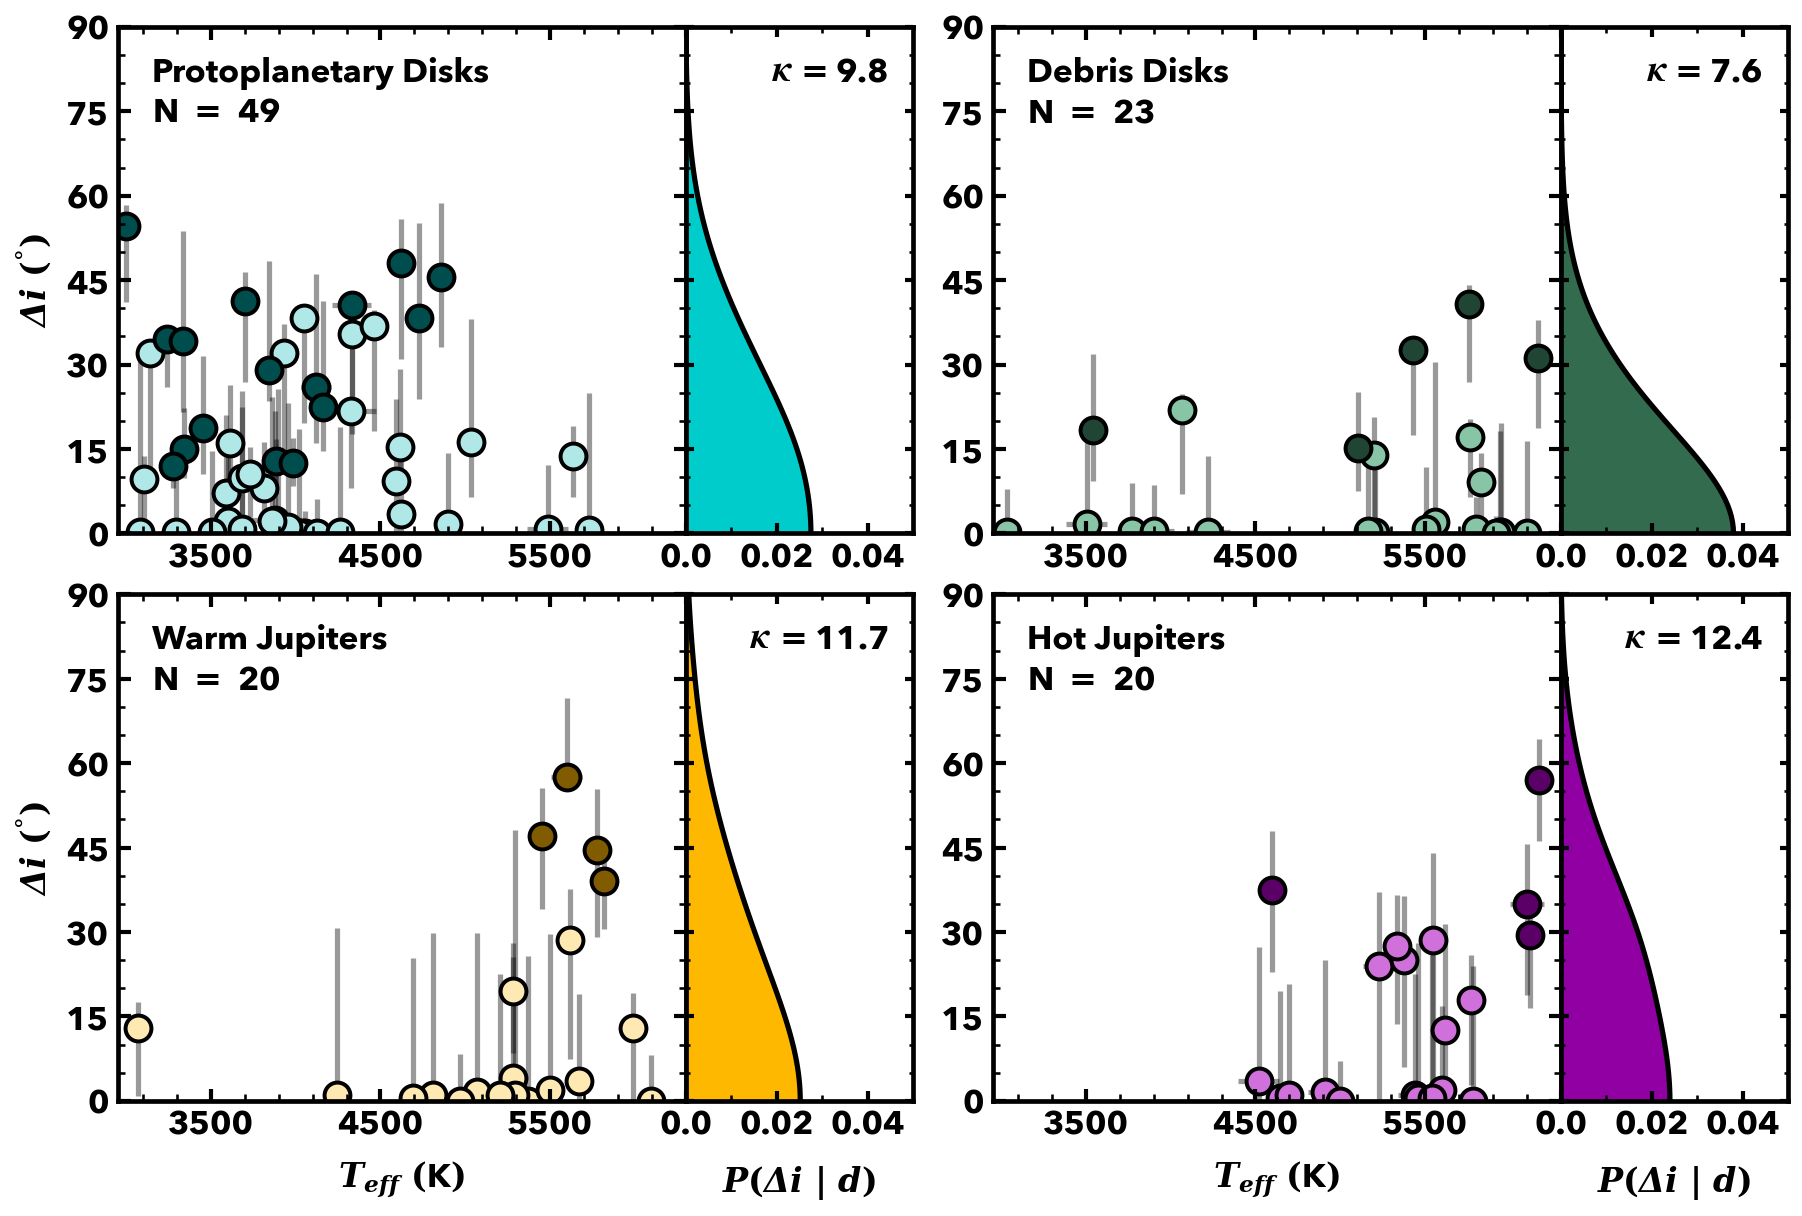

In [68]:

plt.rcParams['mathtext.default'] = 'bfit'

x_column = 'SpType Decimal'
x_column = 'Teff (K)'

if x_column == 'SpType Decimal':
    x_column_err_p = 'SpType Decimal Unc'
    x_column_err_m = 'SpType Decimal Unc'
    x_label = 'SpType'
    xlims = [2.25, 5.75]
    x_text = 'SpT'

if x_column == 'Teff (K)':
    x_column_err_p = 'Teff Unc'
    x_column_err_m = 'Teff Unc'
    x_label = r'$T_{eff}~\mathrm{(}$K$\mathrm{)}$'
    xlims = [2950, 6300]
    dx1 = 1000
    x_text = 'Teff'

y_column = 'disk diff'
y_column_err_p = 'disk diff +Unc'
y_column_err_m = 'disk diff -Unc'
y_label = r'$\Delta i$ ($^\degree$)'
ylims = [-2, 90]
y_text = 'Delta_i'

z_column = 'i star (deg)'
z_column_err_p = 'i star -Unc'
z_column_err_m = 'i star +Unc'
z_label = r'$i_{*}$ ($^\degree$)'
zlims = [0, 90]
z_text = 'i_Star'

parameter_z_norm = plt.Normalize(zlims[0], zlims[1])


datasets = ['PD', 'DD', 'WJ', 'HJ']




fig = plt.figure(figsize=(12, 8))
axes = fig.subplot_mosaic(
    """
    ab.cd
    ef.gh
    """,
    gridspec_kw={'height_ratios': [1, 1], 'width_ratios': [1, 0.4, 0.14, 1, 0.4], "bottom": 0.085, "top": 0.98, "left": 0.062, "right": 0.99, "wspace": 0.0, "hspace": 0.12}
)

print('pd_color', pd_color)
print('dd_color', dd_color)
print('wj_color', WJ_color)
print('hj_color', HJ_color)

for which_dataset in datasets:


    if which_dataset == 'PD':
        plot_df = df_PD
    if which_dataset == 'DD':
        plot_df = df_DD
    if which_dataset == 'WJ':
        plot_df = df_WJ
    if which_dataset == 'HJ':
        plot_df = df_HJ

    parameter_x = np.array(plot_df[x_column].values)
    parameter_x_err_p = np.array(plot_df[x_column_err_p].values)
    parameter_x_err_m = np.array(plot_df[x_column_err_m].values)
    parameter_y = np.array(plot_df[y_column].values)
    parameter_y_err_p = np.array(plot_df[y_column_err_p].values)
    parameter_y_err_m = np.array(plot_df[y_column_err_m].values)
    parameter_z = np.array(plot_df[z_column].values)
    parameter_z_err_p = np.array(plot_df[z_column_err_p].values)
    parameter_z_err_m = np.array(plot_df[z_column_err_m].values)
    targets_list = np.array(plot_df['Target'].values)

    parameter_x_err = [parameter_x_err_m, parameter_x_err_p]
    parameter_y_err = [parameter_y_err_m, parameter_y_err_p]
    parameter_z_err = [parameter_z_err_m, parameter_z_err_p]

    if which_dataset == 'PD':
        dataset_type = 'Protoplanetary Disks'
        dataset_author = '(Biddle et al. 2025)'
        # colormap = choose_cmap('primordial disks', reverse_cmap=False)
        kde_color = pd_color
        aligned_color = '#b0e8e8'
        misaligned_color = '#004d4d'
        kde_linecolor = pd_linecolor
        dx2 = 0.02
        kde_alpha = 1
        density_estimation_total_positive_x = density_estimation_total_positive_x_PD
        if x_column == 'SpType Decimal':
            x2min = dx2
        if x_column == 'Teff (K)':
            x2min = 0.0
        ax_letters = ['a', 'b']
        ax2_bandwidth = band_width_PD
        multis_list = PD_multis

    if which_dataset == 'DD':
        dataset_type = 'Debris Disks'
        dataset_author = r'(Hurt & MacGregor 2023)'
        # colormap = choose_cmap('debris disks', reverse_cmap=False)
        kde_color = dd_color
        aligned_color = '#87c5a6'
        misaligned_color = '#214534'
        kde_linecolor = dd_linecolor
        dx2 = 0.02
        kde_alpha = 1
        density_estimation_total_positive_x = density_estimation_total_positive_x_DD
        if x_column == 'SpType Decimal':
            x2min = dx2
        if x_column == 'Teff (K)':
            x2min = 0.0
        ax_letters = ['c', 'd']
        ax2_bandwidth = band_width_DD
        multis_list = DD_multis

    if which_dataset == 'WJ':
        dataset_type = 'Warm Jupiters'
        dataset_author = '(Morgan et al. 2024)'
        # colormap = choose_cmap('warm jupiters', reverse_cmap=False)
        kde_color = WJ_color
        aligned_color = '#ffe9b3'
        misaligned_color = '#805b00'
        kde_linecolor = WJ_linecolor
        dx2 = 0.02
        kde_alpha = 1
        density_estimation_total_positive_x = density_estimation_total_positive_x_WJ
        if x_column == 'SpType Decimal':
            x2min = dx2
        if x_column == 'Teff (K)':
            x2min = 0.0
        ax_letters = ['e', 'f']
        ax2_bandwidth = band_width_WJ
        multis_list = WJ_multis

    if which_dataset == 'HJ':
        dataset_type = 'Hot Jupiters'
        dataset_author = '(Morgan et al. 2024)'
        # colormap = plt.get_cmap('bone')
        kde_color = HJ_color
        aligned_color = '#cf70db'
        misaligned_color = '#5a0066'
        kde_linecolor = HJ_linecolor
        dx2 = 0.02
        kde_alpha = 1
        density_estimation_total_positive_x = density_estimation_total_positive_x_HJ
        if x_column == 'SpType Decimal':
            x2min = dx2
        if x_column == 'Teff (K)':
            x2min = 0.01
        ax_letters = ['g', 'h']
        ax2_bandwidth = band_width_HJ
        multis_list = HJ_multis


    err_alpha = 0.4

    grid_height = 2
    grid_width = 2

    original_fig_width = 8
    original_fig_height = 6.5

    original_width_ratios = [1, 0.40]
    original_height_ratios = [0.05, 1]


    fig_width = 8.25
    fig_height = 5.80

    try_width_ratios = [1, 0.65]
    try_height_ratios = [0.05, 1]


    single_parplot_fontsize = 16

    target_labels_on = False

    point_size = 7

    z_colors_on = True

    include_HBM_models = True

    zorder_shift = 10
    



    # fig = plt.figure(figsize=(fig_width, fig_height), dpi=150)
    # gs = gridspec.GridSpec(grid_height , grid_width , width_ratios=try_width_ratios, height_ratios=try_height_ratios)
    # axes = [fig.add_subplot(gs[ii, jj]) for ii in range(grid_height) for jj in range(grid_width)]
    # cbar_ax = axes[0]
    # blank_ax = axes[1]
    ax1 = axes[ax_letters[0]]
    ax2 = axes[ax_letters[1]]


    # MAKE INVISIBLE AXES SPINES
    for spine1 in ax1.spines.values():
        spine1.set_linewidth(2.25)
    for spine2 in ax2.spines.values():
        spine2.set_linewidth(2.25)



    ax1.minorticks_on()
    ax2.minorticks_on()

    if ax_letters[0] == 'e' or ax_letters[0] == 'g':
        ax1.set_xlabel(x_label, fontsize=single_parplot_fontsize, labelpad=8)
        ax2.set_xlabel(r'$P\mathrm{(}\Delta i~|~d\mathrm{)}$', fontsize=single_parplot_fontsize, labelpad=10)
    if ax_letters[0] == 'a' or ax_letters[0] == 'e':
        ax1.set_ylabel(r'$\Delta i~\mathrm{(}^\degree\mathrm{)}$', fontsize=single_parplot_fontsize, labelpad=6)


    # point_colors = [colormap(parameter_z_norm(bep)) for bep in parameter_z]
    # point_edgecolors = [kde_linecolor]*len(point_colors)  # [edge_color]*len(point_colors)
    # if z_colors_on == True:
    #     point_colors = [colormap(parameter_z_norm(bep)) for bep in parameter_z]
    # else:
    #     point_colors = [point_color_no_z]*len(point_colors)

    point_colors = [kde_color] * len(parameter_y)

    print(len(parameter_y))

    # misaligned_color = '#841568'

    # -------------------------------------- THE SAMPLE ---------------------------------------  #
    for par_i in range(0, len(parameter_y)):
        if parameter_z[par_i] == 90.0:
            zord = -4
        if parameter_z[par_i] < 90:
            zord = -1
        if targets_list[par_i] in multis_list:
            # point_shape = 'D'
            # point_size_number = 120
            point_shape = 'o'
            point_size_number = np.pi*point_size**2
        else:
            point_shape = 'o'
            point_size_number = np.pi*point_size**2

        if targets_list[par_i].replace(' ', '') in misaligned_lists[which_dataset]['ALL']:
            point_color = misaligned_color # kde_color
        else:
            point_color = aligned_color # '#ffffff'
            
        edge_color = '#000000'
        
        # print([parameter_x[par_i]], [parameter_y[par_i]])
        ax1.scatter([parameter_x[par_i]], [parameter_y[par_i]], marker=point_shape, color=point_color, edgecolors=edge_color, linewidth=1.9, s=point_size_number, linestyle='None', zorder=zord)
        ax1.errorbar([parameter_x[par_i]], [parameter_y[par_i]], xerr=[[parameter_x_err[0][par_i]],[parameter_x_err[1][par_i]]], yerr=[[parameter_y_err[0][par_i]], [parameter_y_err[1][par_i]]],
                    elinewidth=2.5, linewidth=0, capsize=0, ecolor=edge_color, capthick=0, zorder=-5, alpha=err_alpha)
    # ---------------------------------------------------------------------------------------- #


    # ------------------------------ KERNEL DENSITY ESTIMATION ------------------------------- #
    kde_fill_color = kde_color
    ax2.fill_between(density_estimation_total_positive_x, x_grid_plot, color=kde_fill_color, alpha=1, label='Gaussian KDE', zorder=1-zorder_shift)
    ax2.plot(density_estimation_total_positive_x, x_grid_plot, color='#000000', linewidth=2.5, alpha=1, zorder=1-zorder_shift+1)
    # ---------------------------------------------------------------------------------------- #


    # ---------------------------------------- THE SUN ---------------------------------------  #
    Solar_SpType = 4.98  # 4.6
    Solar_SpType_err = 0.1
    Solar_obliquity = 7.155
    Solar_obliquity_err = 0.002
    Solar_point_size = 750

    sun_color = '#ffff80'  # '#ace600'
    sun_edgecolor = '#26004d'  # '#001a33'
    ax1.scatter([Solar_SpType], [Solar_obliquity], marker='*', color=sun_color, edgecolors=sun_edgecolor, linewidth=2.5, s=Solar_point_size, linestyle='None')  # , label='The Pre-main Sequence Sun')
    # ax1.errorbar([Solar_SpType], [Solar_obliquity], xerr=[Solar_SpType_err], yerr=[Solar_obliquity_err], elinewidth=3, linewidth=0, capsize=0, ecolor='#001a33', capthick=0, zorder=-1)   
    # ---------------------------------------------------------------------------------------- #

    for spine in ax2.spines.values():
        spine.set_zorder(100)


    if x_column == 'SpType Decimal':
        sptype_designations = {'0': 'B',
                            '0.5': 'B5',
                            '1': 'A0',
                            '1.5': 'A5',
                            '2': 'F0',
                            '2.5': 'F5',
                            '3': 'G0',
                            '3.5': 'G5',
                            '4': 'K0',
                            '4.5': 'K5',
                            '5': 'M0',
                            '5.5': 'M5',
                            }

        xtickvals = [2.5, 3., 3.5, 4, 4.5, 5, 5.5]  # np.arange(xlims[0], xlims[1]+0.25, 0.25)
        xticklabs = []
        xticks = []
        for xtick in xtickvals:
            if xtick < xlims[1]:
                if (np.mod(xtick,1) == 0) and (xtick >= xlims[0]):
                    xticks.append(xtick)
                    xticklabs.append(sptype_designations[str(int(xtick))])
                elif (np.mod(xtick,0.5) == 0) and (xtick >= xlims[0]):
                    xticks.append(xtick)
                    xticklabs.append(sptype_designations['{:.1f}'.format(xtick)])
        ax1.set_xticks(xticks)
        xticklabels = ax1.set_xticklabels(xticklabs, fontsize=single_parplot_fontsize)

    if x_column == 'Teff (K)':
        xticks = [3500, 4500, 5500]
        if ax_letters[0] == 'e' or ax_letters[0] == 'g' or ax_letters[0] == 'a' or ax_letters[0] == 'c':
            ax1.set_xticks(xticks)
            xticklabels = ax1.set_xticklabels(xticks, fontsize=single_parplot_fontsize)
        # if ax_letters[0] == 'a' or ax_letters[0] == 'c': 
            # ax1.set_xticks(xticks)
            # xticklabels = ax1.set_xticklabels([], fontsize=single_parplot_fontsize)


    x2lim = 0.05  # 1.15 * max(density_estimation_total_positive_x)
    ax2_xtickvals = [0.0, 0.02, 0.04]
    if ax_letters[1] == 'f' or ax_letters[1] == 'h' or ax_letters[1] == 'b' or ax_letters[1] == 'd':
        ax2.set_xticks(ax2_xtickvals)
        ax2_xtickvals = ['0.0', '0.02', '0.04']
        ax2.set_xticklabels(ax2_xtickvals, fontsize=single_parplot_fontsize)


    ytickvals_major = np.arange(0, 105, 15)
    yticks_major = [int(ytick) for ytick in ytickvals_major]
    ax1.set_yticks(yticks_major, minor=False)
    ax2.set_yticks(yticks_major, minor=False)
    if ax_letters[0] == 'a' or ax_letters[0] == 'e' or ax_letters[0] != 'a' and ax_letters[0] != 'e':
        yticklabels = ax1.set_yticklabels(yticks_major, fontsize=single_parplot_fontsize)
        ax2.set_yticklabels([]) 


    xticks_minor1 = AutoMinorLocator(5)
    ax1.xaxis.set_minor_locator(xticks_minor1)
    xticks_minor2 = AutoMinorLocator(2)
    ax2.xaxis.set_minor_locator(xticks_minor2)
    yticks_minor = AutoMinorLocator(3)
    ax1.yaxis.set_minor_locator(yticks_minor)
    ax2.yaxis.set_minor_locator(yticks_minor)


    ax1.set_xlim(xlims)
    ax1.set_ylim(0, 90)
    ax2.set_ylim(0, 90)
    ax2.set_xlim(0, x2lim)

    ax1.set_rasterized(True)

    ax1.tick_params(which='major', length=6, width=2, pad=4)
    ax1.tick_params(which='minor', length=3.5, width=1.25)

    ax2.tick_params(labelsize=single_parplot_fontsize)

    ax2.tick_params(axis='x', which='major', length=5, width=2, pad=4)
    ax2.tick_params(axis='x', which='minor', length=3, width=1.25)
    ax2.tick_params(axis='y', which='major', length=4, width=2, pad=4)
    ax2.tick_params(axis='y', which='minor', length=2, width=1.25)




    # ax2.text(0.50, 0.92, dataset_type, horizontalalignment='center', verticalalignment='center', fontsize=single_parplot_fontsize, transform=ax2.transAxes)
    # ax2.text(0.50, 0.86, dataset_author, horizontalalignment='center', verticalalignment='center', fontsize=0.8*single_parplot_fontsize, transform=ax2.transAxes)

    ax1.text(0.06, 0.91, dataset_type, horizontalalignment='left', verticalalignment='center', fontsize=single_parplot_fontsize, transform=ax1.transAxes)
    # ax1.text(0.06, 0.86, dataset_author, horizontalalignment='left', verticalalignment='center', fontsize=0.8*single_parplot_fontsize, transform=ax1.transAxes)
    ax1.text(0.06, 0.83, r"N $=$ {:d}".format(len(parameter_y)), horizontalalignment='left', verticalalignment='center', fontsize=single_parplot_fontsize, transform=ax1.transAxes)

    # ax2.text(0.89, 0.91, r'$\kappa = $' + str(np.round(ax2_bandwidth, 1)), horizontalalignment='right', verticalalignment='center', fontsize=single_parplot_fontsize, transform=ax2.transAxes)


    mpl.rcParams['mathtext.fontset'] = 'stix'
    if which_dataset == 'PD' or which_dataset == 'DD':
        ax2.text(0.475, 0.915, r'$\kappa$', horizontalalignment='right', verticalalignment='center', fontsize=single_parplot_fontsize+2, transform=ax2.transAxes, color='#000000')
    else:
        ax2.text(0.38, 0.915, r'$\kappa$', horizontalalignment='right', verticalalignment='center', fontsize=single_parplot_fontsize+2, transform=ax2.transAxes, color='#000000')
    mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
    ax2.text(0.89, 0.91, r"$=$" + str(np.round(ax2_bandwidth, 1)), horizontalalignment='right', verticalalignment='center', fontsize=single_parplot_fontsize, transform=ax2.transAxes, weight='semibold', color='#000000')


    # fig.subplots_adjust(left=0.085, bottom=0.11, right=0.99, top=0.89, wspace=0.02, hspace=0.02)
    # labels_text = 'bep'


# SAVE THE FIGURE
save_par_vs_Deltai_string = 'Teff_vs_Deltai_Quadrants_' + date_str + '.pdf'

fig.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/' + save_par_vs_Deltai_string, dpi=300, transparent=False)

plt.show()
plt.close()

In [69]:
df_WJ['Target'].values

array(['K2-139', 'K2-281', 'K2-329', 'K2-77', 'Kepler-1654', 'Kepler-27',
       'Kepler-28', 'Kepler-289', 'Kepler-30', 'Kepler-447', 'Kepler-468',
       'Kepler-51', 'Kepler-52', 'Kepler-539', 'Kepler-75', 'Kepler-9',
       'TOI-1227', 'TOI-4562', 'V1298 Tau', 'WASP-84'], dtype=object)

9.646476067520407
7.572063958826088
11.667851227424999
12.422191297800001
mean Deltai uncertainty among all samples: 10.077104007732142


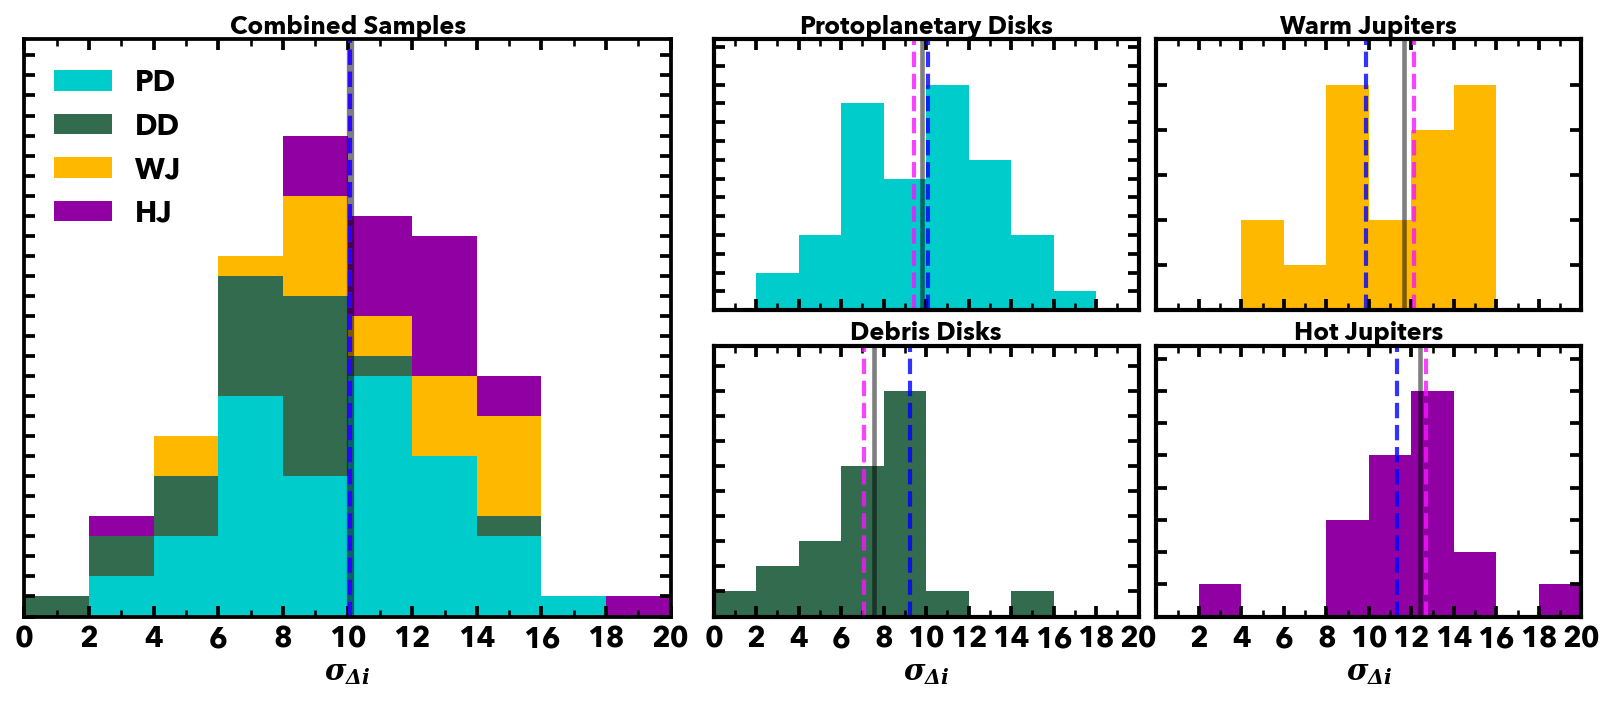

In [77]:
mean_Deltai_err_PD = (df_PD['disk diff +Unc'].values + df_PD['disk diff -Unc'].values) / 2.
mean_Deltai_err_DD = (df_DD['disk diff +Unc'].values + df_DD['disk diff -Unc'].values) / 2.
mean_Deltai_err_WJ = (df_WJ['disk diff +Unc'].values + df_WJ['disk diff -Unc'].values) / 2.
mean_Deltai_err_HJ = (df_HJ['disk diff +Unc'].values + df_HJ['disk diff -Unc'].values) / 2.

print(np.mean(mean_Deltai_err_PD))
print(np.mean(mean_Deltai_err_DD))
print(np.mean(mean_Deltai_err_WJ))
print(np.mean(mean_Deltai_err_HJ))

single_list = np.concatenate((mean_Deltai_err_PD, mean_Deltai_err_DD, mean_Deltai_err_WJ, mean_Deltai_err_HJ))
mean_sigma_Deltai_all = np.nanmean(single_list)

mean_aligned_sigmas_all = np.mean(np.concatenate((np.array(sigma_disk_diff_aligned['PD']), np.array(sigma_disk_diff_aligned['DD']), np.array(sigma_disk_diff_aligned['WJ']), np.array(sigma_disk_diff_aligned['HJ']))))
mean_misaligned_sigmas_all = np.mean(np.concatenate((np.array(sigma_disk_diff_misaligned['PD']), np.array(sigma_disk_diff_misaligned['DD']), np.array(sigma_disk_diff_misaligned['WJ']), np.array(sigma_disk_diff_misaligned['HJ']))))
mean_aligned_sigmas_PD = np.mean(np.array(sigma_disk_diff_aligned['PD']))
mean_misaligned_sigmas_PD = np.mean(np.array(sigma_disk_diff_misaligned['PD']))
mean_aligned_sigmas_DD = np.mean(np.array(sigma_disk_diff_aligned['DD']))
mean_misaligned_sigmas_DD = np.mean(np.array(sigma_disk_diff_misaligned['DD']))
mean_aligned_sigmas_WJ = np.mean(np.array(sigma_disk_diff_aligned['WJ']))
mean_misaligned_sigmas_WJ = np.mean(np.array(sigma_disk_diff_misaligned['WJ']))
mean_aligned_sigmas_HJ = np.mean(np.array(sigma_disk_diff_aligned['HJ']))
mean_misaligned_sigmas_HJ = np.mean(np.array(sigma_disk_diff_misaligned['HJ']))

aligned_sigma_color = "#F714FF"
misaligned_sigma_color = "blue" # "#D4FF00"
sigma_lineshape = '--'
sigma_linealpha = 0.8
sigma_linewidth = 2.


do_bins = np.arange(0, 22, 2)
ylim_max_factor = 1.20
text_ylim_fraction = 0.86
xlims = 0, 20
annotation_text_size = 10.5


print('mean Deltai uncertainty among all samples: ' + str(mean_sigma_Deltai_all))

fig = plt.figure(figsize=(10.7, 4.5), dpi=150)
axes = fig.subplot_mosaic(
    """
    zzz.aacc
    zzz.aacc
    zzz.bbdd
    zzz.bbdd
    """,
    gridspec_kw={'height_ratios': [0.5, 0.5, 0.5, 0.5], 'width_ratios': [1, 1, 1, 0.035, 1, 1, 1, 1], "bottom": 0.105, "top": 0.96, "left": 0.01, "right": 0.98, "wspace": 0.10, "hspace": 0.30,}
)

ax = axes['z']
ax.minorticks_off()
ax.set_title('Combined Samples', pad=1, fontsize=12)
ax.set_xlabel(r'$\sigma_{\Delta i}$', fontsize=14, labelpad=2)
hist_colors = [pd_color, dd_color, WJ_color, HJ_color]
hist_labels = ['PD', 'DD', 'WJ', 'HJ']
hist_stacks = [mean_Deltai_err_PD, mean_Deltai_err_DD, mean_Deltai_err_WJ, mean_Deltai_err_HJ]
counts, bins, patches = ax.hist(hist_stacks, align='mid', bins=do_bins, histtype='bar', stacked=True, color=hist_colors, lw=0, label=hist_labels)
ylims = 0, ylim_max_factor*max(np.reshape(np.array(counts), -1))
ax.set_ylim(ylims)
ax.set_xlim(xlims)
ax.plot([mean_sigma_Deltai_all, mean_sigma_Deltai_all], ylims, '-', color='#000000', lw=3.5, alpha=0.5)
ax.plot([mean_aligned_sigmas_all, mean_aligned_sigmas_all], ylims, ls=sigma_lineshape, color=aligned_sigma_color, lw=sigma_linewidth, alpha=sigma_linealpha)
ax.plot([mean_misaligned_sigmas_all, mean_misaligned_sigmas_all], ylims, ls=sigma_lineshape, color=misaligned_sigma_color, lw=sigma_linewidth, alpha=sigma_linealpha)
# ax.text(mean_sigma_Deltai_all+0.5, ax.get_ylim()[-1]*(text_ylim_fraction+0.05),
#         r'Average $\sigma_{\Delta i}$ = ' + str(np.round(mean_sigma_Deltai_all, 1)) + r'$\degree$',
#         horizontalalignment='left', fontsize=12)
ax.set_ylim(ylims)
ax.set_xlim(xlims)
xticks = np.arange(xlims[0], xlims[1] + 2, 2)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)
yticks = np.arange(ylims[0], ylims[1], 1)
ax.set_yticks(yticks)
ax.set_yticklabels([])
xticks_minor = AutoMinorLocator(2)
ax.xaxis.set_minor_locator(xticks_minor)
ax.legend(loc='upper left')

ax = axes['a']
ax.minorticks_off()
ax.set_title('Protoplanetary Disks', pad=1, fontsize=12)
counts, bins, patches = ax.hist(mean_Deltai_err_PD, align='mid', bins=do_bins, histtype='bar', stacked=True, color=pd_color, lw=0)
ylims = 0, ylim_max_factor*max(counts)
ax.set_ylim(ylims)
ax.set_xlim(xlims)
ax.plot([9.8, 9.8], ylims, '-', color='#000000', lw=2.2, alpha=0.5)
ax.plot([mean_aligned_sigmas_PD, mean_aligned_sigmas_PD], ylims, ls=sigma_lineshape, color=aligned_sigma_color, lw=sigma_linewidth, alpha=sigma_linealpha)
ax.plot([mean_misaligned_sigmas_PD, mean_misaligned_sigmas_PD], ylims, ls=sigma_lineshape, color=misaligned_sigma_color, lw=sigma_linewidth, alpha=sigma_linealpha)
# ax.text(9.8+0.3, ax.get_ylim()[-1]*text_ylim_fraction,
#         r'Average $\sigma_{\Delta i}$ = ' + str('9.8') + r'$\degree$',
#         horizontalalignment='left', fontsize=annotation_text_size)
xticks = np.arange(xlims[0], xlims[1] + 2, 2)
ax.set_xticks(xticks)
ax.set_xticklabels([])
yticks = np.arange(ylims[0], ylims[1], 1)
ax.set_yticks(yticks)
ax.set_yticklabels([])
xticks_minor = AutoMinorLocator(2)
ax.xaxis.set_minor_locator(xticks_minor)

for spine in ax.spines.values():
    spine.set_linewidth(2.0)

ax = axes['b']
ax.minorticks_off()
ax.set_title('Debris Disks', pad=1, fontsize=12)
ax.set_xlabel(r'$\sigma_{\Delta i}$', fontsize=14, labelpad=2)
counts, bins, patches = ax.hist(mean_Deltai_err_DD, align='mid', bins=do_bins, histtype='bar', stacked=True, color=dd_color, lw=0)
ylims = 0, ylim_max_factor*max(counts)
ax.set_ylim(ylims)
ax.set_xlim(xlims)
ax.plot([np.mean(mean_Deltai_err_DD), np.mean(mean_Deltai_err_DD)], ylims, '-', color='#000000', lw=2.2, alpha=0.5)
ax.plot([mean_aligned_sigmas_DD, mean_aligned_sigmas_DD], ylims, ls=sigma_lineshape, color=aligned_sigma_color, lw=sigma_linewidth, alpha=sigma_linealpha)
ax.plot([mean_misaligned_sigmas_DD, mean_misaligned_sigmas_DD], ylims, ls=sigma_lineshape, color=misaligned_sigma_color, lw=sigma_linewidth, alpha=sigma_linealpha)
# ax.text(np.mean(mean_Deltai_err_DD)+0.3, ax.get_ylim()[-1]*text_ylim_fraction,
#         r'Average $\sigma_{\Delta i}$ = ' + str(np.round(np.mean(mean_Deltai_err_DD), 1)) + r'$\degree$',
#         horizontalalignment='left', fontsize=annotation_text_size)
xticks = np.arange(xlims[0], xlims[1] + 2, 2)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)
yticks = np.arange(ylims[0], ylims[1], 1)
ax.set_yticks(yticks)
ax.set_yticklabels([])
xticks_minor = AutoMinorLocator(2)
ax.xaxis.set_minor_locator(xticks_minor)

for spine in ax.spines.values():
    spine.set_linewidth(2.0)

ax = axes['c']
ax.minorticks_off()
ax.set_title('Warm Jupiters', pad=1, fontsize=12)
# ax.set_xlabel(r'$\sigma_{\Delta i}$', fontsize=14)
counts, bins, patches = ax.hist(mean_Deltai_err_WJ, align='mid', bins=do_bins, histtype='bar', stacked=True, color=WJ_color, lw=0)
ylims = 0, ylim_max_factor*max(counts)
ax.set_ylim(ylims)
ax.set_xlim(xlims)
ax.plot([np.mean(mean_Deltai_err_WJ), np.mean(mean_Deltai_err_WJ)], ylims, '-', color='#000000', lw=2.2, alpha=0.5)
ax.plot([mean_aligned_sigmas_WJ, mean_aligned_sigmas_WJ], ylims, ls=sigma_lineshape, color=aligned_sigma_color, lw=sigma_linewidth, alpha=sigma_linealpha)
ax.plot([mean_misaligned_sigmas_WJ, mean_misaligned_sigmas_WJ], ylims, ls=sigma_lineshape, color=misaligned_sigma_color, lw=sigma_linewidth, alpha=sigma_linealpha)
# ax.text(np.mean(mean_Deltai_err_WJ)-0.2, ax.get_ylim()[-1]*text_ylim_fraction,
#         r'Average $\sigma_{\Delta i}$ = ' + str(np.round(np.mean(mean_Deltai_err_WJ), 1)) + r'$\degree$',
#         horizontalalignment='right', fontsize=annotation_text_size)
xticks = np.arange(xlims[0], xlims[1] + 2, 2)
ax.set_xticks(xticks)
ax.set_xticklabels([])
yticks = np.arange(ylims[0], ylims[1], 1)
ax.set_yticks(yticks)
ax.set_yticklabels([])
xticks_minor = AutoMinorLocator(2)
ax.xaxis.set_minor_locator(xticks_minor)

for spine in ax.spines.values():
    spine.set_linewidth(2.0)

ax = axes['d']
ax.minorticks_off()
ax.set_title('Hot Jupiters', pad=1, fontsize=12)
ax.set_xlabel(r'$\sigma_{\Delta i}$', fontsize=14, labelpad=2)
counts, bins, patches = ax.hist(mean_Deltai_err_HJ, align='mid', bins=do_bins, histtype='bar', stacked=True, color=HJ_color, lw=0)
ylims = 0, ylim_max_factor*max(counts)
ax.set_ylim(ylims)
ax.set_xlim(xlims)
ax.plot([np.mean(mean_Deltai_err_HJ), np.mean(mean_Deltai_err_HJ)], ylims, '-', color='#000000', lw=2.2, alpha=0.5)
ax.plot([mean_aligned_sigmas_HJ, mean_aligned_sigmas_HJ], ylims, ls=sigma_lineshape, color=aligned_sigma_color, lw=sigma_linewidth, alpha=sigma_linealpha)
ax.plot([mean_misaligned_sigmas_HJ, mean_misaligned_sigmas_HJ], ylims, ls=sigma_lineshape, color=misaligned_sigma_color, lw=sigma_linewidth, alpha=sigma_linealpha)
# ax.text(np.mean(mean_Deltai_err_HJ)-0.2, ax.get_ylim()[-1]*text_ylim_fraction,
#         r'Average $\sigma_{\Delta i}$ = ' + str(np.round(np.mean(mean_Deltai_err_HJ), 1)) + r'$\degree$',
#         horizontalalignment='right', fontsize=annotation_text_size)
xticks = np.arange(2, xlims[1] + 2, 2)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)
yticks = np.arange(ylims[0], ylims[1], 1)
ax.set_yticks(yticks)
ax.set_yticklabels([])
xticks_minor = AutoMinorLocator(2)
ax.xaxis.set_minor_locator(xticks_minor)

for spine in ax.spines.values():
    spine.set_linewidth(2.0)


plt.savefig('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Test_Figures/sigmaDi_precision_histograms.pdf')
plt.show()
plt.close()

single_list = np.concatenate((mean_Deltai_err_PD, mean_Deltai_err_DD, mean_Deltai_err_WJ, mean_Deltai_err_HJ))
mis_thres = np.round(np.nanmean(single_list))
# print('mean Deltai uncertainty among all samples: ' + str(np.nanmean(single_list)))

In [71]:
print(f'mean Deltai uncertainty ratio PD/DD: {np.mean(mean_Deltai_err_PD) / np.mean(mean_Deltai_err_DD):.2f}')
print(f'mean Deltai uncertainty ratio WJ/DD: {np.mean(mean_Deltai_err_WJ) / np.mean(mean_Deltai_err_DD):.2f}')
print(f'mean Deltai uncertainty ratio HJ/DD: {np.mean(mean_Deltai_err_HJ) / np.mean(mean_Deltai_err_DD):.2f}')




mean Deltai uncertainty ratio PD/DD: 1.27
mean Deltai uncertainty ratio WJ/DD: 1.54
mean Deltai uncertainty ratio HJ/DD: 1.64


2MASSJ04124068+2438157
2MASSJ11004022-7619280
2MASSJ16083070-3828268
AS209
BPTau
CIDA-7
DNTau
FTTau
IMLup
RXJ1615.3-3255
RXJ1842.9-3532
RXJ1852.3-3700
Sz114
TWHya
V836Tau
WSB52


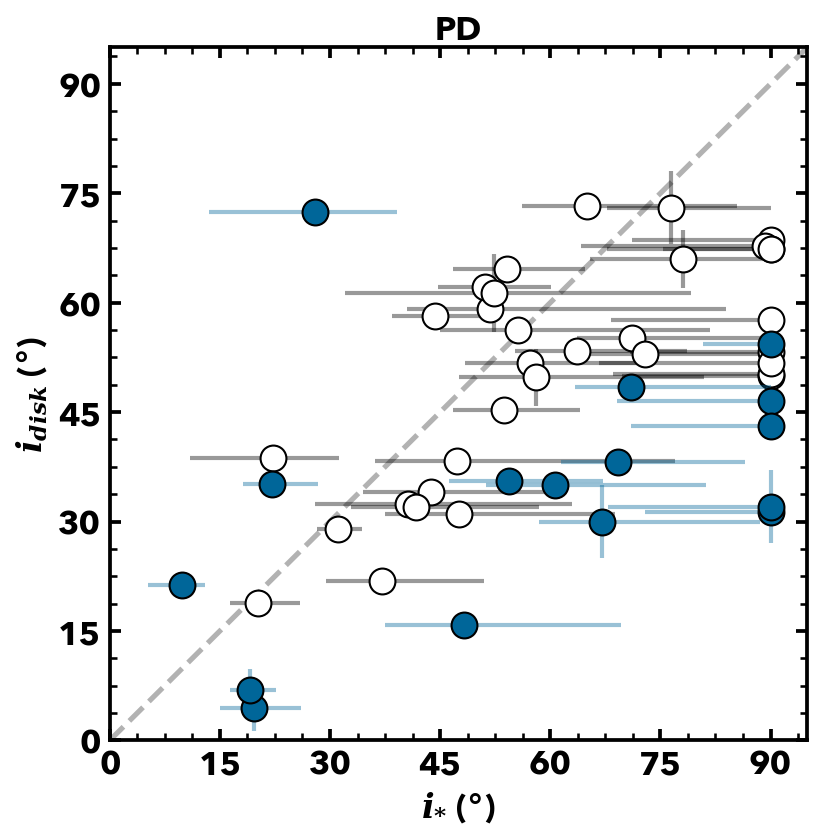

HD10647
HD38858
HD53143
TWA7
epsilonEridani


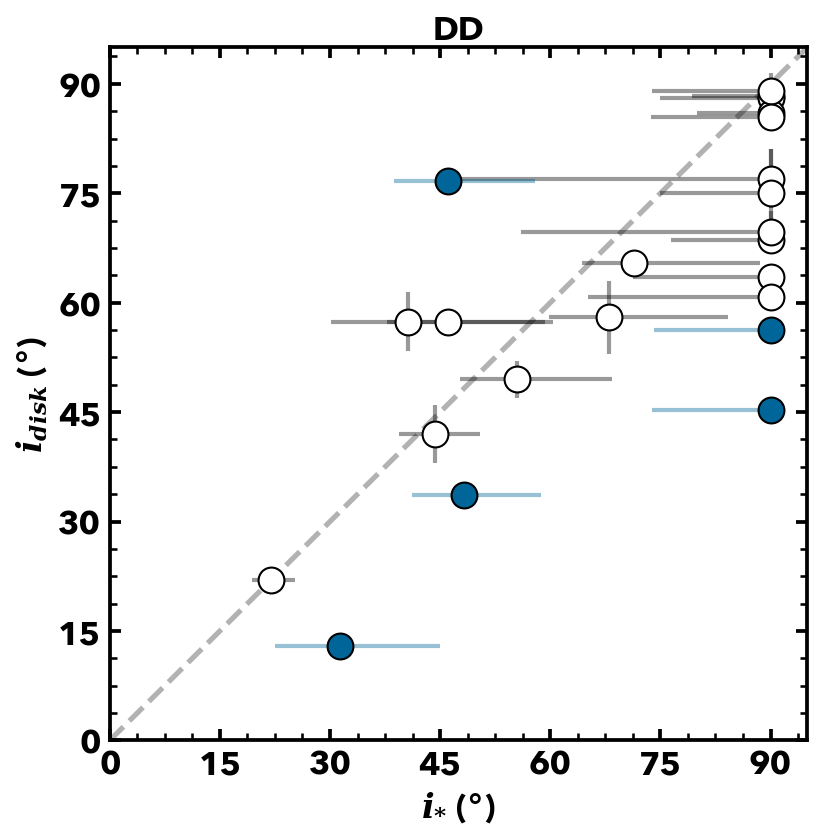

In [72]:

single_parplot_fontsize = 16
point_size = 7
edge_width = 1

colormap = choose_cmap('black limeaid', reverse_cmap=False)
# colormap = plt.set_cmap('managua')
# colormap = plt.set_cmap('BrBG')


which_misalignment_test = 'Individual Precision'  
# which_misalignment_test = '>10 deg'

do_colorbar = False

plot_istar_vs_idisk_list = ['PD', 'DD']


for which_dataset in plot_istar_vs_idisk_list:
    

    if which_misalignment_test == 'Individual Precision':
        misalignment_test_array = misaligned_lists[which_dataset]['ALL']
    if which_misalignment_test == '>10 deg':
        misalignment_test_array = misaligned_lists[which_dataset]['10 deg']

    if which_dataset == 'PD':
        plot_df = df_PD
    if which_dataset == 'DD':
        plot_df = df_DD
    if which_dataset == 'WJ':
        plot_df = df_WJ
    if which_dataset == 'HJ':
        plot_df = df_HJ


    fig = plt.figure(figsize=(6, 6), dpi=150)
    ax = fig.add_subplot(111)
    ax.minorticks_on()
    ax.set_title(which_dataset, fontsize=single_parplot_fontsize)
    ax.set_xlabel(r'$i_{*}$ ($\degree$)', fontsize=single_parplot_fontsize)
    ax.set_ylabel(r'$i_{disk}$ ($\degree$)', fontsize=single_parplot_fontsize)

    colorbar_norm = plt.Normalize(0, 60)
    point_colors = [colormap(colorbar_norm(bep)) for bep in plot_df['disk diff'].values]

    xmin, xmax = 0, 95
    ymin, ymax = 0, 95

    ax.plot([xmin, xmax], [ymin, ymax], '--', color='#000000', alpha=0.3, zorder=-150)


    for point_i in range(len(plot_df['Simbad Name'].values)):

        # print(' ')
        # print(plot_df['Simbad Name'].values[point_i])
        target_str = plot_df['Simbad Name'].values[point_i].replace(' ', '')
        # print(target_str)


        if do_colorbar == False:
            if target_str in misalignment_test_array:
                point_color = '#006699'
                point_ecolor = point_color
                print(target_str)
                # print(target_str , plot_df['Simbad Name'][point_i])
                # print('istar: ', plot_df['i star (deg)'][point_i])
                # print('idisk: ', plot_df['i disk (deg)'][point_i])
                # print('Delta i: ', plot_df['disk diff'][point_i], MAP_Delta_i)
                # print(' ')
                point_zorder = -1
            else:
                point_color = '#ffffff'
                point_ecolor = '#000000'
                point_zorder = -100
        if do_colorbar == True:
            point_color = point_colors[point_i]
            point_ecolor = '#000000'
            point_zorder = -1

        # print('istar uncertainties (-,+): ', plot_df['i star -Unc'][point_i], plot_df['i star +Unc'][point_i])
        # print('idisk uncertainty: ', plot_df['i disk Unc'][point_i])

        # print(type(plot_df['i disk (deg)'][point_i]))
        # print(plot_df['i disk (deg)'][point_i])

        if type(plot_df['i disk (deg)'].values[point_i]) != str:
            y_value = plot_df['i disk (deg)'].values[point_i]
            y_error = plot_df['i disk Unc'].values[point_i]
        if type(plot_df['i disk (deg)'].values[point_i]) == str:
            if '[' in plot_df['i disk (deg)'].values[point_i]:
                y_value = plot_df['i disk (deg)'].values[point_i].replace('[','')
                y_value = y_value.replace(']','')
                y_value = y_value.split(',')
                y_value1 = float(y_value[0])
                y_value2 = float(y_value[1])
                y_value = np.mean([y_value1, y_value2])
                y_error = abs(y_value1 - y_value)
            else:
                y_value = float(plot_df['i disk (deg)'].values[point_i])
                y_error = float(plot_df['i disk Unc'].values[point_i])

        ax.scatter([plot_df['i star (deg)'].values[point_i]], [y_value], color=point_color, edgecolors='#000000',
                s=np.pi*point_size**2, linewidth=edge_width, linestyle='None', zorder=point_zorder-1)
        ax.errorbar([plot_df['i star (deg)'].values[point_i]], [y_value],
                    xerr=[[plot_df['i star -Unc'].values[point_i]],[plot_df['i star +Unc'].values[point_i]]],
                    yerr=[y_error],
                    elinewidth=2, linewidth=0, capsize=0, ecolor=point_ecolor, capthick=1, alpha=0.4, zorder=point_zorder-2)
        
        # ax.text(plot_df['i star (deg)'][point_i], plot_df['i disk (deg)'][point_i]+3, plot_df['Simbad Name'][point_i], horizontalalignment='center', fontsize=10)

    # ax.text(4, 85, 'Blue = Misaligned', horizontalalignment='left', fontsize=single_parplot_fontsize)

    # ax.scatter([], [], color='#006699', edgecolors='#000000', s=np.pi*point_size**2, linewidth=edge_width, linestyle='None', label='Misaligned', zorder=-1)

    if do_colorbar == True:
        cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=colorbar_norm, cmap=colormap), orientation='horizontal', location='top') # cax=cbar_ax, # , use_gridspec=True, shrink=1., fraction=0.05, pad=0.02)  # location='top', 
        cbar.set_label(r'$\Delta i$ ($\degree$)', labelpad=12, fontsize=single_parplot_fontsize, weight='bold')  # rotation=270
        cbar_ticks = np.arange(0, 70, 10)
        cbar.set_ticks(cbar_ticks)
        cbar.set_ticklabels(cbar_ticks, fontsize=single_parplot_fontsize)
        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')
        Number_of_minor_ticks_between_major_ticks_cbar = 3
        yticks_minor_cbar = AutoMinorLocator(Number_of_minor_ticks_between_major_ticks_cbar)
        cbar.minorticks_on()
        cbar.ax.xaxis.set_minor_locator(yticks_minor_cbar)
        cbar.ax.tick_params(which='minor', length=4.5, width=2)
        cbar.ax.tick_params(which='major', length=7.5, width=2.5, pad=2)

    ax.tick_params(labelsize=single_parplot_fontsize)

    tickvals = [0, 15, 30, 45, 60, 75, 90]
    ax.set_xticks(tickvals)
    ax.set_yticks(tickvals)
    ax.set_xticklabels(tickvals, fontsize=single_parplot_fontsize)
    ax.set_yticklabels(tickvals, fontsize=single_parplot_fontsize)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # ax.legend(loc='upper left')

    plt.show()


In [73]:
import numpy as np

def lb_highest_density_interval(pdf_x, pdf_y, confidence=0.6827):
    """
    For a given PDF, compute the highest density interval for a specified confidence level
    In addition, returns the mean, median, and maximum a posteriori of the PDF

    Inputs: 
        -- pdf_x: 1D Array, evenly spaced values of the variable x
        -- pdf_y: 1D Array, PDF of the variable x
        -- confidence: Float (Optional), Confidence level for which to compute the interval of highest density
           (e.g., 1 sigma = 0.6827, 2 sigma = 0.9545, 3 sigma = 0.9973), Default = 0.6827

    Outputs:
        -- return_stats (struct): Dictionary of results
    """

    confidence_precision = len(str(confidence).split('.')[-1])

    if np.mean(np.diff(pdf_x)) > confidence_precision:
        pdf_x_input = np.copy(pdf_x)
        pdf_x = np.linspace(min(pdf_x_input), max(pdf_x_input), 10**confidence_precision)
        pdf_y = np.interp(x=pdf_x, xp=pdf_x_input, fp=pdf_y)

    cdf_y = np.cumsum(pdf_y)
    cdf_y = cdf_y / cdf_y[-1]

    delta_xlist = []
    xlower = []
    xupper = []
    lower_test_bound = 0
    upper_test_bound = np.copy(confidence)
    delta_step = 10**-confidence_precision
    for _ in range(0,round((1 - confidence)/delta_step)):
        xl = np.interp(lower_test_bound, cdf_y, pdf_x)
        xu = np.interp(upper_test_bound, cdf_y, pdf_x)
        delta_xlist.append(float(xu-xl))
        xlower.append(float(xl))
        xupper.append(float(xu))
        lower_test_bound += delta_step
        upper_test_bound += delta_step

    index = delta_xlist.index(min(delta_xlist))

    mean = float(np.sum(pdf_x * pdf_y * np.diff(pdf_x)[0]))
    median = float(np.interp(0.5, cdf_y, pdf_x))
    map = float(pdf_x[np.argmax(pdf_y)])

    return_stats = {'Confidence Level': confidence,
                    'Lower Bound': np.round(xlower[index], confidence_precision),
                    'Upper Bound': np.round(xupper[index], confidence_precision),
                    'Mean': np.round(mean, confidence_precision),
                    'Median': np.round(median, confidence_precision),
                    'MAP': np.round(map, confidence_precision),
                    }

    return return_stats


In [74]:
do_test = False

if do_test == True:

    datasets = ['PD', 'DD', 'WJ', 'HJ']

    for which_dataset in datasets:
        
        misaligned_systems = misaligned_lists[which_dataset]['ALL']

        for system in misaligned_systems:

            print(system)

            if which_dataset == 'PD':
                system_df = pd.read_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Tables/Probability_Distributions/High_Final/' + 'Prob_' + system + '.csv')
            else:
                if which_dataset == 'DD':
                    system_df = pd.read_csv('/Users/lb8137/PROJECTS/OBLIQUITY_SYNTHESIS/Tables/Probability_Distributions/'  + 'Prob_' + system + '.csv')
                else:
                    system_df = pd.read_csv(probability_distributions_dir + 'Posteriors_' + system + '_' + which_dataset + '.csv')

            x_test = system_df['i (deg)'].values
            y_test = system_df['P(Delta i | d)'].values

            test_result = lb_highest_density_interval(pdf_x=x_test, pdf_y=y_test, confidence=0.6826)

            quickfig = plt.figure()
            quick_ax = quickfig.add_subplot(111)
            quick_ax.plot(x_test, y_test)
            quick_ylim = 0, quick_ax.get_ylim()[-1]

            test_stats_1sig = lb_highest_density_interval(pdf_x=x_test, pdf_y=y_test, confidence=0.6826)
            test_stats_2sig = lb_highest_density_interval(pdf_x=x_test, pdf_y=y_test, confidence=0.9545)

            alpha_sig2 = 0.25
            alpha_sig1 = 1 - alpha_sig2

            quick_fill_color = "#0080C5"

            where_sig1 = np.where((x_test >= test_stats_1sig['Lower Bound']) & (x_test <= test_stats_1sig['Upper Bound']))[0]
            where_sig2 = np.where((x_test >= test_stats_2sig['Lower Bound']) & (x_test <= test_stats_2sig['Upper Bound']))[0]
            quick_ax.fill_between(x=x_test[where_sig1], y1=y_test[where_sig1], color=quick_fill_color, alpha=alpha_sig1, zorder=-1)
            quick_ax.fill_between(x=x_test[where_sig2], y1=y_test[where_sig2], color=quick_fill_color, alpha=alpha_sig2, zorder=-1)
            quick_ax.set_ylim(quick_ylim)
            quick_ax.set_xlim(0, 90)


            lower_2sig_bound = test_stats_2sig['Lower Bound']
            lower_two_times_1sig_bound = test_stats_1sig['MAP'] - (2 * (test_stats_1sig['MAP'] - test_stats_1sig['Lower Bound']))
            print((2 * (test_stats_1sig['MAP'] - test_stats_1sig['Lower Bound'])))

            param_x_above_lower_2sig = x_test[x_test >= lower_2sig_bound]
            pdf_y_above_lower_2sig = y_test[x_test >= lower_2sig_bound]
            param_x_above_lower_two_times_1sig = x_test[x_test >= lower_two_times_1sig_bound]
            pdf_y_above_lower_two_times_1sig = y_test[x_test >= lower_two_times_1sig_bound]

            area_above_lower_2sig_bound = np.trapezoid(y=pdf_y_above_lower_2sig, x=param_x_above_lower_2sig, dx=np.diff(param_x_above_lower_2sig)[0])
            area_above_lower_two_times_1sig_bound = np.trapezoid(y=pdf_y_above_lower_two_times_1sig, x=param_x_above_lower_two_times_1sig, dx=np.diff(param_x_above_lower_two_times_1sig)[0])
            print('area past lower 2sig: {:.3f}'.format(area_above_lower_2sig_bound))
            print('area past 2x lower 1sig: {:.3f}'.format(area_above_lower_two_times_1sig_bound))

            quick_ax.plot([test_stats_1sig['Mean'], test_stats_1sig['Mean']], [quick_ylim[0], quick_ylim[1]], ':', label='mean')
            quick_ax.plot([test_stats_1sig['Median'], test_stats_1sig['Median']], [quick_ylim[0], quick_ylim[1]], '--', label='median')
            quick_ax.plot([test_stats_1sig['MAP'], test_stats_1sig['MAP']], [quick_ylim[0], quick_ylim[1]], label='mode')

            quick_ax.plot([lower_2sig_bound, lower_2sig_bound], [quick_ylim[0], quick_ylim[1]], '-.', color='#000000', lw=1, label='lower 2sig')
            quick_ax.plot([lower_two_times_1sig_bound, lower_two_times_1sig_bound], [quick_ylim[0], quick_ylim[1]], color='#000000', lw=1, alpha=0.2, label='2x lower 1sig')
            quick_ax.legend(loc='upper right', fontsize=10)

            plt.show()
            plt.close()

In [ ]:

# test_ranges = [[0, 15], [15, 30], [30, 45], [45, 60], [60, 75], [75, 90]]
# # test_ranges = [[0, 10], [10, 20], [20, 30], [30, 40], [40, 50], [50, 60], [60, 70], [70, 80], [80, 90]]
# # test_ranges = [[0,5], [5,10], [10,15], [15,20], [20,25], [25,30], [30,35], [35,40], [40,45], [45,50], [50,55], [55,60], [60,65], [65,70], [70,75], [75,80], [80,85], [85,90]]


# avg_unc_in_range_dict = {}
# idisk_avg = {}

# fig1 = plt.figure(figsize=(6.5, 5), dpi=150)
# ax1 = fig1.add_axes(111)
# ax1.minorticks_on()
# ax1.set_xlabel(r'$\mathit{\Delta i}$ ($\degree$)', fontsize=14) # , labelpad=8)
# ax1.set_ylabel('Average Uncertainty in ' + r'$\mathit{\Delta i}$' + ' (' + r'$\degree$' + ')', fontsize=14)

# fig2 = plt.figure(figsize=(6.5, 5), dpi=150)
# ax2 = fig2.add_axes(111)
# ax2.minorticks_on()
# ax2.set_xlabel(r'$\mathit{\Delta i}$ ($\degree$)', fontsize=14) # , labelpad=8)
# ax2.set_ylabel('Average ' + r'$\mathit{i_{\mathrm{disk}}}$' + ' (' + r'$\degree$' + ')', fontsize=14)

# for which_dataset in datasets:

#     avg_unc_in_range = []
#     avg_idisk_in_range = []
#     mid_range = []
#     mid_range_half_width = []

#     if which_dataset == 'PD':
#         test_df = df_PD
#         plot_color = pd_color
#     if which_dataset == 'DD':
#         test_df = df_DD
#         plot_color = dd_color
#     if which_dataset == 'WJ':
#         test_df = df_WJ
#         plot_color = WJ_color
#     if which_dataset == 'HJ':
#         test_df = df_HJ
#         plot_color = HJ_color
        
#     for test_range in test_ranges:
#         mid_range.append((test_range[0] + test_range[1]) / 2.)
#         mid_range_half_width.append((test_range[1] - test_range[0]) / 2.)
#         test_df_in_range = test_df[(test_df['disk diff'].values >= test_range[0]) & (test_df['disk diff'].values < test_range[1])]
#         avg_unc_in_range.append(np.mean(abs(test_df_in_range['disk diff +Unc'].values + test_df_in_range['disk diff -Unc'].values) / 2.))
#         avg_idisk_in_range.append(np.mean(test_df_in_range['i disk (deg)'].values))



#     print(which_dataset)
#     print(avg_unc_in_range)

#     ax1.scatter(mid_range, avg_unc_in_range, color=plot_color, edgecolors='#000000', marker='o', s=100, zorder=-4, label=which_dataset)
#     ax1.errorbar(mid_range, avg_unc_in_range, xerr=mid_range_half_width, yerr=0, elinewidth=2, linewidth=0, capsize=0, ecolor='#000000', capthick=2, zorder=-10)

#     if which_dataset == 'PD' or which_dataset == 'DD':
#         ax2.scatter(mid_range, avg_idisk_in_range, color=plot_color, edgecolors='#000000', marker='o', s=100, zorder=-4, label=which_dataset)
#         ax2.errorbar(mid_range, avg_idisk_in_range, xerr=mid_range_half_width, yerr=0, elinewidth=2, linewidth=0, capsize=0, ecolor='#000000', capthick=2, zorder=-10)


# ax1.set_ylim(0, 16)

# plt.show()
# plt.close()


    

#     # avg_unc_in_range_dict[which_dataset] = {'mid_range': mid_range,
#     #                                         'mid_range_half_width': mid_range_half_width,
#     #                                         'avg_unc': avg_unc_in_range,
#     #                                         'plot_color': plot_color,
#     #                                         }
    

        




